# __Importing Necessary Libraries and Dependencies__

In [1]:
import os
import time
import random

from PIL import Image

import torch
import torchvision
from torchvision.transforms import v2

from sklearn.metrics import confusion_matrix

import torchinfo

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time

# importing a module with utilities for displaying stats and data
import sys
sys.path.insert(1, 'util')
import vcpi_util

# __Auxiliary Functions__

These functions were adapted from the course GitHub repository (Chapter 7.1: Data Augmentation) and modified to suit our specific task. In particular, the convolutional layers were extended to 128 feature maps, as the dataset contains fine-grained visual details. This increase in representational capacity allows the model to capture more complex and discriminative features, ultimately improving overall performance.


In [2]:
def show_bad_preds(model, dataset, classes):
    k = 0
    iters = 0

    preds = []
    ground_truth = []

    imgs = torch.Tensor(52, 3, 32, 32)

    iterator = iter(dataset)

    max_iters = test_set.__len__() / BATCH_SIZE

    while k < 52 and iters < max_iters:

        try:
            images, targets = next(iterator)
        except StopIteration:
            break

        logits = model(images.to(device))

        predictions = torch.nn.functional.softmax(logits, dim=1)\
                        .cpu().detach().numpy()

        for i in range(len(predictions)):

            if np.argmax(predictions[i]) != targets[i] and k < 52:

                preds.append(predictions[i])
                ground_truth.append(targets[i])
                imgs[k, :, :, :] = images[i]
                k += 1

        iters += 1

    vcpi_util.plot_predictions(imgs, preds, ground_truth, classes, 13, 4)




def train_III(model, train_loader, val_loader, epochs, loss_fn, optimizer, scheduler, early_stopper, save_prefix='model'):

    history = {
        'accuracy': [],
        'val_acc': [],
        'val_loss': [],
        'loss': []
    }

    best_val_loss = np.inf

    for epoch in range(epochs):

        model.train()
        start_time = time.time()

        correct = 0
        running_loss = 0.0

        for i, (inputs, targets) in enumerate(train_loader, 0):

            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            loss = loss_fn(outputs, targets)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            correct += (predicted == targets).sum()

        model.eval()

        with torch.no_grad():

            v_correct = 0
            val_loss = 0.0

            for i, t in val_loader:
                i = i.to(device)
                t = t.to(device)

                o = model(i)
                _, p = torch.max(o, 1)

                val_loss += loss_fn(o, t).item() * t.size(0)
                v_correct += (p == t).sum()

        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']

        if old_lr != new_lr:
            print('==> Learning rate updated: ', old_lr, ' -> ', new_lr)

        epoch_loss = running_loss / len(train_loader.dataset)
        accuracy = 100 * correct / len(train_loader.dataset)
        v_accuracy = 100 * v_correct / len(val_loader.dataset)
        val_loss = val_loss / len(val_loader.dataset)

        stop_time = time.time()

        print(f'Epoch: {epoch:03d}; Loss: {epoch_loss:0.6f}; Accuracy: {accuracy:0.4f}; '
              f'Val Loss: {val_loss:0.6f}; Val Acc: {v_accuracy:0.4f}; '
              f'Elapsed time: {(stop_time - start_time):0.4f}')

        history['accuracy'].append(accuracy.cpu().numpy())
        history['val_acc'].append(v_accuracy.cpu().numpy())
        history['val_loss'].append(val_loss)
        history['loss'].append(epoch_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                'epoch': epoch,
                'model': model.state_dict(),
                'optimizer': optimizer.state_dict(),
                'scheduler': scheduler.state_dict()
            }, f'{save_prefix}.pt')

        if early_stopper(val_loss):
            print('Early stopping!')
            break

    print('Finished Training')

    return history



def evaluate(model, data_loader):

    # sets the model in evaluation mode.
    model.eval()

    correct = 0
    with torch.no_grad():
        for i, (images, targets) in enumerate(data_loader):
            
            # forward pass, compute the output of the model for the current batch
            outputs = model(images.to(device))

            # "max" returns a namedtuple (values, indices) where values is the maximum 
            # value of each row of the input tensor in the given dimension dim; 
            # indices is the index location of each maximum value found (argmax).
            # the argmax effectively provides the predicted class number        
            _, preds = torch.max(outputs, dim=1)

            # Compare predictions with ground truth labels
            # and accumulate number of correct predictions.
            correct += (preds.cpu() == targets).sum()

    return (correct / len(data_loader.dataset)).item()



class Conv_II(torch.nn.Module):

    def __init__(self, num_classes):
        super().__init__()

        # The number of channels in the convolutional layers is progressively increased (32 → 64 → 128)
        # to enable a stronger hierarchical feature representation.
        #
        # In tasks such as traffic sign recognition (GTSRB), class differences are often subtle and
        # rely on fine-grained visual details (symbols, numbers, internal shapes, and small structural variations).
        #
        # By increasing the number of filters to 128 in the final convolutional layer,
        # the model gains higher representational capacity, allowing it to capture a more diverse set
        # of high-level features, especially after spatial resolution reduction.
        #
        # This is particularly important because, as the feature map size decreases (e.g., 8x8),
        # spatial detail is lost, and this must be compensated by increasing channel depth
        # in order to preserve and combine relevant information for classification.

        # Block 1
        self.conv1 = torch.nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = torch.nn.BatchNorm2d(32)
        self.relu1 = torch.nn.ReLU()

        self.conv2 = torch.nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = torch.nn.BatchNorm2d(64)
        self.relu2 = torch.nn.ReLU()

        self.maxpool1 = torch.nn.MaxPool2d(2)

        # Block 2
        self.conv3 = torch.nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = torch.nn.BatchNorm2d(128)
        self.relu3 = torch.nn.ReLU()

        self.conv4 = torch.nn.Conv2d(128, 128, 3, padding=1)
        self.bn4 = torch.nn.BatchNorm2d(128)
        self.relu4 = torch.nn.ReLU()

        self.maxpool2 = torch.nn.MaxPool2d(2)

        self.dropout = torch.nn.Dropout(p=0.5)

        # GAP -> 128 canais
        self.fc1 = torch.nn.Linear(128, num_classes)

    def forward(self, x):

        # input = (bs, 3, 32, 32)

        x = self.conv1(x)       # -> (bs, 32, 32, 32)
        x = self.bn1(x)
        x = self.relu1(x)

        x = self.conv2(x)       # -> (bs, 64, 32, 32)
        x = self.bn2(x)
        x = self.relu2(x)

        x = self.maxpool1(x)    # -> (bs, 64, 16, 16)

        x = self.conv3(x)       # -> (bs, 128, 16, 16)
        x = self.bn3(x)
        x = self.relu3(x)

        x = self.conv4(x)       # -> (bs, 128, 16, 16)
        x = self.bn4(x)
        x = self.relu4(x)

        x = self.maxpool2(x)    # -> (bs, 128, 8, 8)

        # Global Average Pooling
        x = torch.mean(x, dim=[2, 3])   # -> (bs, 128)

        x = self.dropout(x)

        x = self.fc1(x)

        return x

class Early_Stopping():

    def __init__(self, patience = 3, min_delta = 0.00001):

        self.patience = patience 
        self.min_delta = min_delta
        self.counter = 0

        self.min_delta
        self.min_val_loss = float('inf')

    def __call__(self, val_loss):

        # improvement
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0

        # no improvement            
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True
            
        return False

# __Data Paths and Training Hyperparameters__

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

BASE_PATH = 'C:/Users/Rodrigo/Desktop/VCPI-2526' ### CHANGE THIS TO YOUR OWN PATH

PATH_TRAINING_SET = f'{BASE_PATH}/train_images'  ### TRAIN SET PATH
PATH_TEST_SET = f'{BASE_PATH}/test_images'       ### TEST SET PATH

BATCH_SIZE = 32                                  ### Based on previous experiments, 32 seems to be a good choice for batch size, as it provides a good balance between training speed and model performance.
EPOCHS = 30                                      ### 30 epochs is a reasonable choice for training the models, as it allows sufficient time for
                                                 ### convergence while also providing a good balance between training time and performance.
RUNS = 3                                         ### Number of runs for each model to compute mean test accuracy

cuda:0


# __Dataset Preparation and Data Loading Pipeline__

In [4]:
transform = v2.Compose([
    v2.Resize((32, 32)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

full_train_set = torchvision.datasets.ImageFolder(
    root=PATH_TRAINING_SET,
    transform=transform
)

train_size = int(0.8 * len(full_train_set))
val_size = len(full_train_set) - train_size

train_set, val_set = torch.utils.data.random_split(
    full_train_set,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = torch.utils.data.DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_set = torchvision.datasets.ImageFolder(
    root=PATH_TEST_SET,
    transform=transform
)

test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# __Confusion Matrix Function__

In [5]:
def plot_confusion_matrix_highlight(model, data_loader, classes, threshold=3):

    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, targets in data_loader:
            images = images.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.append(preds.cpu().numpy())
            all_targets.append(targets.numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    cm = confusion_matrix(all_targets, all_preds)

    fig, ax = plt.subplots(figsize=(30, 30))

    im = ax.imshow(cm, cmap='Blues')

    # labels
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, rotation=90)
    ax.set_yticklabels(classes)
    
    # axis labels
    ax.set_xlabel("Predicted Label", fontsize=22)
    ax.set_ylabel("Correct Label", fontsize=22)

    # threshold mask
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):

            value = cm[i, j]

            # só fora da diagonal
            if i != j and value > threshold:
                color = 'red'
                weight = 'bold'
            else:
                color = 'black'
                weight = 'normal'

            ax.text(
                j, i, str(value),
                ha='center', va='center',
                fontsize=20,
                color=color,
                fontweight=weight
            )

    plt.title(f"Confusion Matrix", fontsize=24)
    plt.tight_layout()
    plt.show()

# __Baseline Model__

All models used in this study share the same underlying architecture (Conv_II), training procedure, optimizer, and hyperparameters. The only variation between experiments is the data augmentation strategy applied during training.

The input images are preprocessed using a minimal transformation pipeline consisting of resizing, tensor conversion, and normalization to floating-point representation. All images are resized to a fixed resolution of 32×32 pixels to ensure compatibility with the convolutional neural network input requirements.

No data augmentation techniques are applied in this stage, as this configuration defines the baseline data distribution used for comparison against augmented experiments.

The dataset is loaded using a standard ImageFolder structure, where images are automatically assigned class labels based on their directory structure. The training data is then organized into mini-batches using a DataLoader, which enables efficient batch processing and shuffling of samples during training to improve optimization stability and convergence.

The use of num_workers and pin_memory was determined empirically through preliminary experiments, which showed that these settings improved data loading efficiency and resulted in faster overall training times.

In [6]:
transform_aug = v2.Compose([
    v2.Resize((32, 32)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

train_set = torchvision.datasets.ImageFolder(
    root=PATH_TRAINING_SET,
    transform=transform_aug
)

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

The model is trained using the CrossEntropyLoss function, which is suitable for multi-class classification tasks as it combines a softmax activation with a negative log-likelihood loss, encouraging high confidence in the correct class prediction.

To ensure robustness of the results, each experiment is repeated multiple times (RUNS), with a newly initialized instance of the Conv_II architecture trained from scratch in each run. This allows the reporting of mean performance and reduces the impact of random initialization and training variability.

For optimization, the Adam optimizer is used due to its adaptive learning rate properties, which generally provide stable and efficient convergence.

A ReduceLROnPlateau learning rate scheduler is applied to dynamically reduce the learning rate when the validation loss stops improving, helping the model escape plateaus and refine convergence.

Early stopping is also employed with a patience mechanism to prevent overfitting by terminating training when no improvement in validation loss is observed for a defined number of epochs.

In [22]:
loss_fn = torch.nn.CrossEntropyLoss()

for i in range(RUNS):
    model_Conv_II = Conv_II(len(train_set.classes))
    model_Conv_II.to(device)

    early_stop = Early_Stopping(9)
    optimizer_II = torch.optim.Adam(model_Conv_II.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_II, mode='min', factor = 0.1, patience=3)    
    history_II = train_III(model_Conv_II, train_loader, val_loader, EPOCHS, loss_fn, optimizer_II, scheduler, early_stop, f'model_weights/baseline_aug_I_{i}')

Epoch: 000; Loss: 2.344198; Accuracy: 32.6902; Val Loss: 1.434092; Val Acc: 57.5247; Elapsed time: 23.4475
Epoch: 001; Loss: 1.090857; Accuracy: 67.9605; Val Loss: 0.577813; Val Acc: 84.6252; Elapsed time: 24.5661
Epoch: 002; Loss: 0.428851; Accuracy: 88.9213; Val Loss: 0.221598; Val Acc: 96.6337; Elapsed time: 24.3492
Epoch: 003; Loss: 0.200732; Accuracy: 95.3235; Val Loss: 0.103171; Val Acc: 98.1047; Elapsed time: 24.5237
Epoch: 004; Loss: 0.113714; Accuracy: 97.5245; Val Loss: 0.054196; Val Acc: 99.3352; Elapsed time: 24.3417
Epoch: 005; Loss: 0.080646; Accuracy: 98.2714; Val Loss: 0.020341; Val Acc: 99.7313; Elapsed time: 24.1711
Epoch: 006; Loss: 0.058461; Accuracy: 98.6958; Val Loss: 0.018039; Val Acc: 99.5615; Elapsed time: 24.5909
Epoch: 007; Loss: 0.048679; Accuracy: 98.9589; Val Loss: 0.009258; Val Acc: 99.9576; Elapsed time: 23.9979
Epoch: 008; Loss: 0.037287; Accuracy: 99.1456; Val Loss: 0.021855; Val Acc: 99.3918; Elapsed time: 23.9566
Epoch: 009; Loss: 0.037080; Accuracy:

This evaluation procedure computes the final performance of the baseline model across multiple independent training runs. For each run, the model checkpoint corresponding to the lowest validation loss is loaded, ensuring that evaluation is performed on the best-performing model state rather than the final training epoch.

The model is then evaluated on both the validation and test sets to assess generalization performance. The validation accuracy provides an additional consistency check, while the test accuracy represents the final unbiased performance measure.

To reduce the impact of stochastic variability in training (e.g., random initialization and data shuffling), the experiment is repeated multiple times (RUNS), and the final reported result corresponds to the mean test accuracy across all runs.

In [7]:
# =========================================================
# TEST RESULTS
# =========================================================

res = 0

model_Conv = Conv_II(len(train_set.classes))
model_Conv.to(device)

print('\n========== BASELINE RESULTS ==========')

for i in range(RUNS):

    # -----------------------------------------------------
    # Load best checkpoint
    # -----------------------------------------------------

    checkpoint = torch.load(
        f'model_weights/baseline_aug_I_{i}.pt'
    )

    model_Conv.load_state_dict(checkpoint['model'])

    # -----------------------------------------------------
    # Metrics
    # -----------------------------------------------------

    best_epoch = checkpoint['epoch']

    test_acc = evaluate(model_Conv, test_loader) * 100
    eval_acc = evaluate(model_Conv, val_loader) * 100

    # -----------------------------------------------------
    # Print run results
    # -----------------------------------------------------

    print(f'\nRUN {i + 1}')

    print(f'Best Epoch    : {best_epoch}')
    print(f'Eval Accuracy : {eval_acc:.2f}%')
    print(f'Test Accuracy : {test_acc:.2f}%')

    # -----------------------------------------------------
    # Mean test accuracy
    # -----------------------------------------------------

    res += test_acc

# =========================================================
# FINAL MEAN
# =========================================================

res /= RUNS

print('\n========== FINAL MEAN TEST ACCURACY ==========')
print(f'Mean Test Accuracy : {res:.2f}%')

baseline_acc = res


========== BASELINE RESULTS ==========

RUN 1
Best Epoch    : 29
Eval Accuracy : 100.00%
Test Accuracy : 98.37%

RUN 2
Best Epoch    : 29
Eval Accuracy : 100.00%
Test Accuracy : 98.26%

RUN 3
Best Epoch    : 29
Eval Accuracy : 100.00%
Test Accuracy : 98.88%

========== FINAL MEAN TEST ACCURACY ==========
Mean Test Accuracy : 98.50%


Qualitative analysis of misclassified samples to understand model failure cases beyond accuracy metrics.

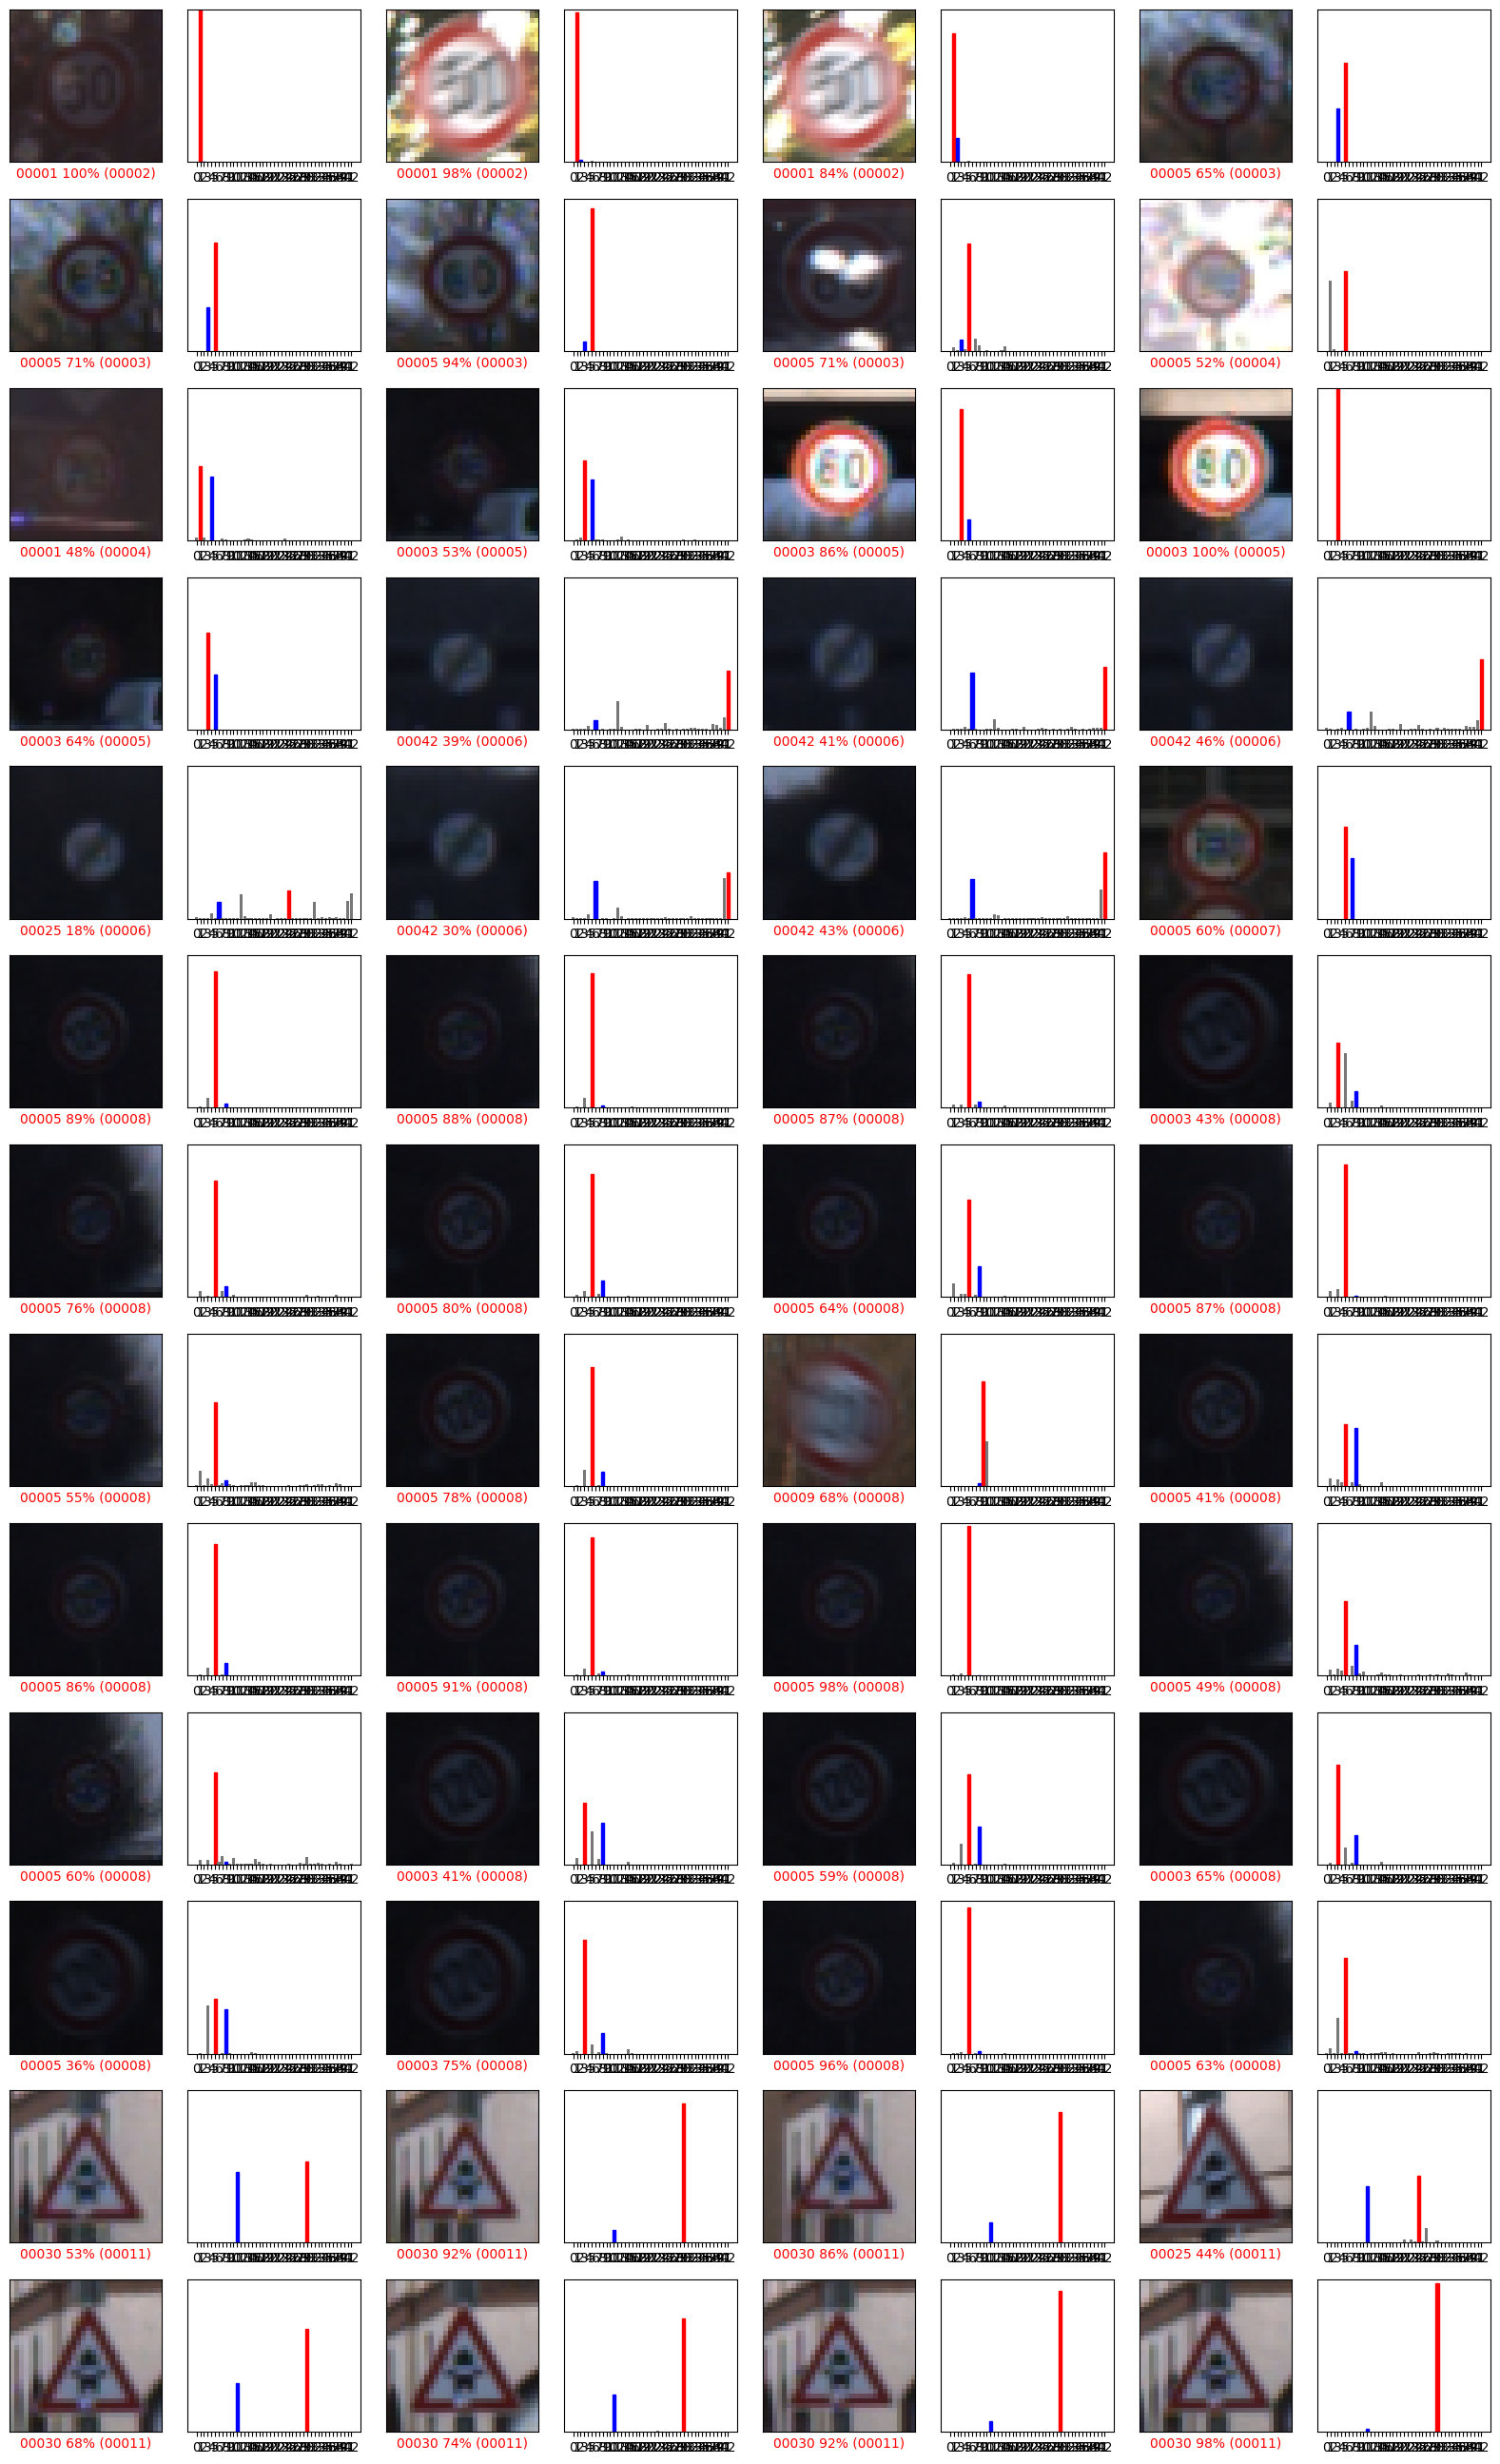

In [8]:
show_bad_preds(model_Conv, test_loader, test_set.classes)  

Visualization of the confusion matrix with highlighted misclassifications to analyze class-wise prediction errors.

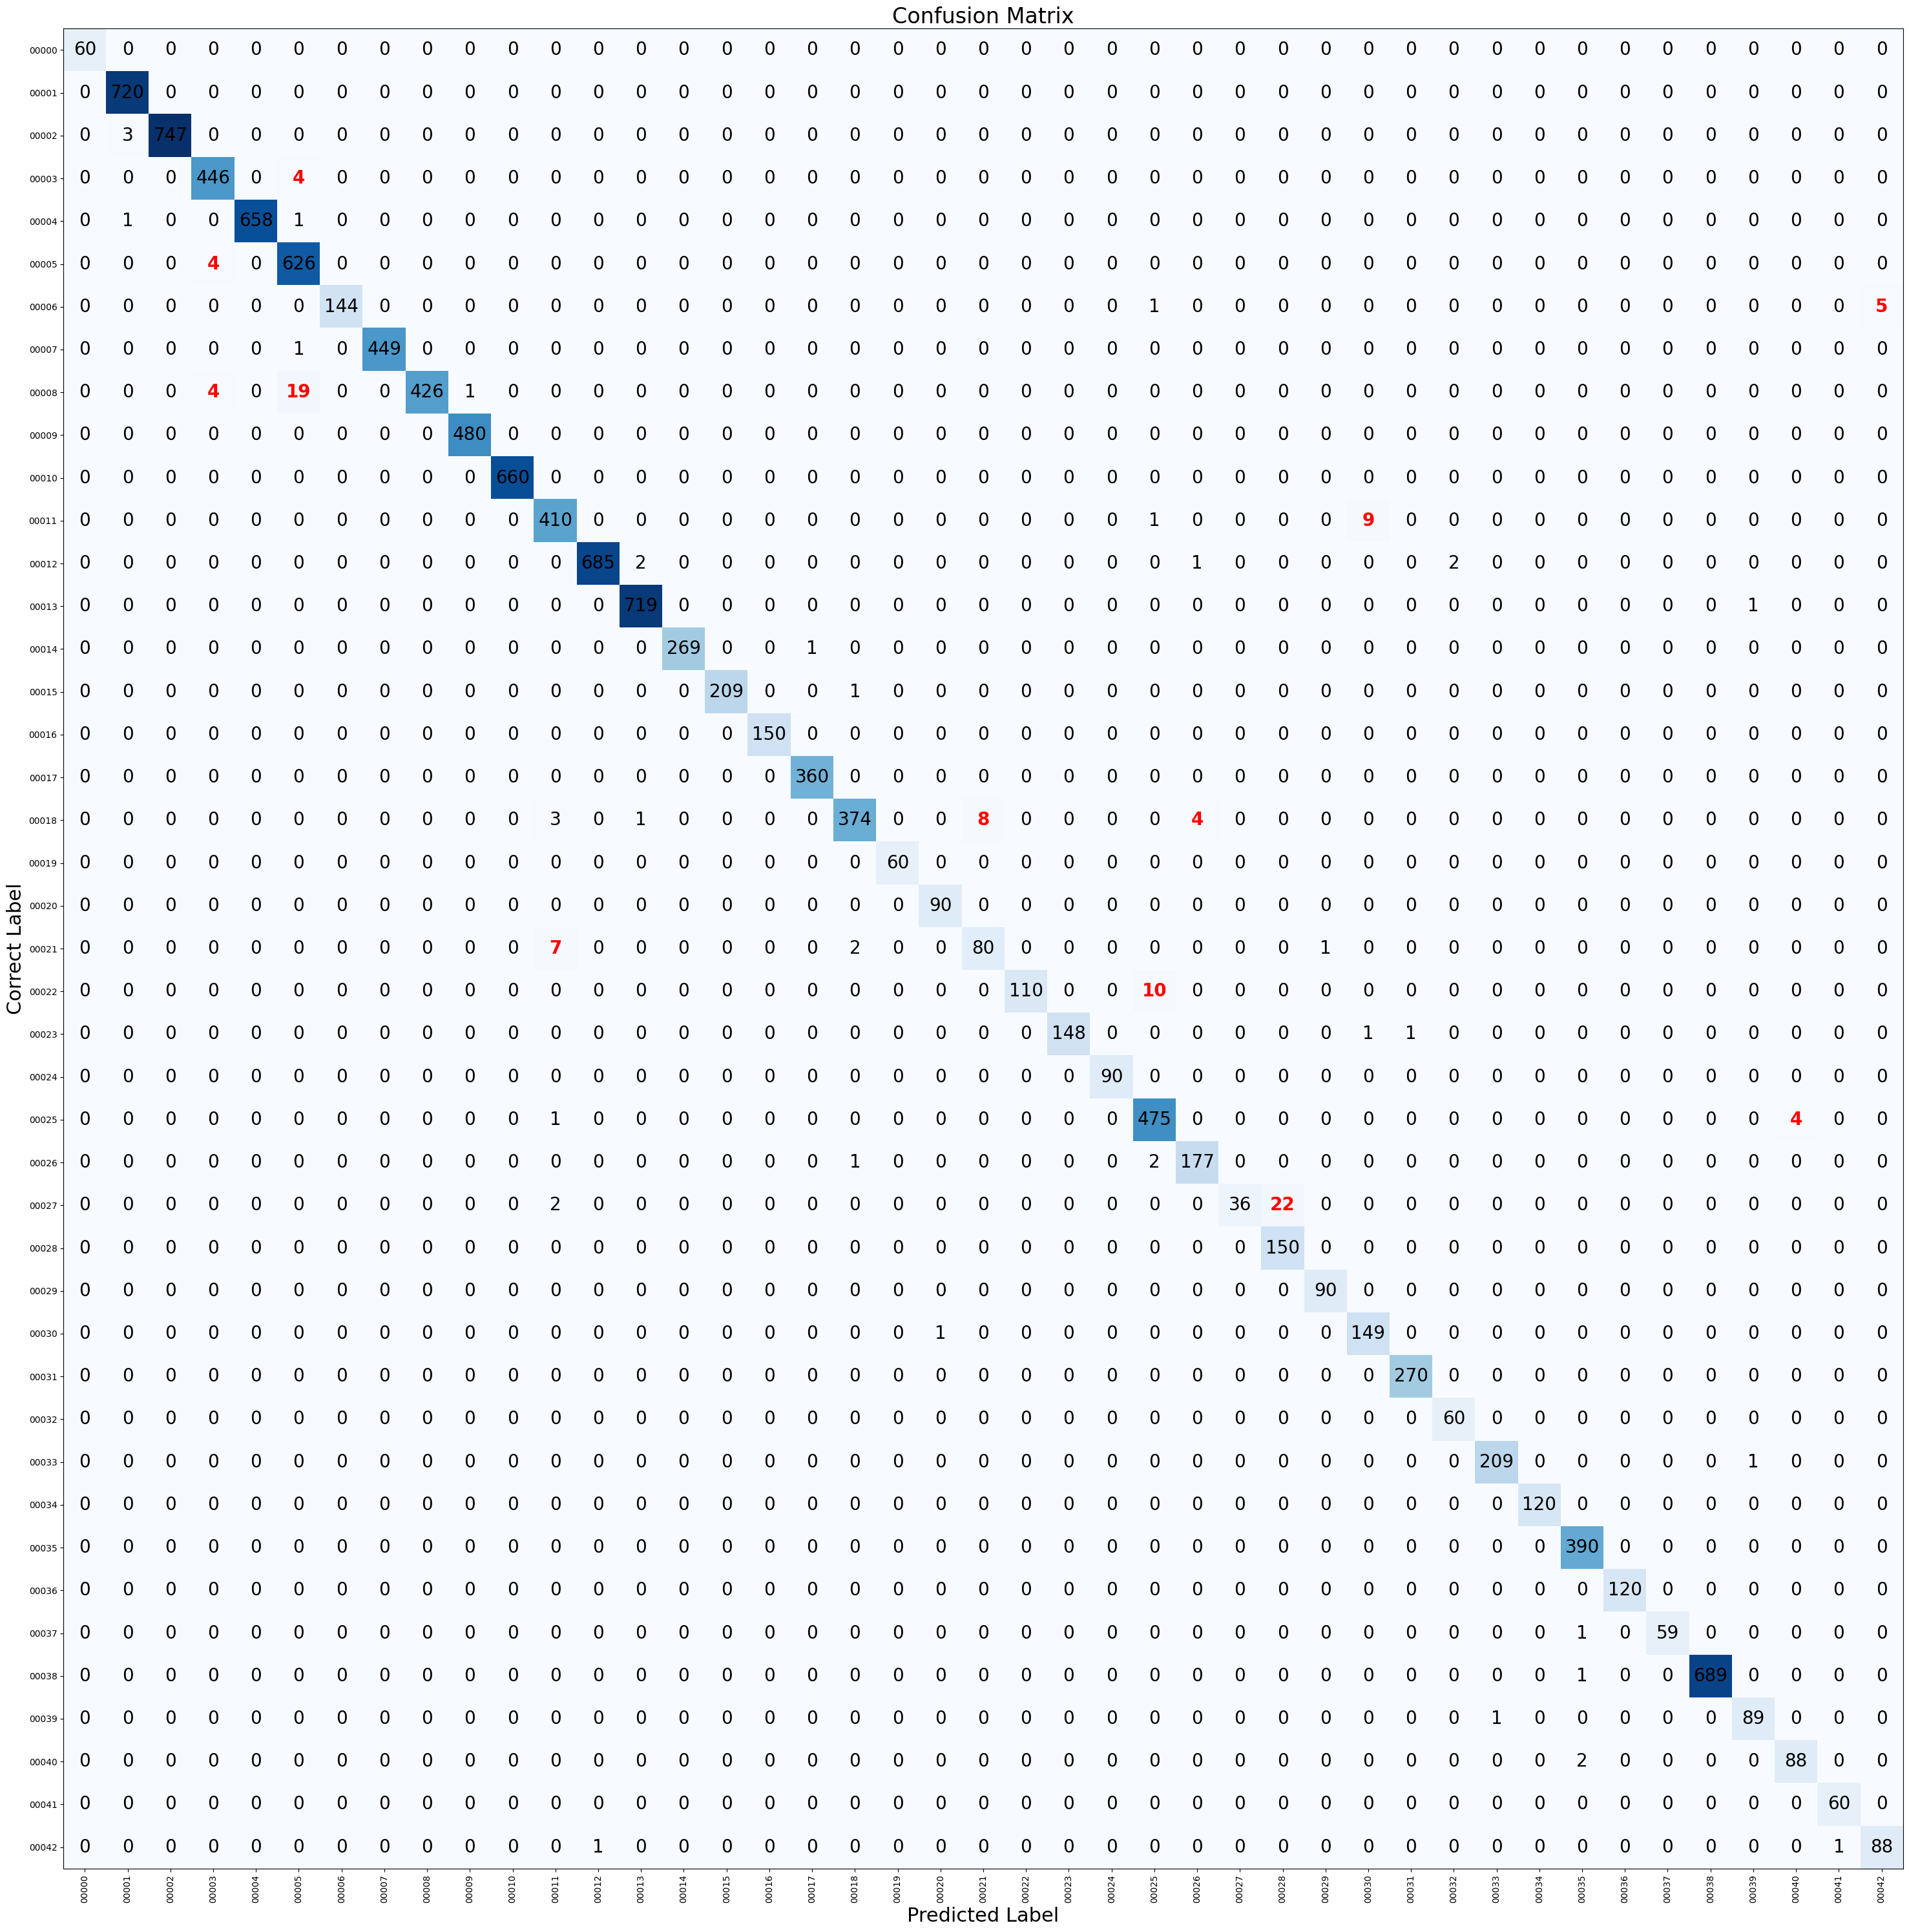

In [9]:
plot_confusion_matrix_highlight(model_Conv, test_loader, test_set.classes, threshold=3)

All models follow the same architecture, training procedure, and evaluation pipeline; therefore, only the data augmentation strategy will be explicitly described and discussed for each model, as it is the sole varying experimental factor.

# __Dynamic Augmentation - Color Jitter__

ColorJitter is used as a photometric data augmentation technique to improve the model’s robustness to variations in lighting conditions. By randomly adjusting brightness, contrast, saturation, and hue, the model is exposed during training to a wider range of visual appearances of the same class.

In the German Traffic Sign Recognition Benchmark (GTSRB), images often exhibit noticeable variations in illumination due to real-world acquisition conditions, including shadows, differences in exposure, and varying weather conditions across the dataset. These factors can cause the same traffic sign to appear significantly different in terms of color intensity and overall visual appearance.

By simulating these variations during training, ColorJitter encourages the network to focus on invariant structural features of the traffic signs rather than relying on absolute pixel intensity values. This leads to improved generalization and more stable performance across differently illuminated samples within the dataset.

In [10]:
transform_aug = v2.Compose([
    v2.Resize((32, 32)),

    v2.ColorJitter(
        brightness=0.5,
        contrast=0.5,
        saturation=0.2,
        hue=0.1
    ),

    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

train_set = torchvision.datasets.ImageFolder(
    root=PATH_TRAINING_SET,
    transform=transform_aug
)

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [11]:
loss_fn = torch.nn.CrossEntropyLoss()

for i in range(RUNS):
    model_Conv_II = Conv_II(len(train_set.classes))
    model_Conv_II.to(device)

    early_stop = Early_Stopping(9)
    optimizer_II = torch.optim.Adam(model_Conv_II.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_II, mode='min', factor = 0.1, patience=3)    
    history_II = train_III(model_Conv_II, train_loader, val_loader, EPOCHS, loss_fn, optimizer_II, scheduler, early_stop, f'model_weights/dynamic_colorJitter_aug_I_{i}')

Epoch: 000; Loss: 2.564775; Accuracy: 27.5299; Val Loss: 1.460302; Val Acc: 53.5926; Elapsed time: 101.5928
Epoch: 001; Loss: 1.283369; Accuracy: 61.7874; Val Loss: 0.771292; Val Acc: 79.3635; Elapsed time: 27.0517
Epoch: 002; Loss: 0.583031; Accuracy: 84.0807; Val Loss: 0.190255; Val Acc: 97.0014; Elapsed time: 26.7709
Epoch: 003; Loss: 0.295656; Accuracy: 92.8282; Val Loss: 0.085263; Val Acc: 98.5856; Elapsed time: 26.8327
Epoch: 004; Loss: 0.191121; Accuracy: 95.3178; Val Loss: 0.043544; Val Acc: 99.3918; Elapsed time: 27.1342
Epoch: 005; Loss: 0.139977; Accuracy: 96.7522; Val Loss: 0.043303; Val Acc: 99.4625; Elapsed time: 27.2093
Epoch: 006; Loss: 0.110027; Accuracy: 97.3435; Val Loss: 0.014326; Val Acc: 99.8303; Elapsed time: 27.0529
Epoch: 007; Loss: 0.086326; Accuracy: 97.8810; Val Loss: 0.012168; Val Acc: 99.8161; Elapsed time: 26.6352
Epoch: 008; Loss: 0.088318; Accuracy: 97.8527; Val Loss: 0.027783; Val Acc: 99.4908; Elapsed time: 27.0287
Epoch: 009; Loss: 0.068538; Accuracy

In [12]:
# =========================================================
# TEST RESULTS
# =========================================================

res = 0

model_Conv = Conv_II(len(train_set.classes))
model_Conv.to(device)

print('\n========== DYNAMIC COLOR JITTER RESULTS ==========')

for i in range(RUNS):

    # -----------------------------------------------------
    # Load best checkpoint
    # -----------------------------------------------------

    checkpoint = torch.load(
        f'model_weights/dynamic_colorJitter_aug_I_{i}.pt'
    )

    model_Conv.load_state_dict(checkpoint['model'])

    # -----------------------------------------------------
    # Metrics
    # -----------------------------------------------------

    best_epoch = checkpoint['epoch']

    test_acc = evaluate(model_Conv, test_loader) * 100
    eval_acc = evaluate(model_Conv, val_loader) * 100

    # -----------------------------------------------------
    # Print run results
    # -----------------------------------------------------

    print(f'\nRUN {i + 1}')

    print(f'Best Epoch    : {best_epoch}')
    print(f'Eval Accuracy : {eval_acc:.2f}%')
    print(f'Test Accuracy : {test_acc:.2f}%')

    # -----------------------------------------------------
    # Mean test accuracy
    # -----------------------------------------------------

    res += test_acc

# =========================================================
# FINAL MEAN
# =========================================================

res /= RUNS

print('\n========== FINAL MEAN TEST ACCURACY ==========')
print(f'Mean Test Accuracy : {res:.2f}%')

dynamic_colorJitter_acc = res


========== DYNAMIC COLOR JITTER RESULTS ==========

RUN 1
Best Epoch    : 26
Eval Accuracy : 100.00%
Test Accuracy : 98.58%

RUN 2
Best Epoch    : 29
Eval Accuracy : 100.00%
Test Accuracy : 98.90%

RUN 3
Best Epoch    : 29
Eval Accuracy : 100.00%
Test Accuracy : 99.02%

========== FINAL MEAN TEST ACCURACY ==========
Mean Test Accuracy : 98.83%


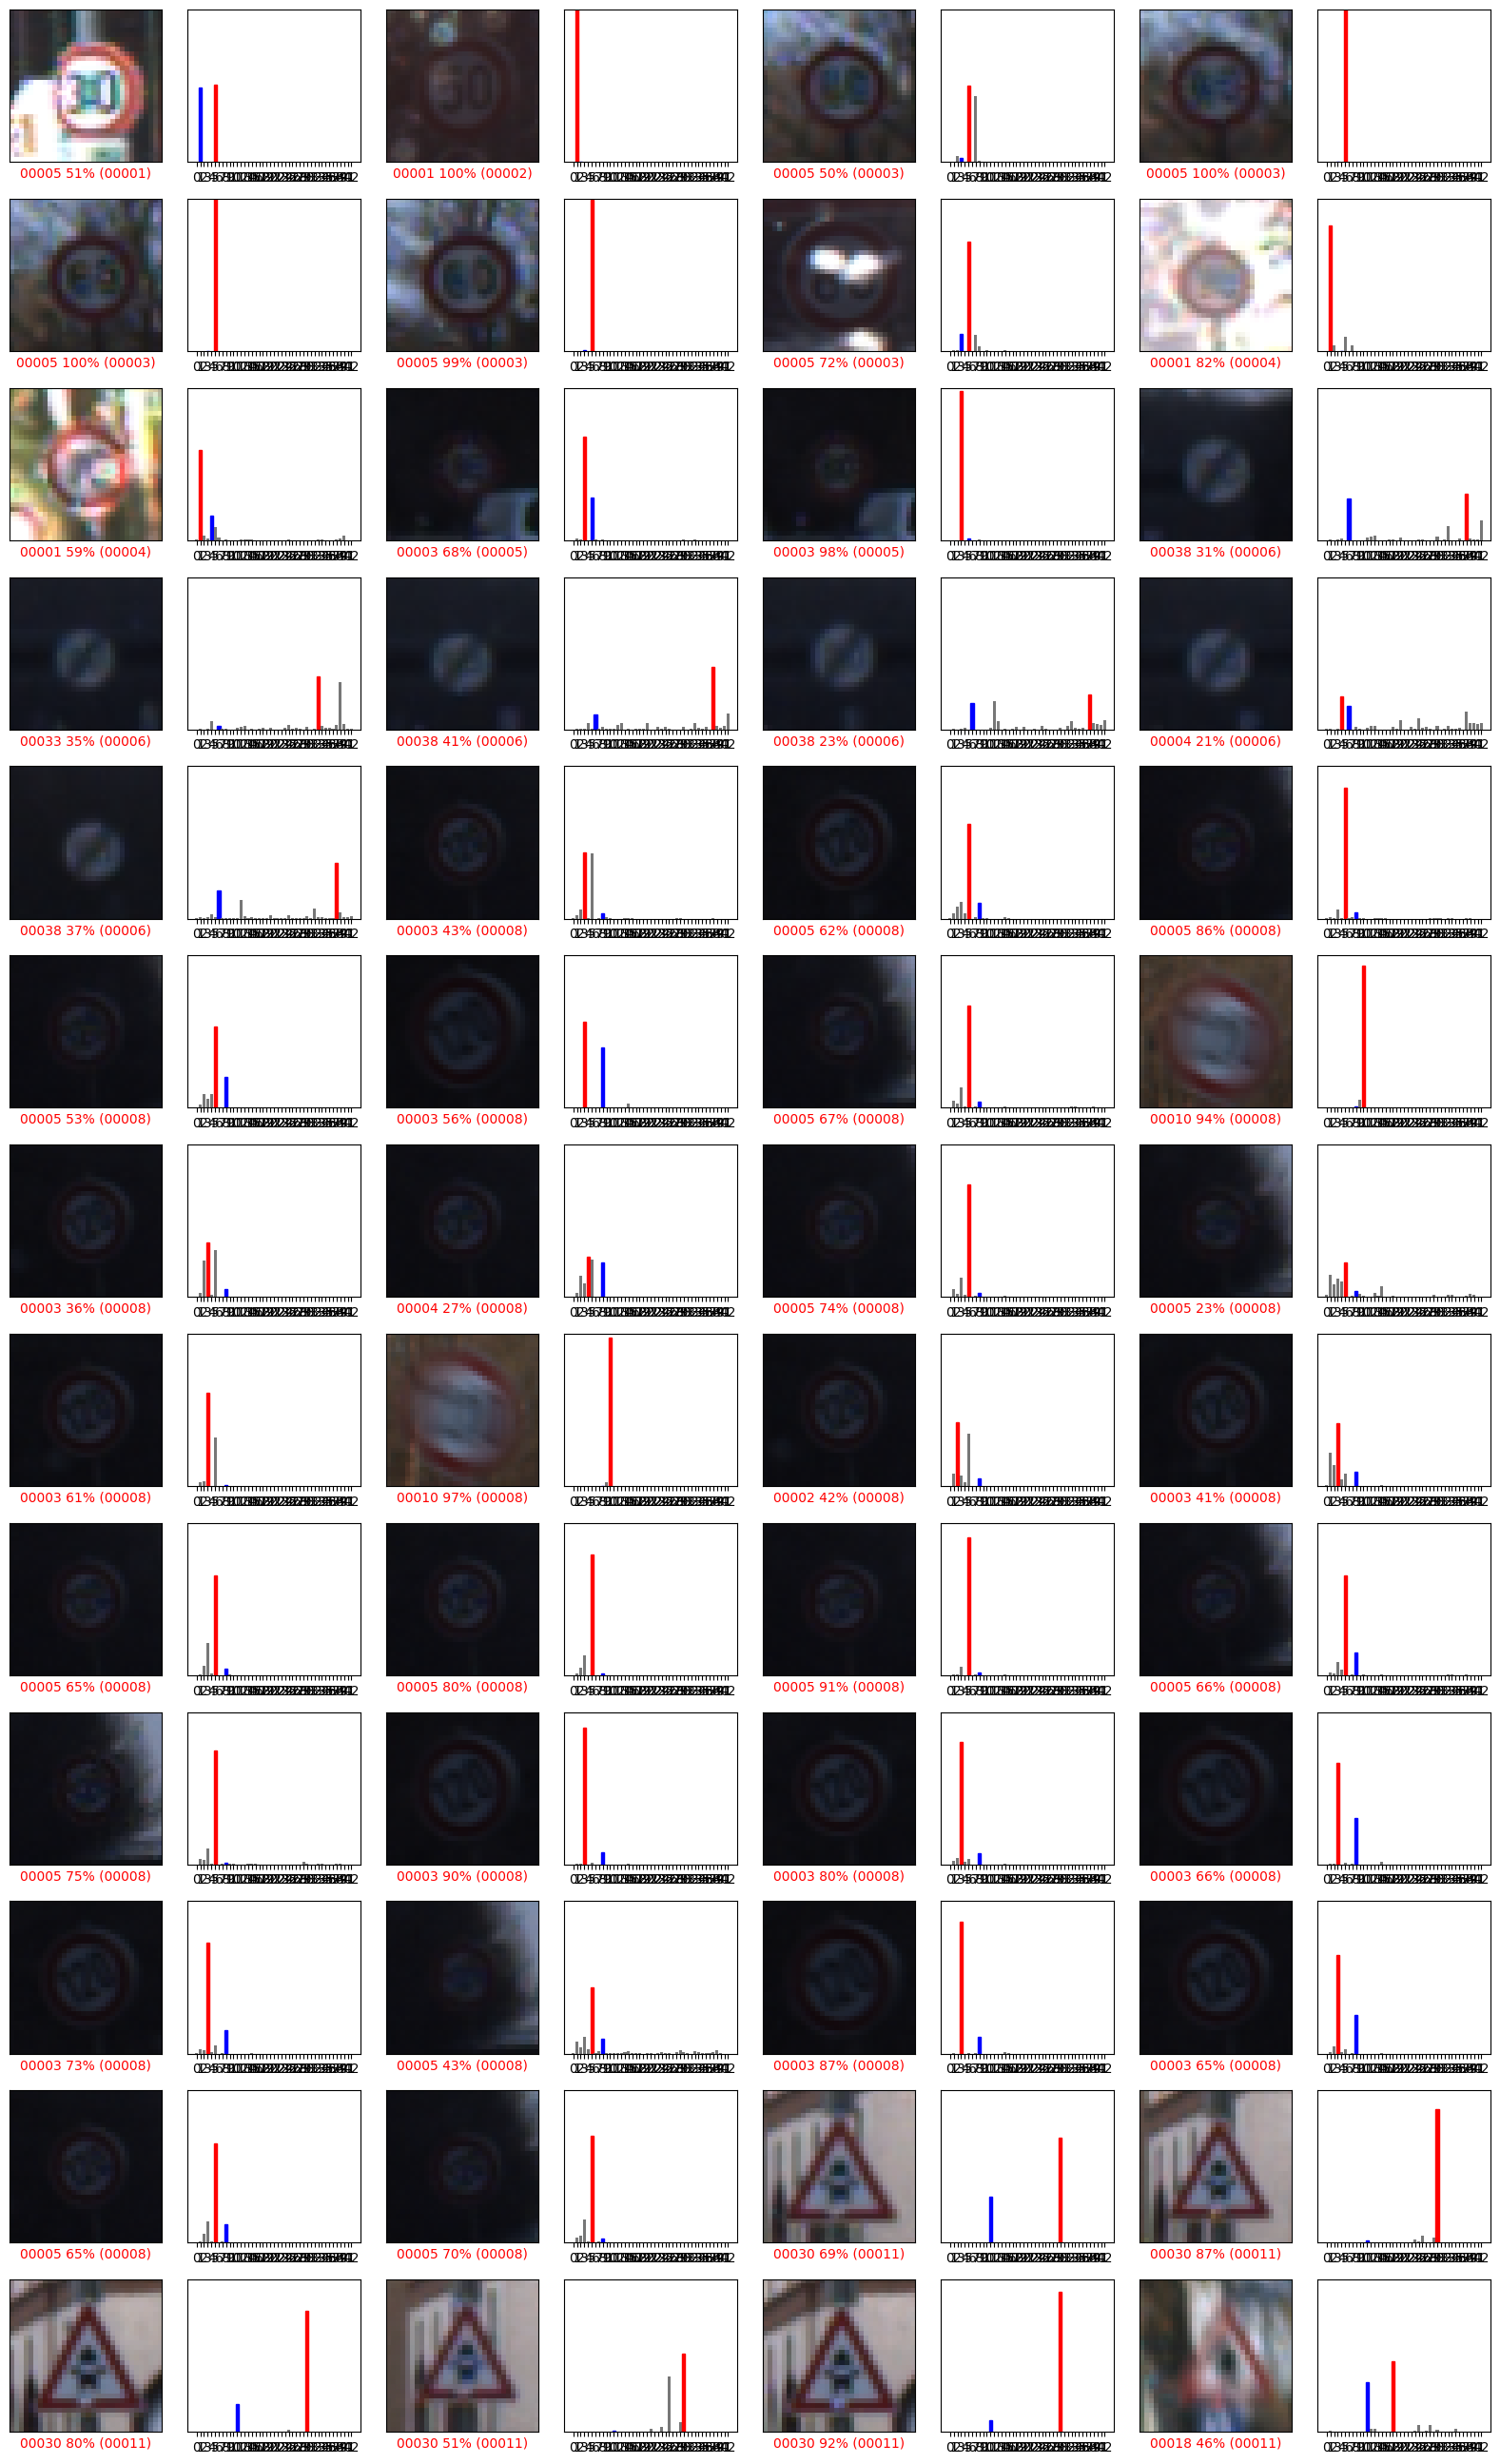

In [13]:
show_bad_preds(model_Conv, test_loader, test_set.classes)  

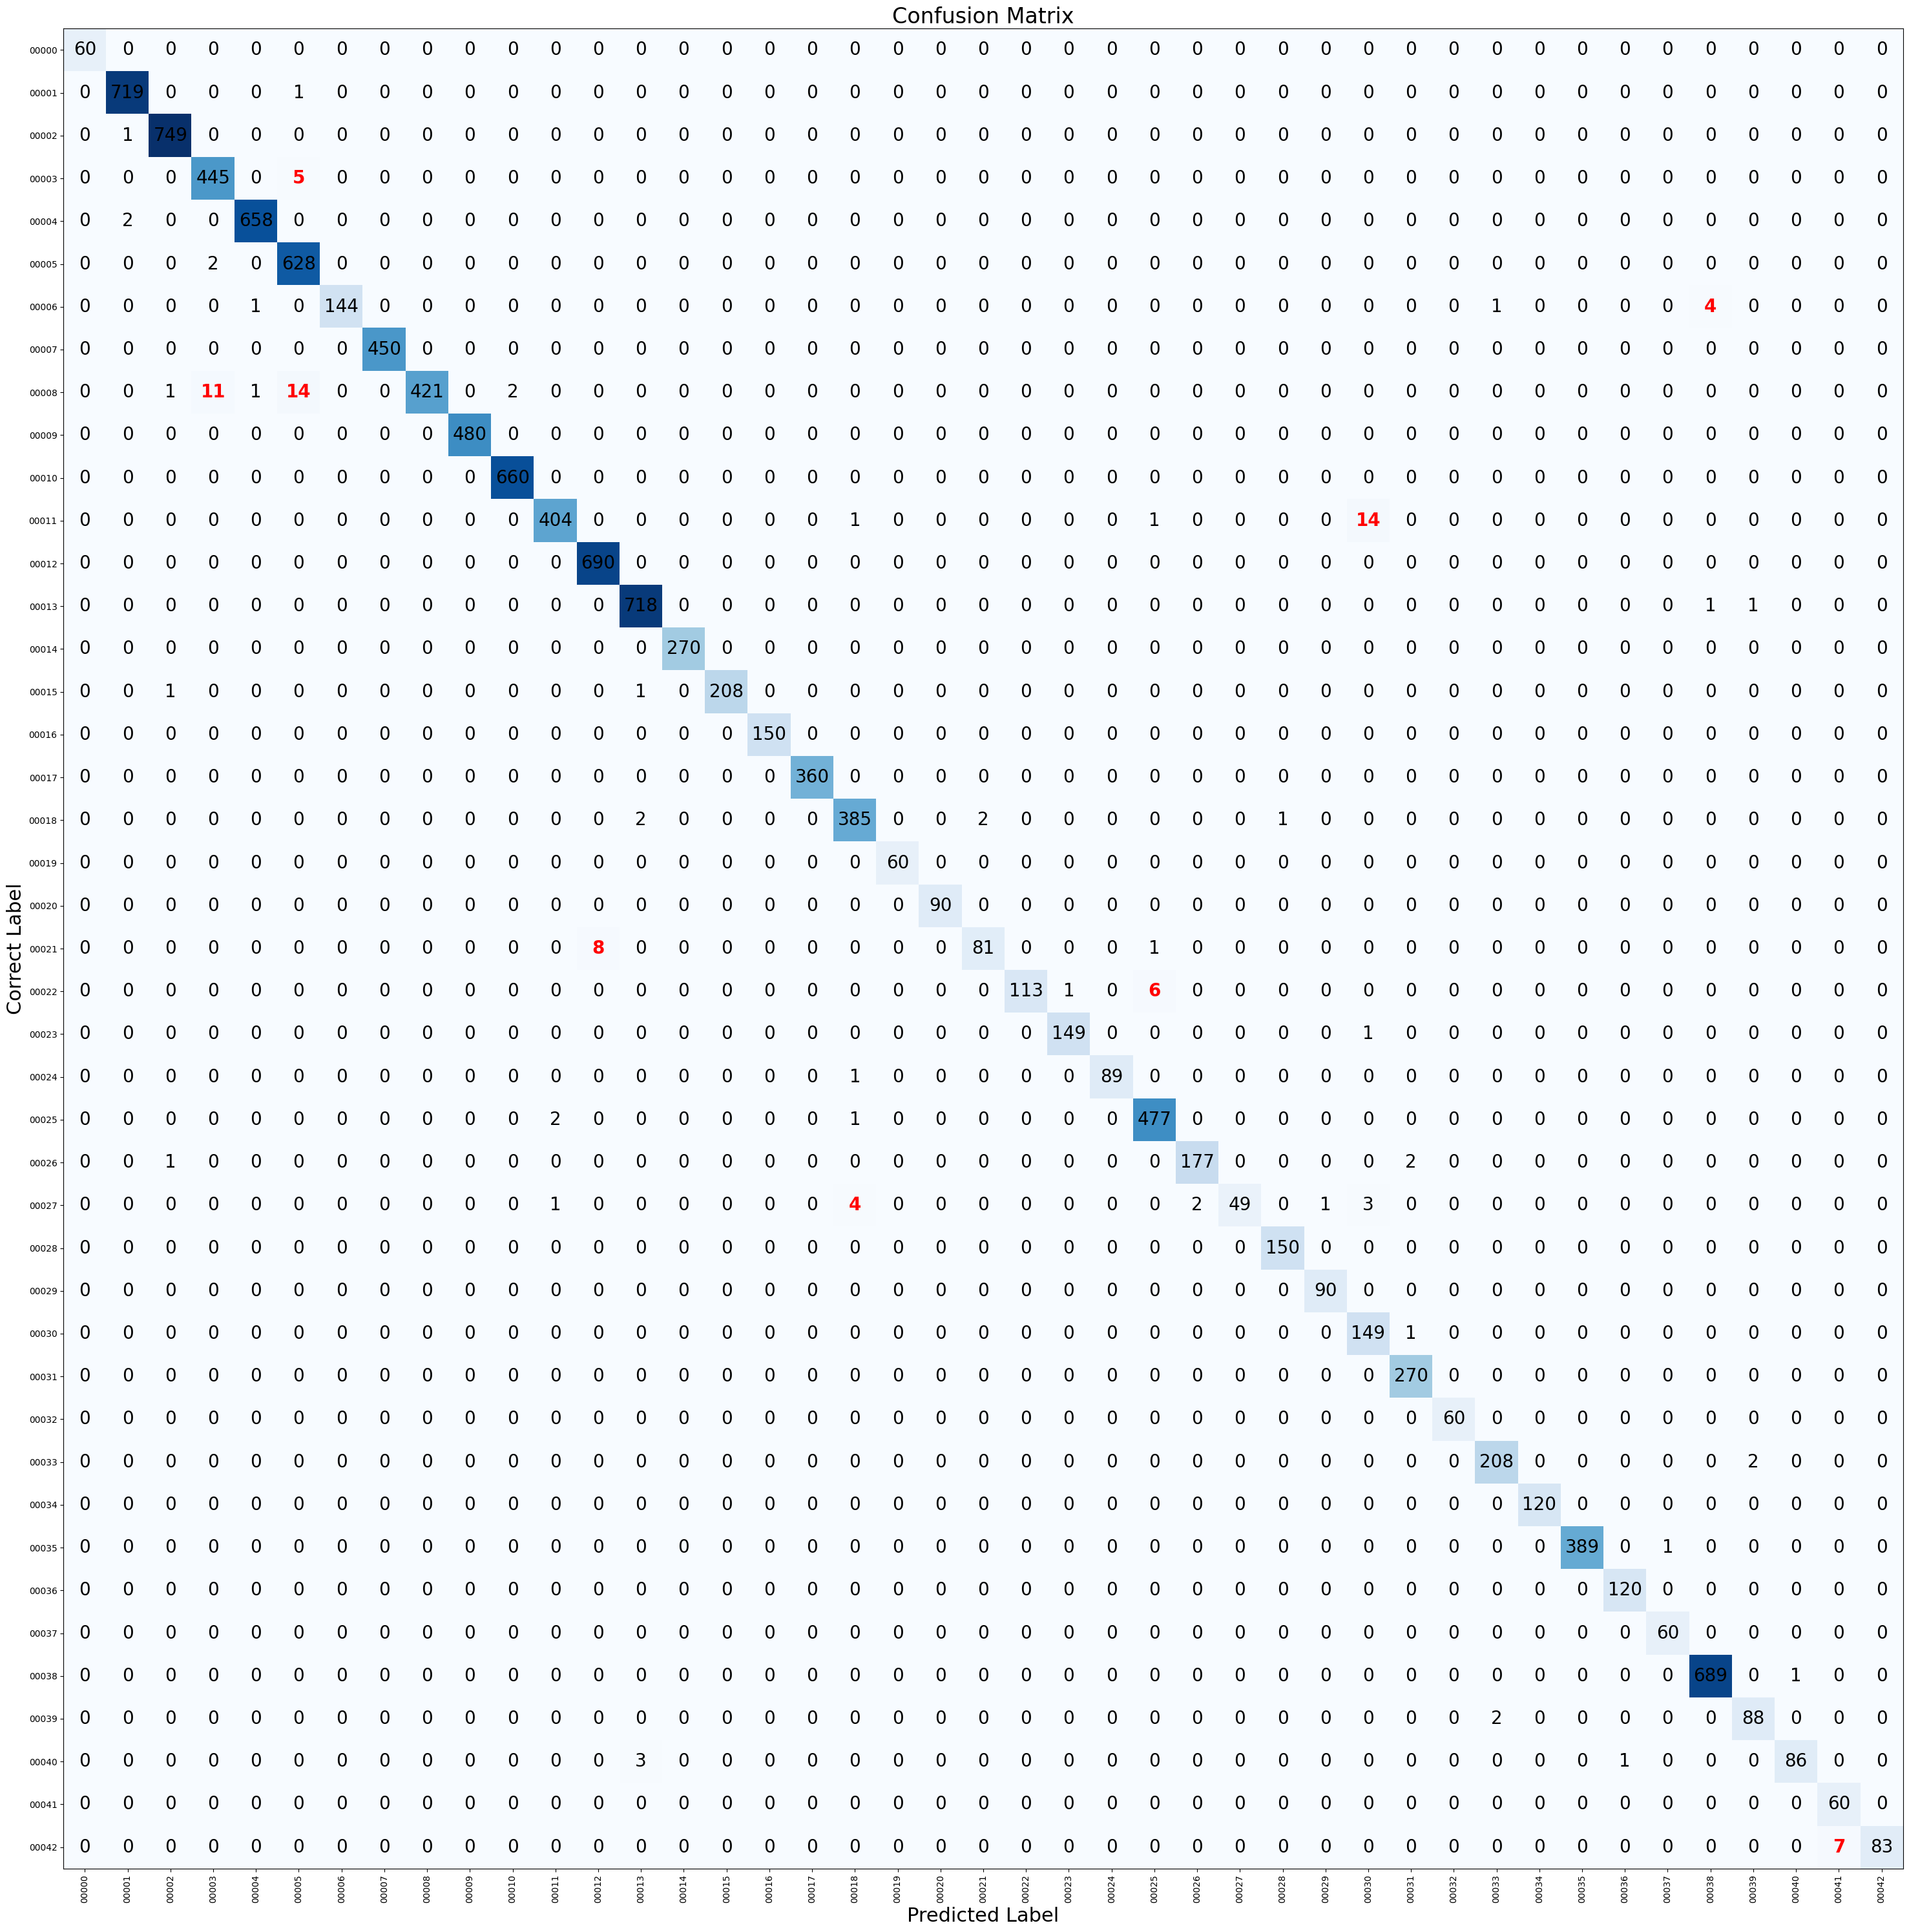

In [14]:
plot_confusion_matrix_highlight(model_Conv, test_loader, test_set.classes, threshold=3)

# __Dynamic Augmentation - Random Affine__

RandomAffine is used as a geometric data augmentation technique to improve the model’s robustness to spatial transformations commonly present in traffic sign images. It applies random rotations, translations, scaling, and shearing to simulate variations in viewpoint and camera positioning.

In the German Traffic Sign Recognition Benchmark (GTSRB), traffic signs may appear slightly off-center, tilted by small angles, or captured under different perspectives due to vehicle motion and camera placement. These spatial variations introduce intra-class variability that the model must learn to generalize over.

By exposing the network to these controlled geometric distortions during training, RandomAffine encourages invariance to small spatial transformations, leading to improved generalization and more stable classification performance under non-ideal spatial conditions within the dataset.

In [15]:
transform_aug = v2.Compose([

    v2.Resize((32, 32)),

    v2.RandomAffine(
        degrees=15,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
        shear=15,
        interpolation=v2.InterpolationMode.BILINEAR
    ),

    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

train_set = torchvision.datasets.ImageFolder(
    root=PATH_TRAINING_SET,
    transform=transform_aug
)

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [16]:
loss_fn = torch.nn.CrossEntropyLoss()

for i in range(RUNS):
    model_Conv_II = Conv_II(len(train_set.classes))
    model_Conv_II.to(device)

    early_stop = Early_Stopping(9)
    optimizer_II = torch.optim.Adam(model_Conv_II.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_II, mode='min', factor = 0.1, patience=3)    
    history_II = train_III(model_Conv_II, train_loader, val_loader, EPOCHS, loss_fn, optimizer_II, scheduler, early_stop, f'model_weights/dynamic_randomAffine_aug_I_{i}')

Epoch: 000; Loss: 2.577423; Accuracy: 26.2851; Val Loss: 1.967006; Val Acc: 38.8967; Elapsed time: 24.1459
Epoch: 001; Loss: 1.501175; Accuracy: 53.3511; Val Loss: 1.112305; Val Acc: 62.8713; Elapsed time: 23.9042
Epoch: 002; Loss: 0.749109; Accuracy: 78.5385; Val Loss: 0.304758; Val Acc: 93.8472; Elapsed time: 23.6857
Epoch: 003; Loss: 0.373000; Accuracy: 90.2566; Val Loss: 0.122497; Val Acc: 98.5431; Elapsed time: 23.8935
Epoch: 004; Loss: 0.214107; Accuracy: 94.7181; Val Loss: 0.071777; Val Acc: 98.9392; Elapsed time: 23.9686
Epoch: 005; Loss: 0.145478; Accuracy: 96.4580; Val Loss: 0.039176; Val Acc: 99.2928; Elapsed time: 24.0790
Epoch: 006; Loss: 0.107975; Accuracy: 97.3180; Val Loss: 0.017824; Val Acc: 99.7171; Elapsed time: 24.1447
Epoch: 007; Loss: 0.089295; Accuracy: 97.7480; Val Loss: 0.023574; Val Acc: 99.4625; Elapsed time: 23.9054
Epoch: 008; Loss: 0.079385; Accuracy: 97.9687; Val Loss: 0.018343; Val Acc: 99.5757; Elapsed time: 23.7893
Epoch: 009; Loss: 0.072503; Accuracy:

In [17]:
# =========================================================
# TEST RESULTS
# =========================================================

res = 0

model_Conv = Conv_II(len(train_set.classes))
model_Conv.to(device)

print('\n========== DYNAMIC RANDOM AFFINE RESULTS ==========')

for i in range(RUNS):

    # -----------------------------------------------------
    # Load best checkpoint
    # -----------------------------------------------------

    checkpoint = torch.load(
        f'model_weights/dynamic_randomAffine_aug_I_{i}.pt'
    )

    model_Conv.load_state_dict(checkpoint['model'])

    # -----------------------------------------------------
    # Metrics
    # -----------------------------------------------------

    best_epoch = checkpoint['epoch']

    test_acc = evaluate(model_Conv, test_loader) * 100
    eval_acc = evaluate(model_Conv, val_loader) * 100

    # -----------------------------------------------------
    # Print run results
    # -----------------------------------------------------

    print(f'\nRUN {i + 1}')

    print(f'Best Epoch    : {best_epoch}')
    print(f'Eval Accuracy : {eval_acc:.2f}%')
    print(f'Test Accuracy : {test_acc:.2f}%')

    # -----------------------------------------------------
    # Mean test accuracy
    # -----------------------------------------------------

    res += test_acc

# =========================================================
# FINAL MEAN
# =========================================================

res /= RUNS

print('\n========== FINAL MEAN TEST ACCURACY ==========')
print(f'Mean Test Accuracy : {res:.2f}%')

dynamic_randomAffine_acc = res


========== DYNAMIC RANDOM AFFINE RESULTS ==========

RUN 1
Best Epoch    : 29
Eval Accuracy : 100.00%
Test Accuracy : 98.45%

RUN 2
Best Epoch    : 28
Eval Accuracy : 100.00%
Test Accuracy : 98.72%

RUN 3
Best Epoch    : 26
Eval Accuracy : 100.00%
Test Accuracy : 99.04%

========== FINAL MEAN TEST ACCURACY ==========
Mean Test Accuracy : 98.74%


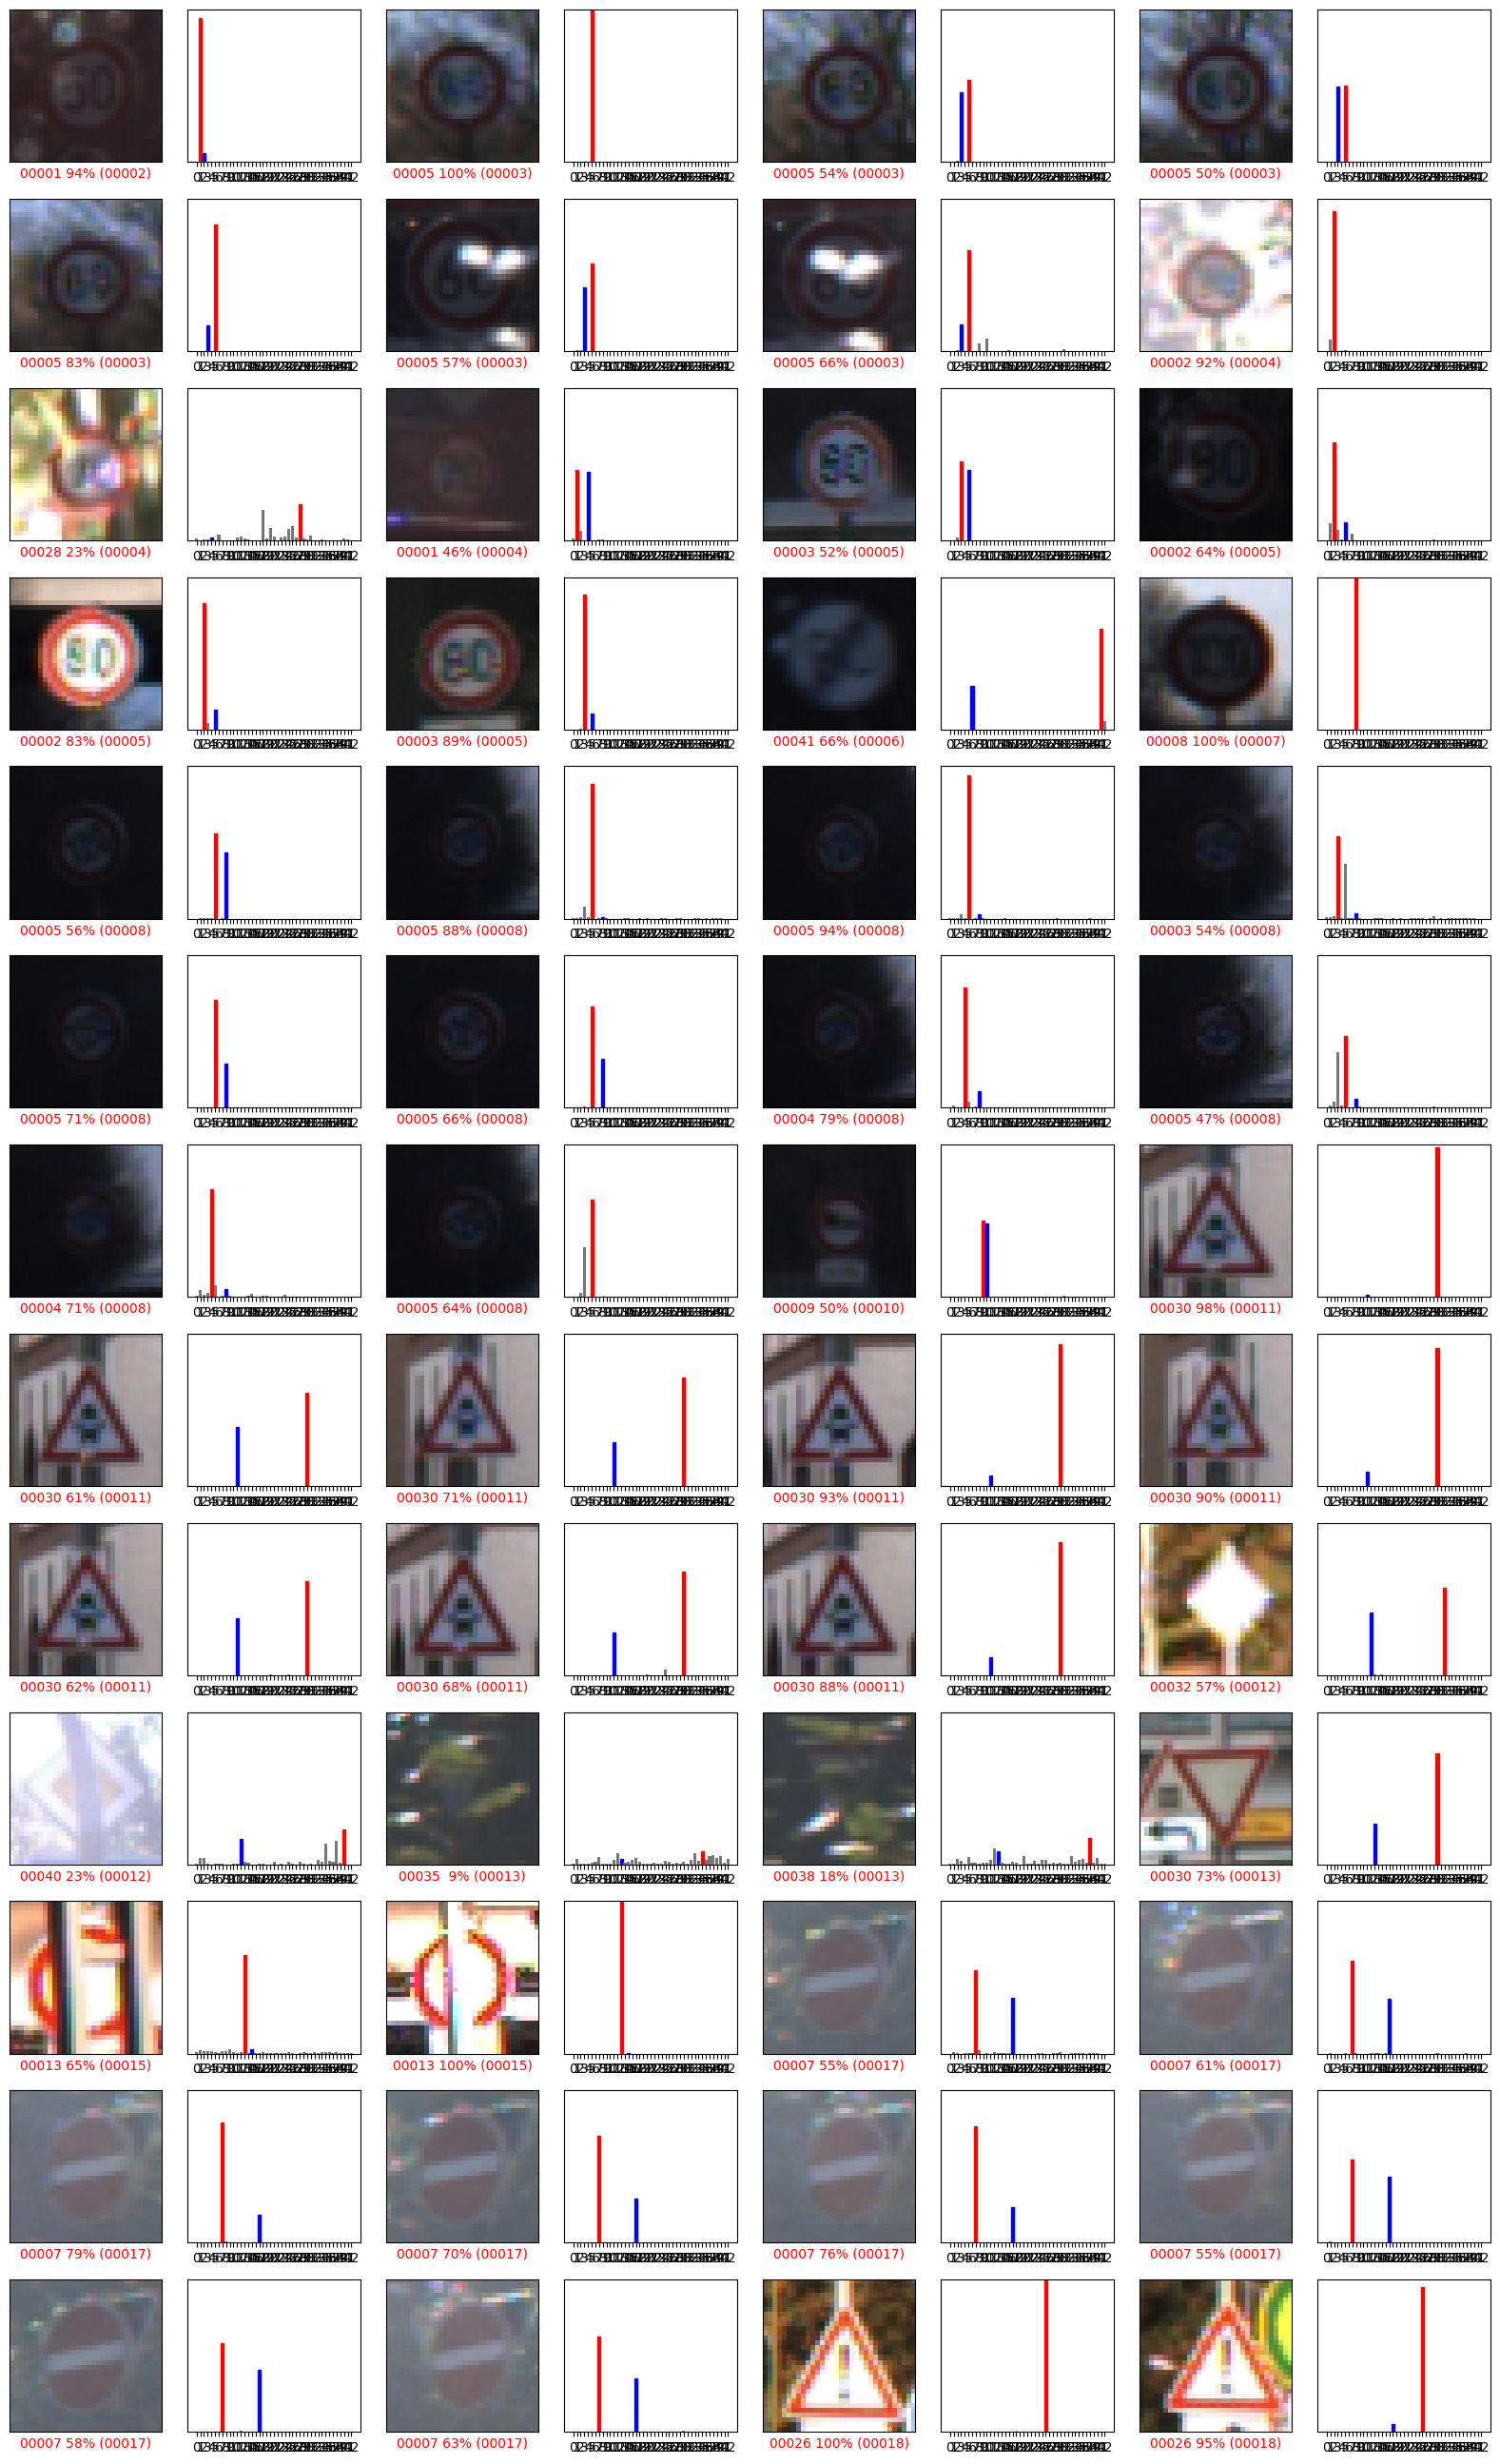

In [18]:
show_bad_preds(model_Conv, test_loader, test_set.classes)   

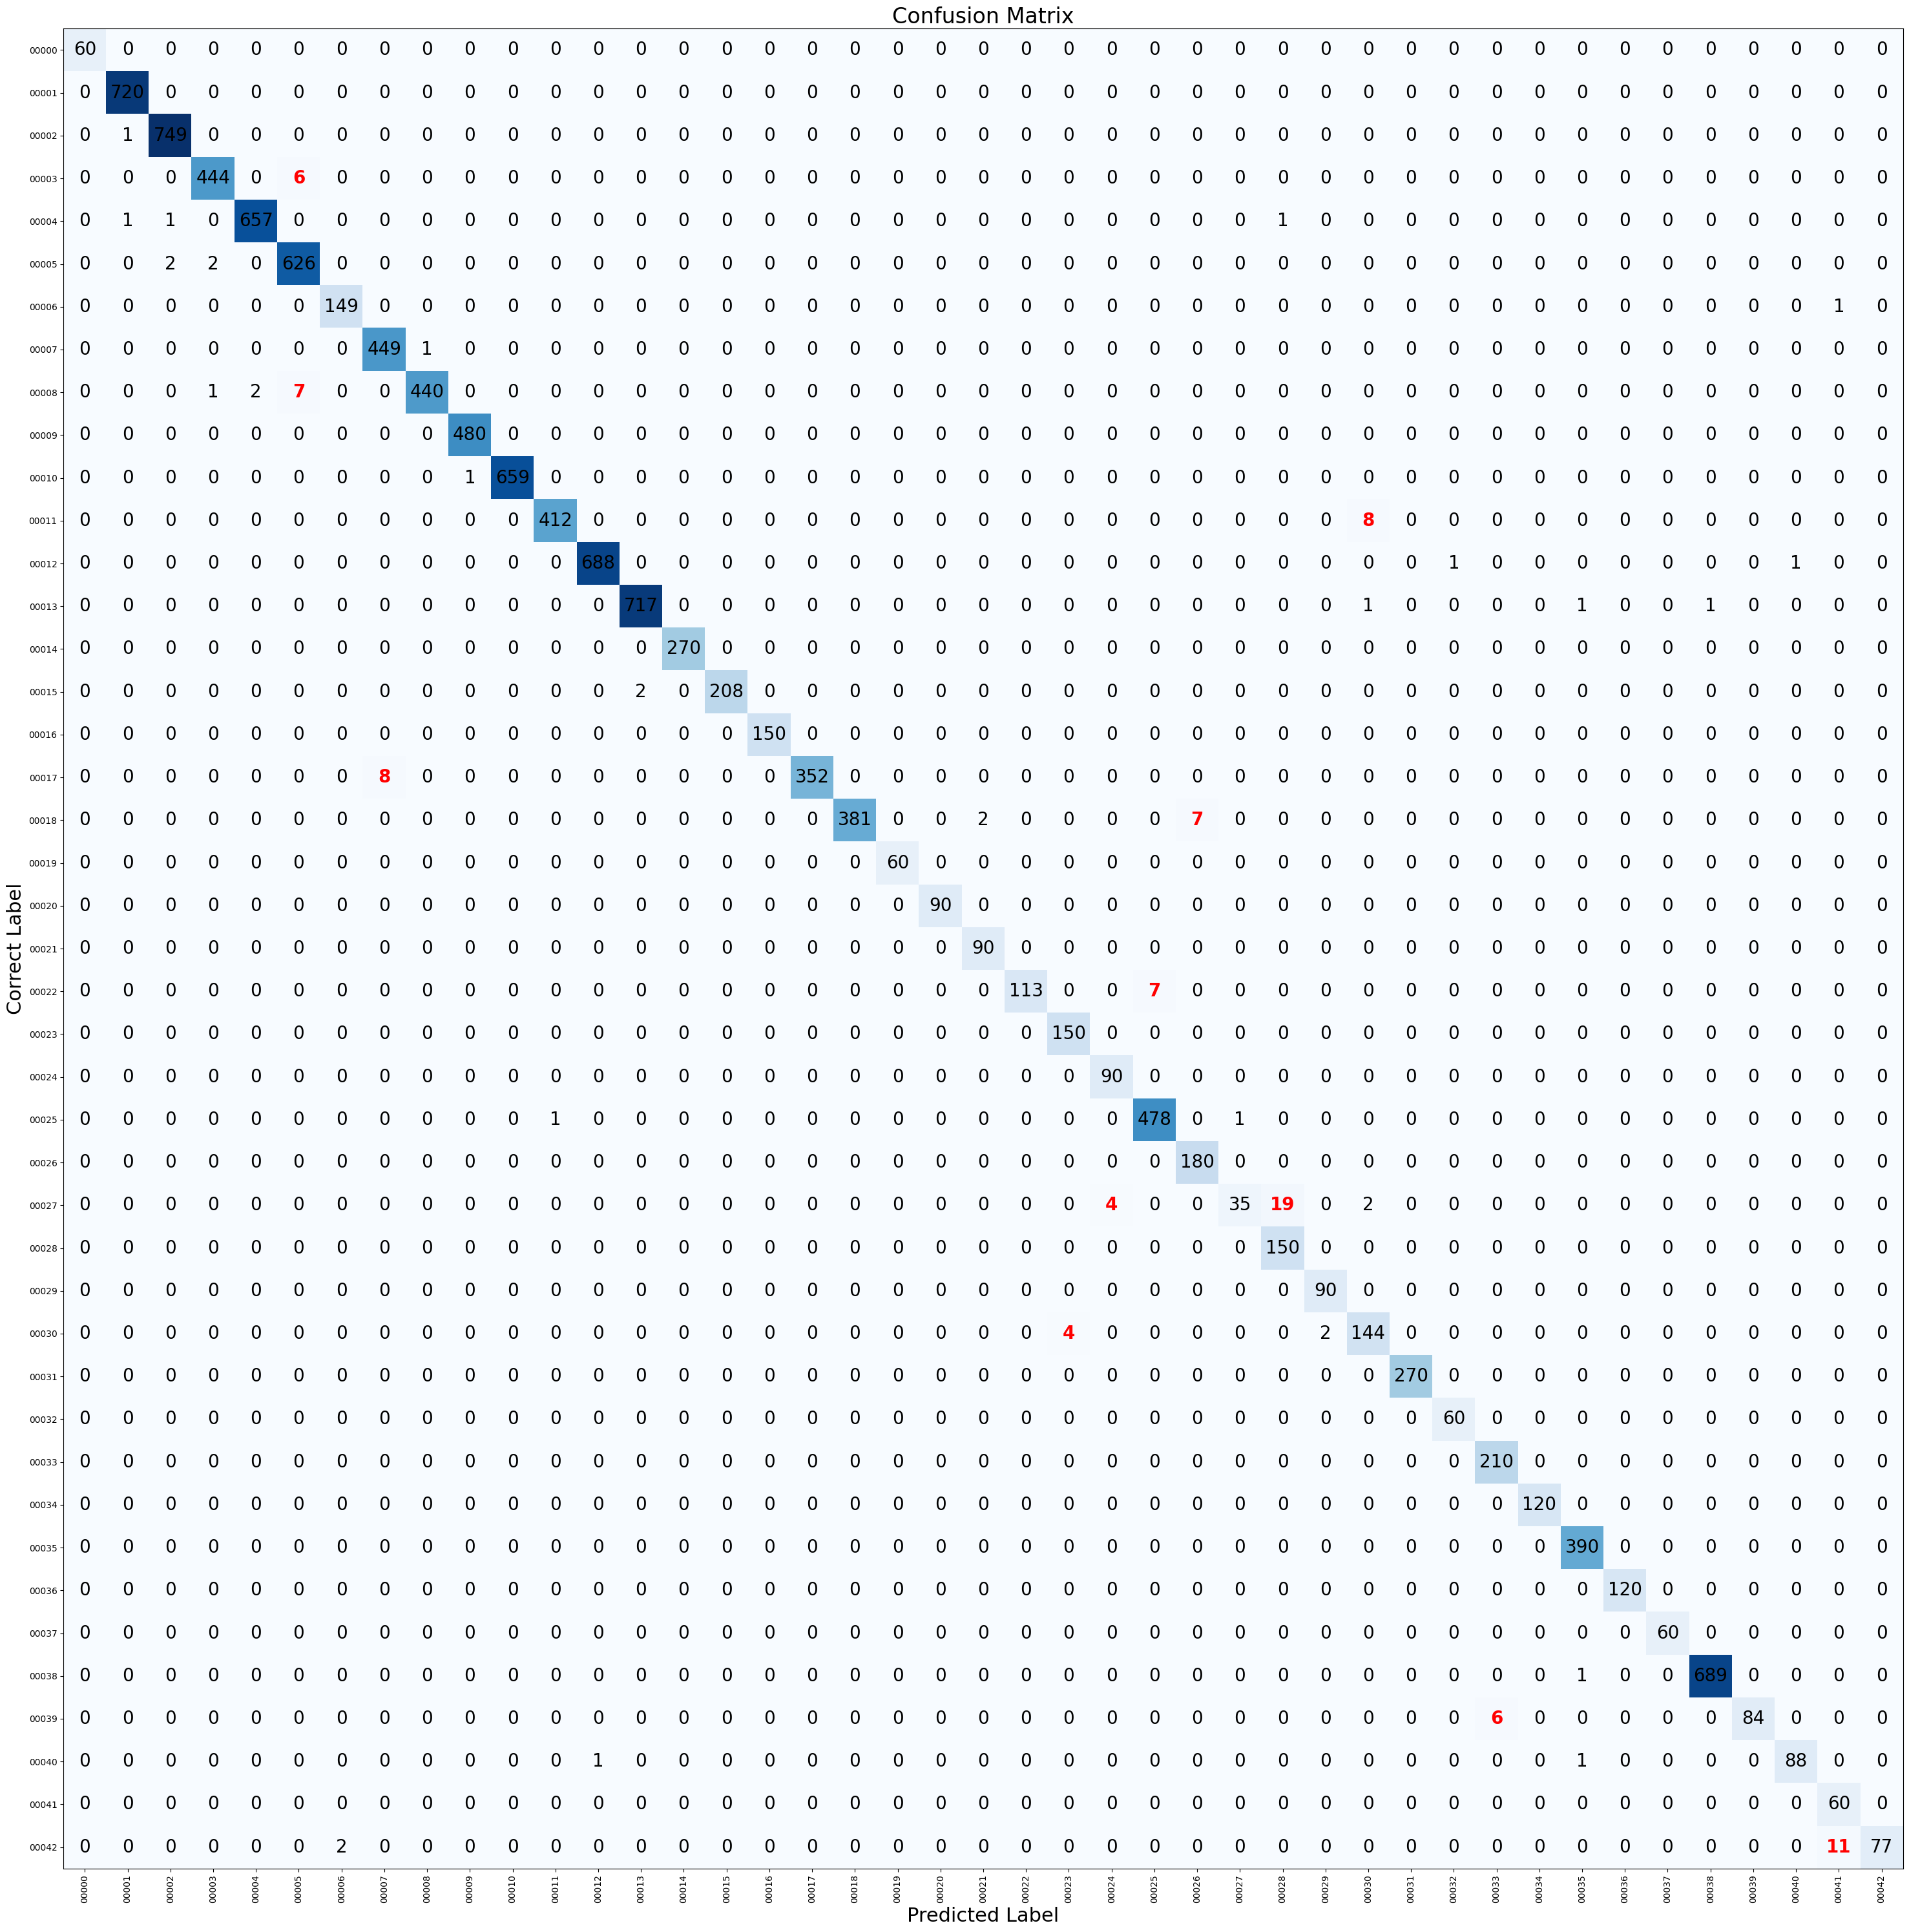

In [19]:
plot_confusion_matrix_highlight(model_Conv, test_loader, test_set.classes, threshold=3)

# __Dynamic Augmentation - Gaussian Blur__

Gaussian Blur is used as a data augmentation technique to improve the model’s robustness to image quality degradation. It simulates the presence of blur in the input images by applying a Gaussian smoothing filter with random intensity.

In the German Traffic Sign Recognition Benchmark (GTSRB), some images are not perfectly sharp due to factors such as motion during image capture, camera focus limitations, or compression artifacts. As a result, fine-grained visual details of traffic signs may appear softened or partially indistinct.

By introducing controlled blur during training, the model is encouraged to rely less on fine pixel-level details and instead focus on more robust structural patterns of the traffic signs. This leads to improved generalization and reduces sensitivity to variations in image sharpness within the dataset.

In [20]:
transform_aug = v2.Compose([

    v2.Resize((32, 32)),

    v2.GaussianBlur(
        kernel_size=3,
        sigma=(0.1, 1.0)
    ),

    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

train_set = torchvision.datasets.ImageFolder(
    root=PATH_TRAINING_SET,
    transform=transform_aug
)

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [21]:
loss_fn = torch.nn.CrossEntropyLoss()

for i in range(RUNS):
    model_Conv_II = Conv_II(len(train_set.classes))
    model_Conv_II.to(device)

    early_stop = Early_Stopping(9)
    optimizer_II = torch.optim.Adam(model_Conv_II.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_II, mode='min', factor = 0.1, patience=3)    
    history_II = train_III(model_Conv_II, train_loader, val_loader, EPOCHS, loss_fn, optimizer_II, scheduler, early_stop, f'model_weights/dynamic_gaussianBlur_aug_I_{i}')

Epoch: 000; Loss: 2.484320; Accuracy: 29.0548; Val Loss: 1.597782; Val Acc: 50.0424; Elapsed time: 28.2417
Epoch: 001; Loss: 1.268613; Accuracy: 61.5356; Val Loss: 0.682643; Val Acc: 79.8161; Elapsed time: 28.5446
Epoch: 002; Loss: 0.531820; Accuracy: 85.4641; Val Loss: 0.200655; Val Acc: 95.5163; Elapsed time: 28.1592
Epoch: 003; Loss: 0.233970; Accuracy: 94.5116; Val Loss: 0.098666; Val Acc: 98.4441; Elapsed time: 28.4611
Epoch: 004; Loss: 0.135845; Accuracy: 96.9531; Val Loss: 0.057572; Val Acc: 98.9392; Elapsed time: 28.1518
Epoch: 005; Loss: 0.088958; Accuracy: 98.0734; Val Loss: 0.014695; Val Acc: 99.9010; Elapsed time: 28.1285
Epoch: 006; Loss: 0.071552; Accuracy: 98.3535; Val Loss: 0.010060; Val Acc: 99.9717; Elapsed time: 28.2080
Epoch: 007; Loss: 0.057297; Accuracy: 98.6760; Val Loss: 0.010246; Val Acc: 99.8727; Elapsed time: 28.4001
Epoch: 008; Loss: 0.046503; Accuracy: 98.8910; Val Loss: 0.005688; Val Acc: 99.9293; Elapsed time: 28.3525
Epoch: 009; Loss: 0.042785; Accuracy:

In [22]:
# =========================================================
# TEST RESULTS
# =========================================================

res = 0

model_Conv = Conv_II(len(train_set.classes))
model_Conv.to(device)

print('\n========== DYNAMIC GAUSSIAN BLUR RESULTS ==========')

for i in range(RUNS):

    # -----------------------------------------------------
    # Load best checkpoint
    # -----------------------------------------------------

    checkpoint = torch.load(
        f'model_weights/dynamic_gaussianBlur_aug_I_{i}.pt'
    )

    model_Conv.load_state_dict(checkpoint['model'])

    # -----------------------------------------------------
    # Metrics
    # -----------------------------------------------------

    best_epoch = checkpoint['epoch']

    test_acc = evaluate(model_Conv, test_loader) * 100
    eval_acc = evaluate(model_Conv, val_loader) * 100

    # -----------------------------------------------------
    # Print run results
    # -----------------------------------------------------

    print(f'\nRUN {i + 1}')

    print(f'Best Epoch    : {best_epoch}')
    print(f'Eval Accuracy : {eval_acc:.2f}%')
    print(f'Test Accuracy : {test_acc:.2f}%')

    # -----------------------------------------------------
    # Mean test accuracy
    # -----------------------------------------------------

    res += test_acc

# =========================================================
# FINAL MEAN
# =========================================================

res /= RUNS

print('\n========== FINAL MEAN TEST ACCURACY ==========')
print(f'Mean Test Accuracy : {res:.2f}%')

dynamic_gaussianBlur_acc = res


========== DYNAMIC GAUSSIAN BLUR RESULTS ==========

RUN 1
Best Epoch    : 29
Eval Accuracy : 100.00%
Test Accuracy : 98.54%

RUN 2
Best Epoch    : 29
Eval Accuracy : 100.00%
Test Accuracy : 98.18%

RUN 3
Best Epoch    : 29
Eval Accuracy : 100.00%
Test Accuracy : 98.11%

========== FINAL MEAN TEST ACCURACY ==========
Mean Test Accuracy : 98.28%


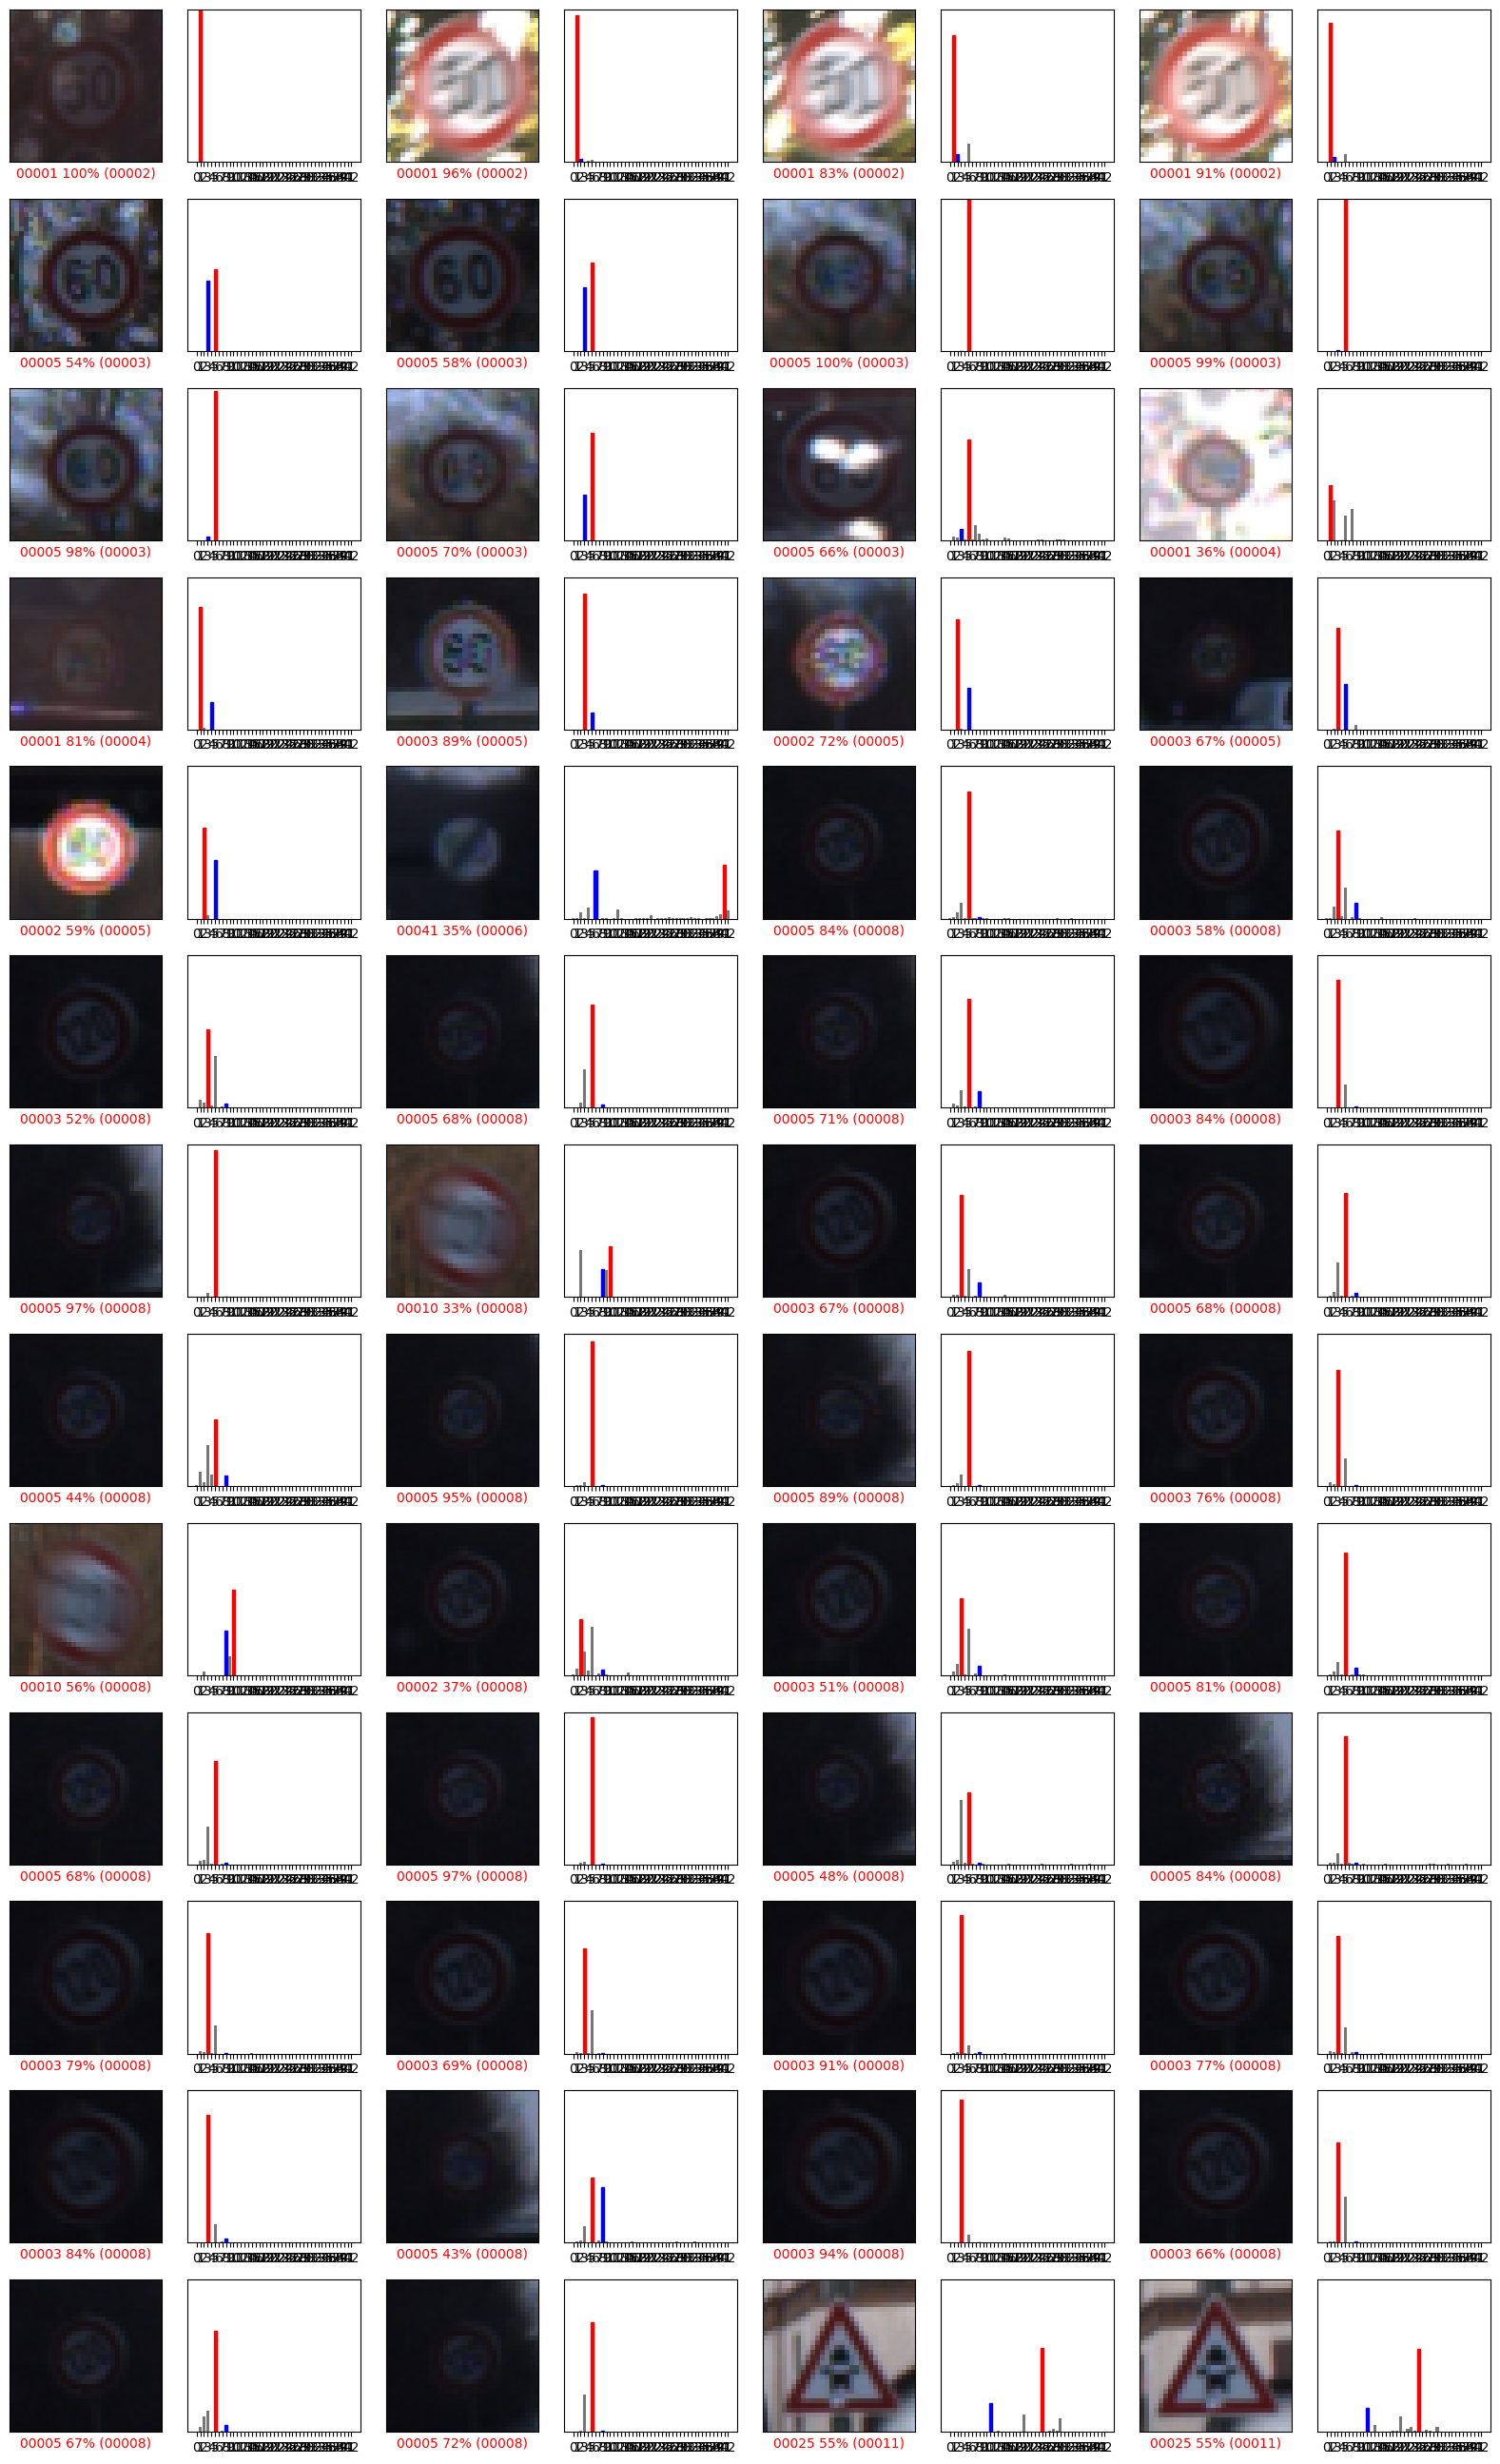

In [23]:
show_bad_preds(model_Conv, test_loader, test_set.classes)   

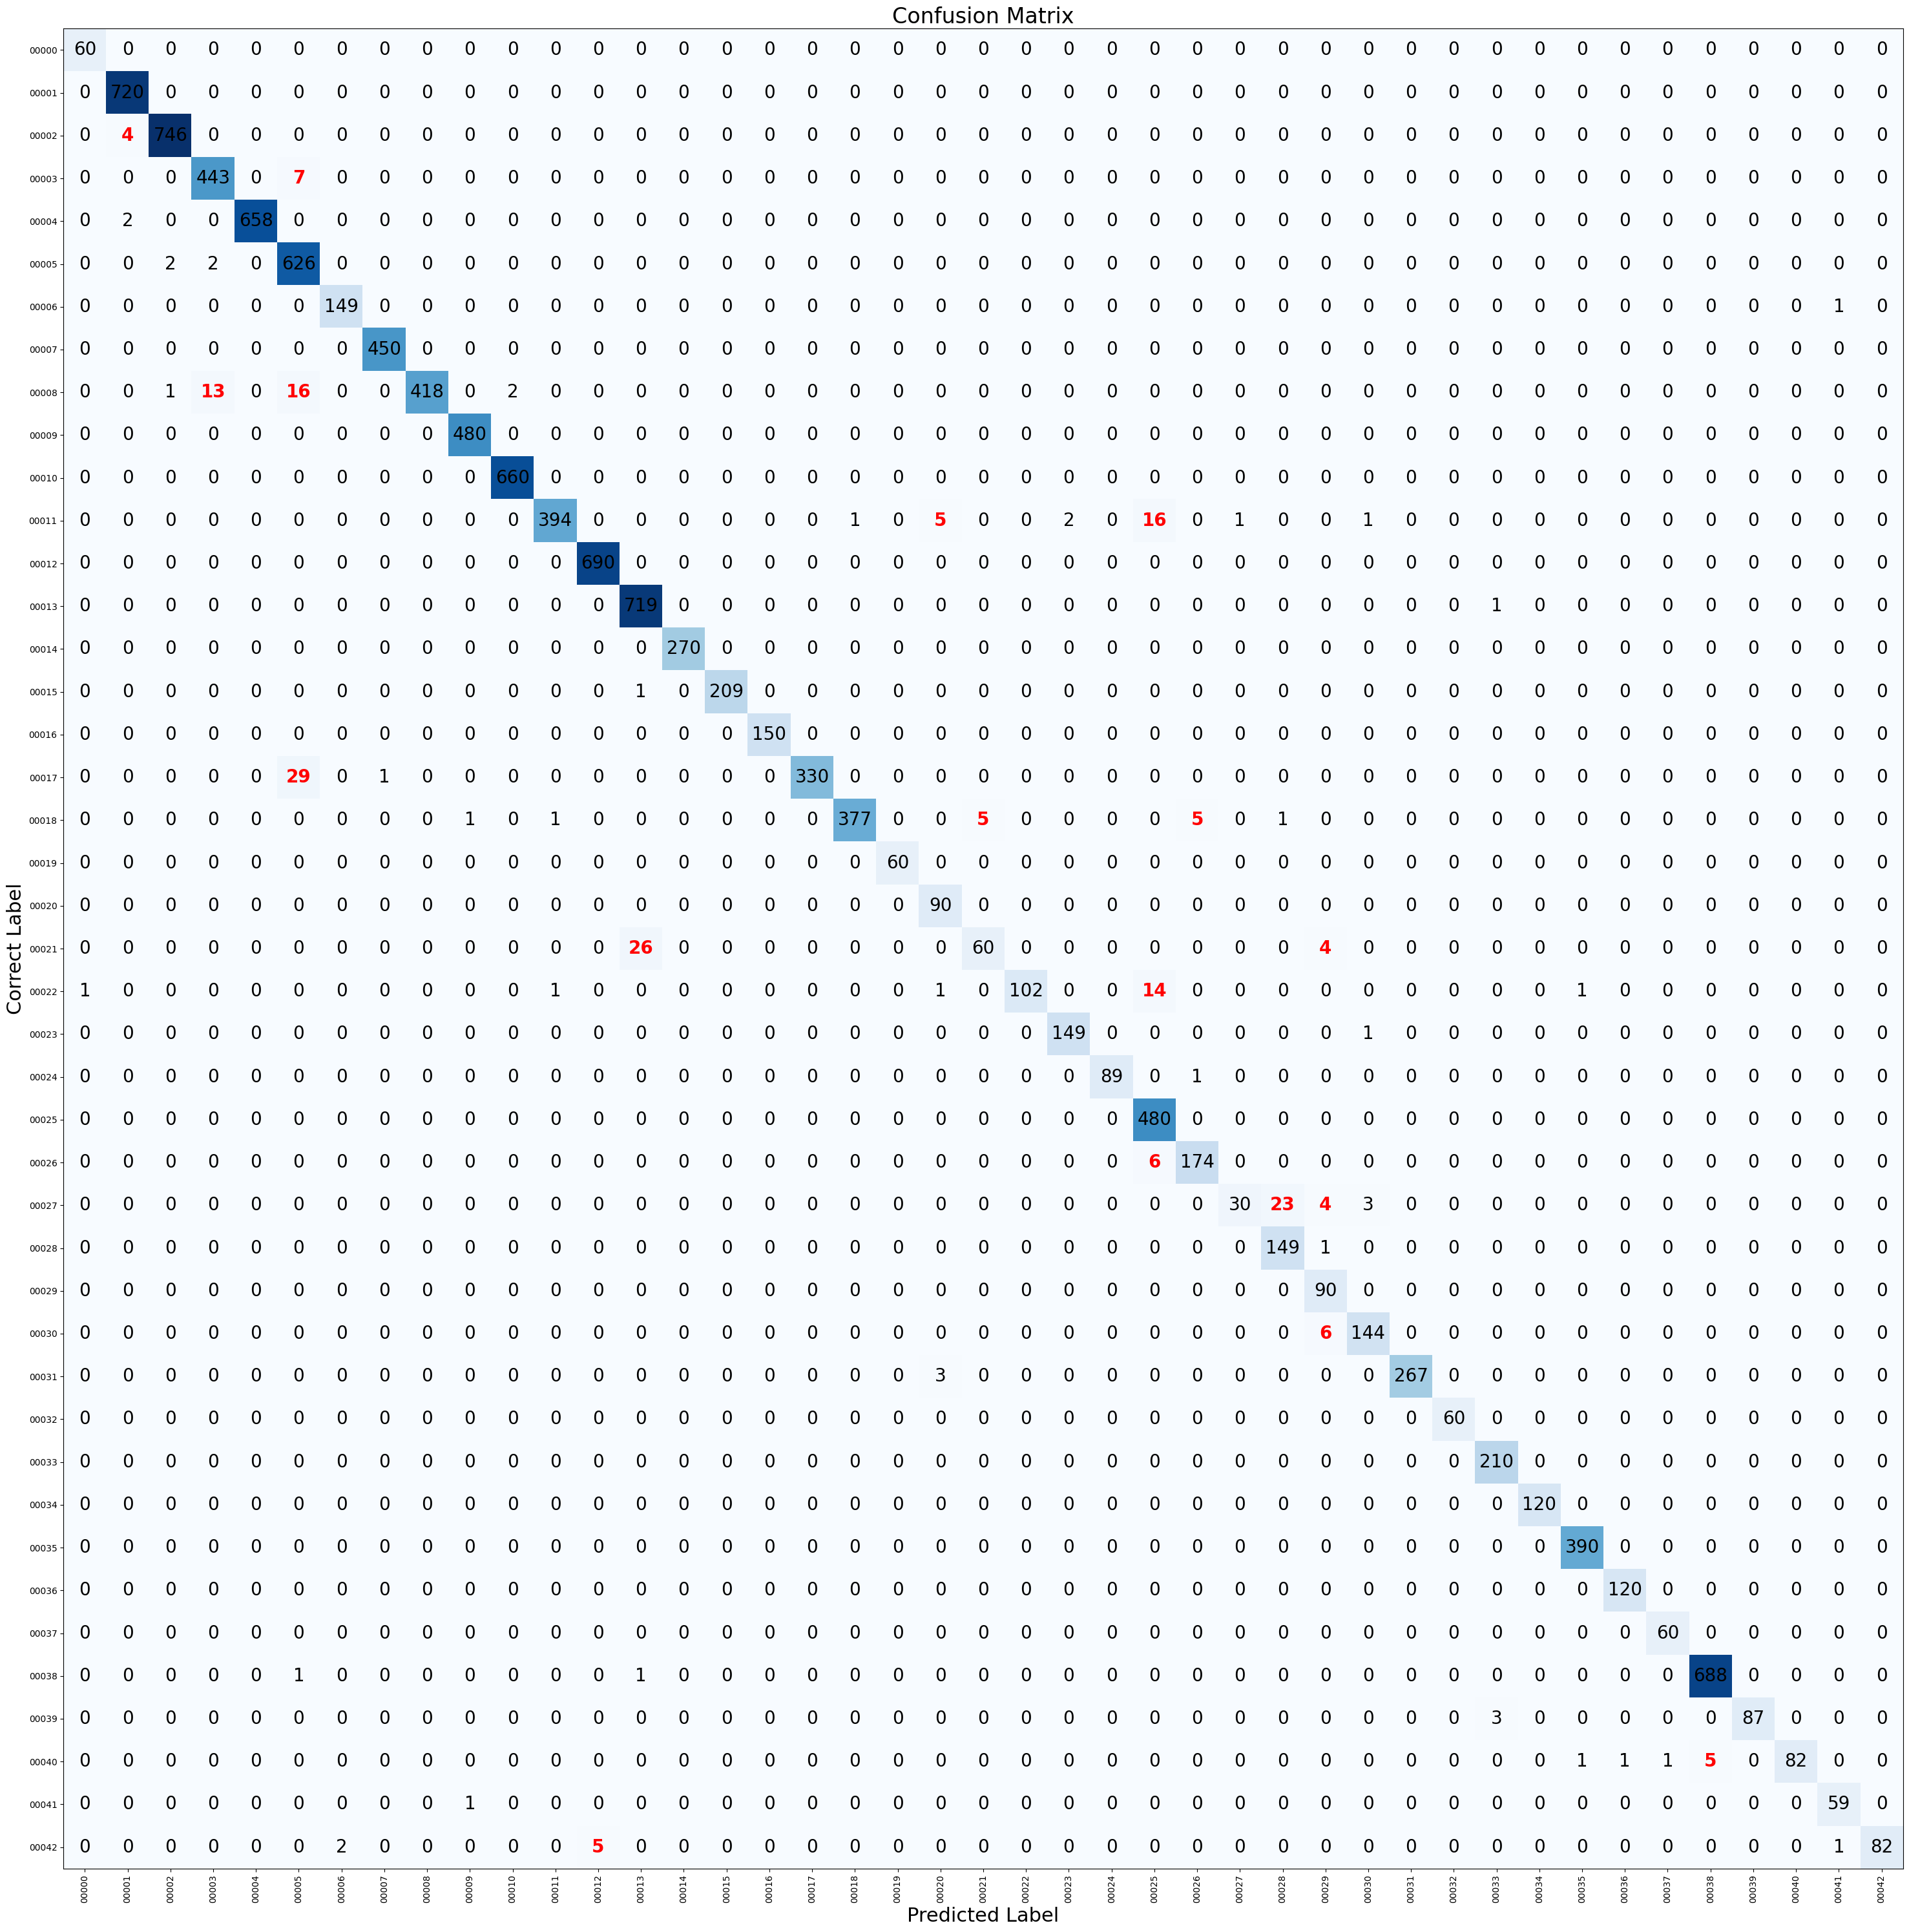

In [24]:
plot_confusion_matrix_highlight(model_Conv, test_loader, test_set.classes, threshold=3)

# __Dynamic Augmentation - Random Erasing__

RandomErasing is used as a data augmentation technique to improve the model’s robustness to partial occlusions and missing visual information. It randomly removes rectangular regions of the input image and replaces them with random pixel values, forcing the model to learn from incomplete observations.

In the German Traffic Sign Recognition Benchmark (GTSRB), traffic signs may be partially occluded by objects such as vehicles, pedestrians, vegetation, or infrastructure elements. Additionally, certain image regions may be degraded due to motion or acquisition artifacts, resulting in missing or less informative visual cues.

By introducing controlled occlusions during training, RandomErasing encourages the network to rely on global and distributed feature representations rather than depending on specific localized patterns. This leads to improved generalization and increased robustness to real-world visibility limitations within the dataset.

In [25]:
transform_aug = v2.Compose([
    v2.Resize((32, 32)),

    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),

    v2.RandomErasing(
        p=0.5,
        scale=(0.02, 0.08),
        ratio=(0.3, 3.3),
        value='random'
    )
])

train_set = torchvision.datasets.ImageFolder(
    root=PATH_TRAINING_SET,
    transform=transform_aug
)

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [26]:
loss_fn = torch.nn.CrossEntropyLoss()

for i in range(RUNS):
    model_Conv_II = Conv_II(len(train_set.classes))
    model_Conv_II.to(device)

    early_stop = Early_Stopping(9)
    optimizer_II = torch.optim.Adam(model_Conv_II.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_II, mode='min', factor = 0.1, patience=3)    
    history_II = train_III(model_Conv_II, train_loader, val_loader, EPOCHS, loss_fn, optimizer_II, scheduler, early_stop, f'model_weights/dynamic_randomErasing_aug_I_{i}')

Epoch: 000; Loss: 2.640344; Accuracy: 24.8451; Val Loss: 1.886098; Val Acc: 41.2588; Elapsed time: 27.2825
Epoch: 001; Loss: 1.536766; Accuracy: 52.3156; Val Loss: 0.929869; Val Acc: 73.0410; Elapsed time: 26.7844
Epoch: 002; Loss: 0.780176; Accuracy: 77.9387; Val Loss: 0.271506; Val Acc: 95.7991; Elapsed time: 26.7631
Epoch: 003; Loss: 0.393965; Accuracy: 89.6908; Val Loss: 0.109980; Val Acc: 98.5573; Elapsed time: 26.9403
Epoch: 004; Loss: 0.265869; Accuracy: 93.0206; Val Loss: 0.036122; Val Acc: 99.4059; Elapsed time: 27.2048
Epoch: 005; Loss: 0.205967; Accuracy: 94.4578; Val Loss: 0.032358; Val Acc: 99.4059; Elapsed time: 26.9623
Epoch: 006; Loss: 0.173614; Accuracy: 95.2301; Val Loss: 0.024728; Val Acc: 99.8444; Elapsed time: 26.9954
Epoch: 007; Loss: 0.149551; Accuracy: 95.7705; Val Loss: 0.023568; Val Acc: 99.5474; Elapsed time: 26.5432
Epoch: 008; Loss: 0.130283; Accuracy: 96.2882; Val Loss: 0.009265; Val Acc: 99.8727; Elapsed time: 26.9848
Epoch: 009; Loss: 0.121844; Accuracy:

In [27]:
# =========================================================
# TEST RESULTS
# =========================================================

res = 0

model_Conv = Conv_II(len(train_set.classes))
model_Conv.to(device)

print('\n========== DYNAMIC RANDOM ERASING RESULTS ==========')

for i in range(RUNS):

    # -----------------------------------------------------
    # Load best checkpoint
    # -----------------------------------------------------

    checkpoint = torch.load(
        f'model_weights/dynamic_randomErasing_aug_I_{i}.pt'
    )

    model_Conv.load_state_dict(checkpoint['model'])

    # -----------------------------------------------------
    # Metrics
    # -----------------------------------------------------

    best_epoch = checkpoint['epoch']

    test_acc = evaluate(model_Conv, test_loader) * 100
    eval_acc = evaluate(model_Conv, val_loader) * 100

    # -----------------------------------------------------
    # Print run results
    # -----------------------------------------------------

    print(f'\nRUN {i + 1}')

    print(f'Best Epoch    : {best_epoch}')
    print(f'Eval Accuracy : {eval_acc:.2f}%')
    print(f'Test Accuracy : {test_acc:.2f}%')

    # -----------------------------------------------------
    # Mean test accuracy
    # -----------------------------------------------------

    res += test_acc

# =========================================================
# FINAL MEAN
# =========================================================

res /= RUNS

print('\n========== FINAL MEAN TEST ACCURACY ==========')
print(f'Mean Test Accuracy : {res:.2f}%')

dynamic_randomErasing_acc = res


========== DYNAMIC RANDOM ERASING RESULTS ==========

RUN 1
Best Epoch    : 29
Eval Accuracy : 100.00%
Test Accuracy : 98.31%

RUN 2
Best Epoch    : 29
Eval Accuracy : 100.00%
Test Accuracy : 98.65%

RUN 3
Best Epoch    : 28
Eval Accuracy : 100.00%
Test Accuracy : 98.54%

========== FINAL MEAN TEST ACCURACY ==========
Mean Test Accuracy : 98.50%


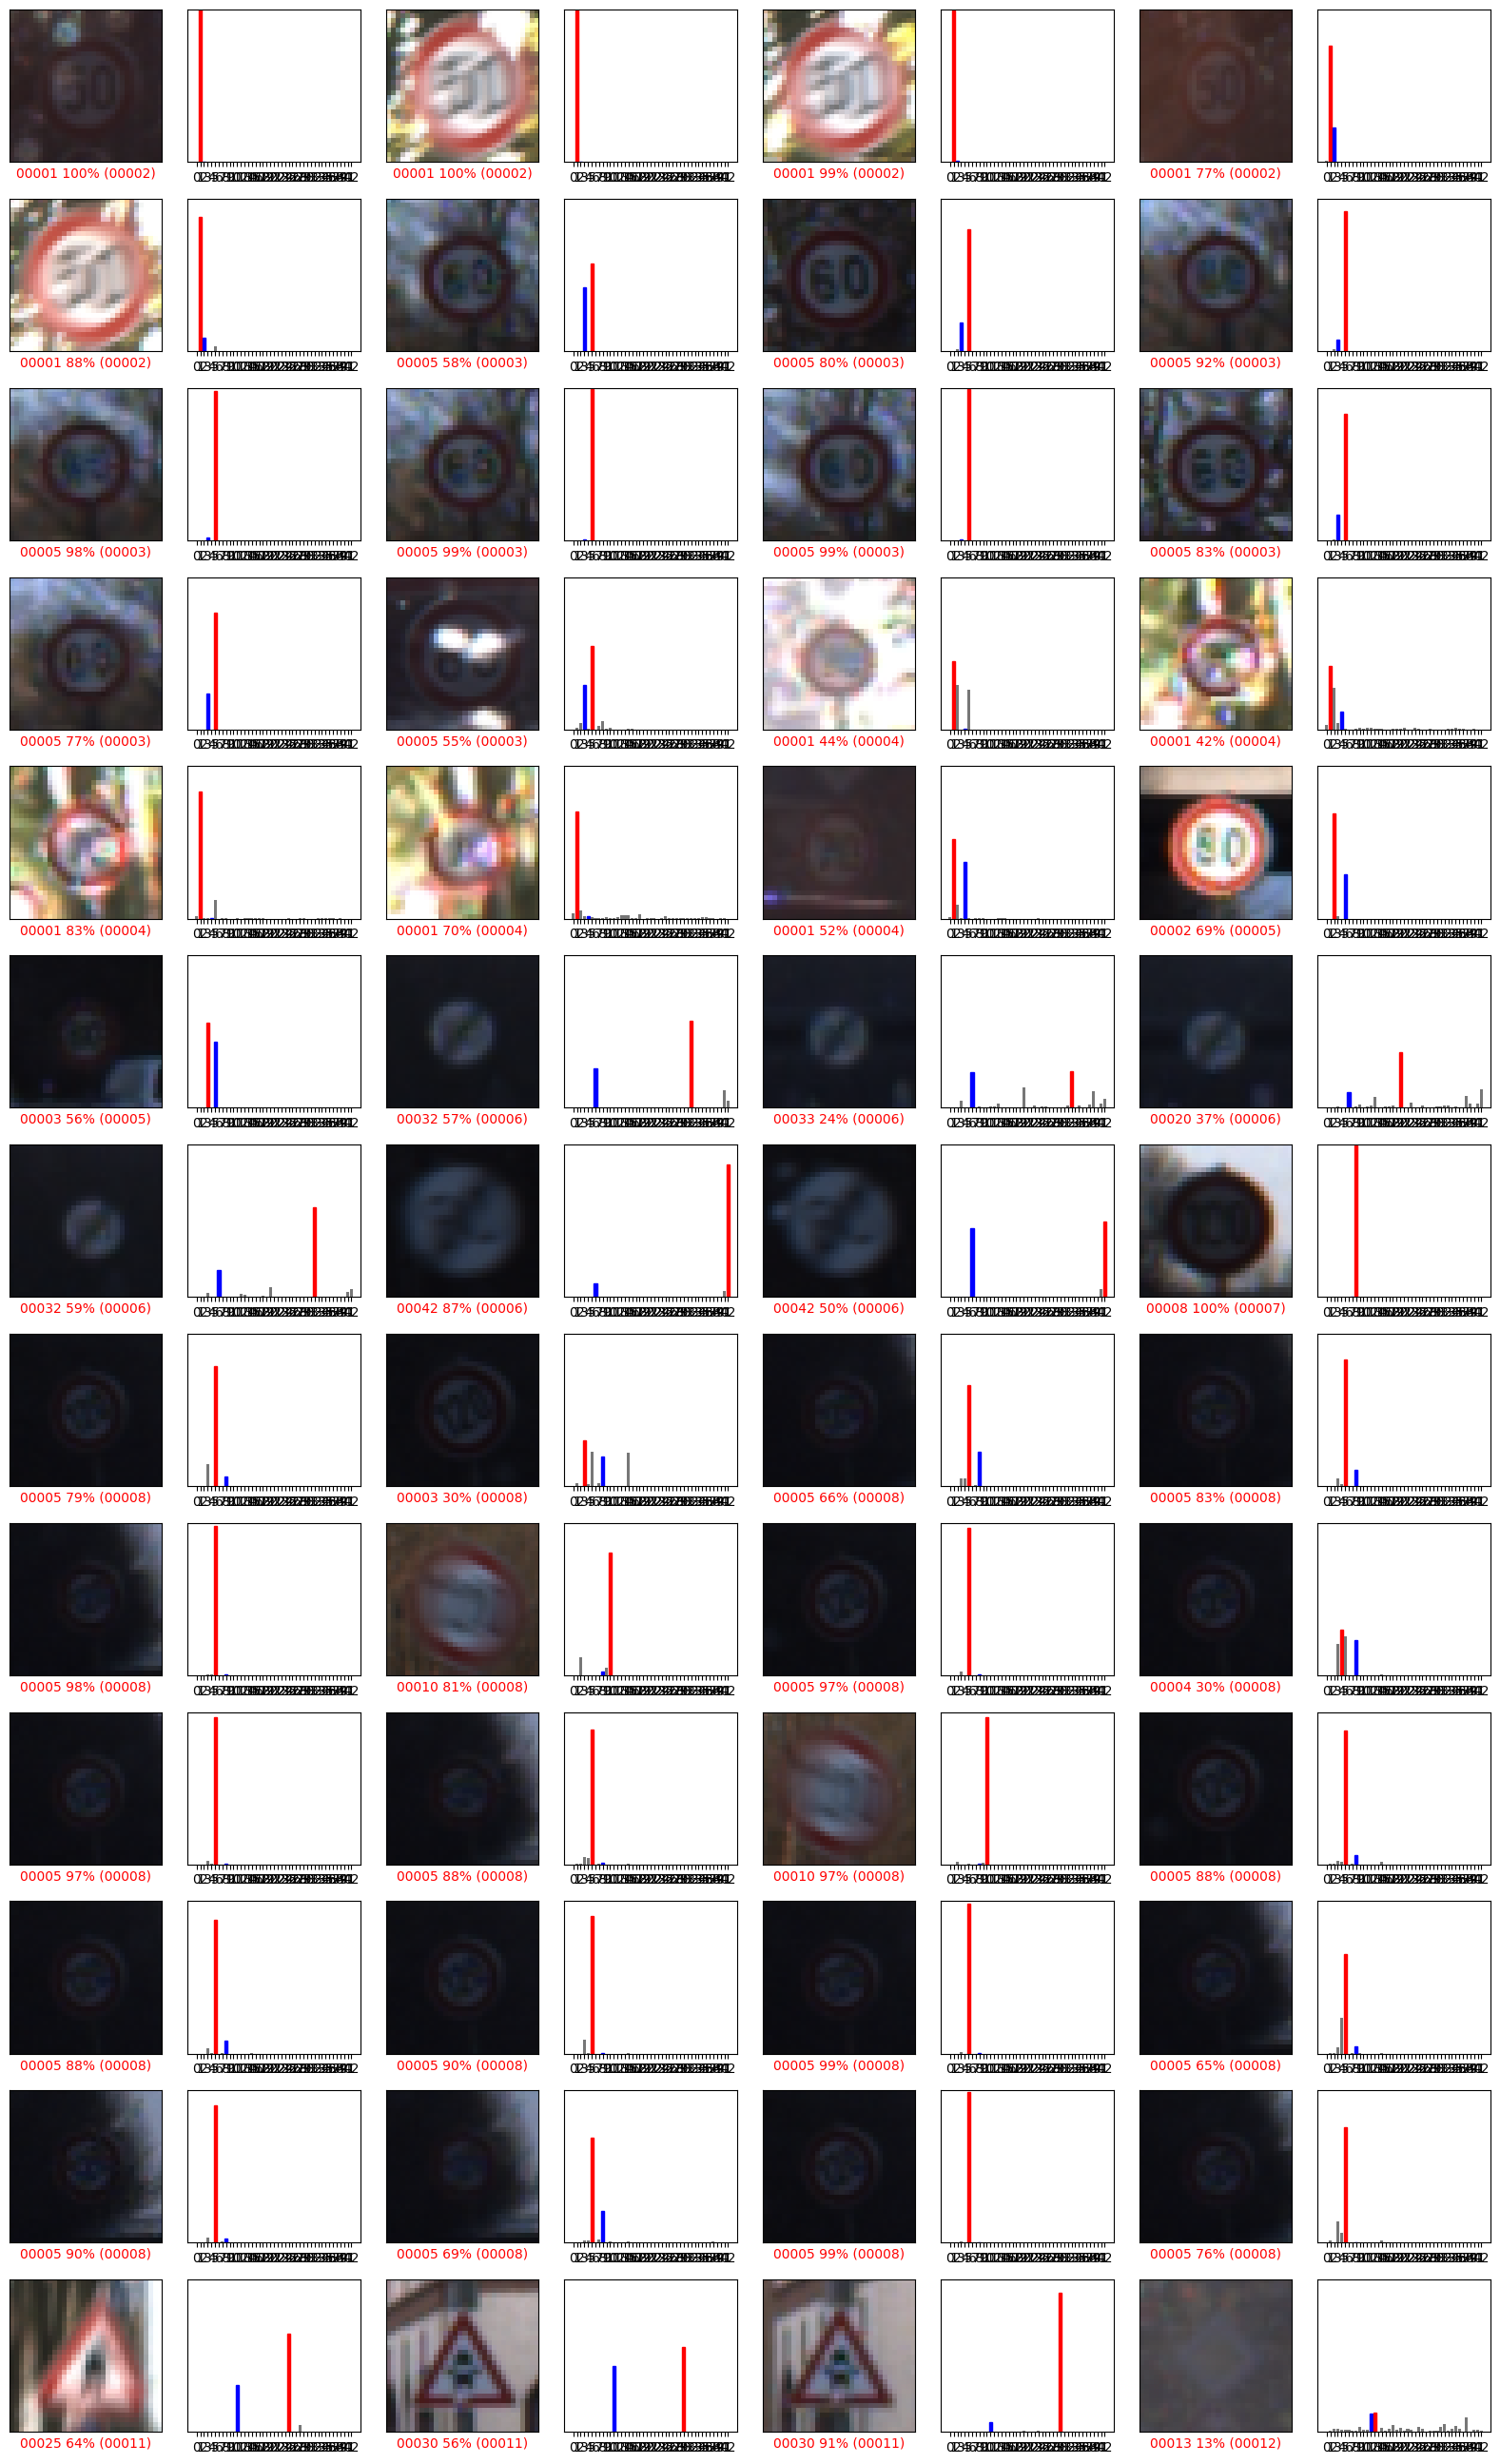

In [28]:
show_bad_preds(model_Conv, test_loader, test_set.classes)   

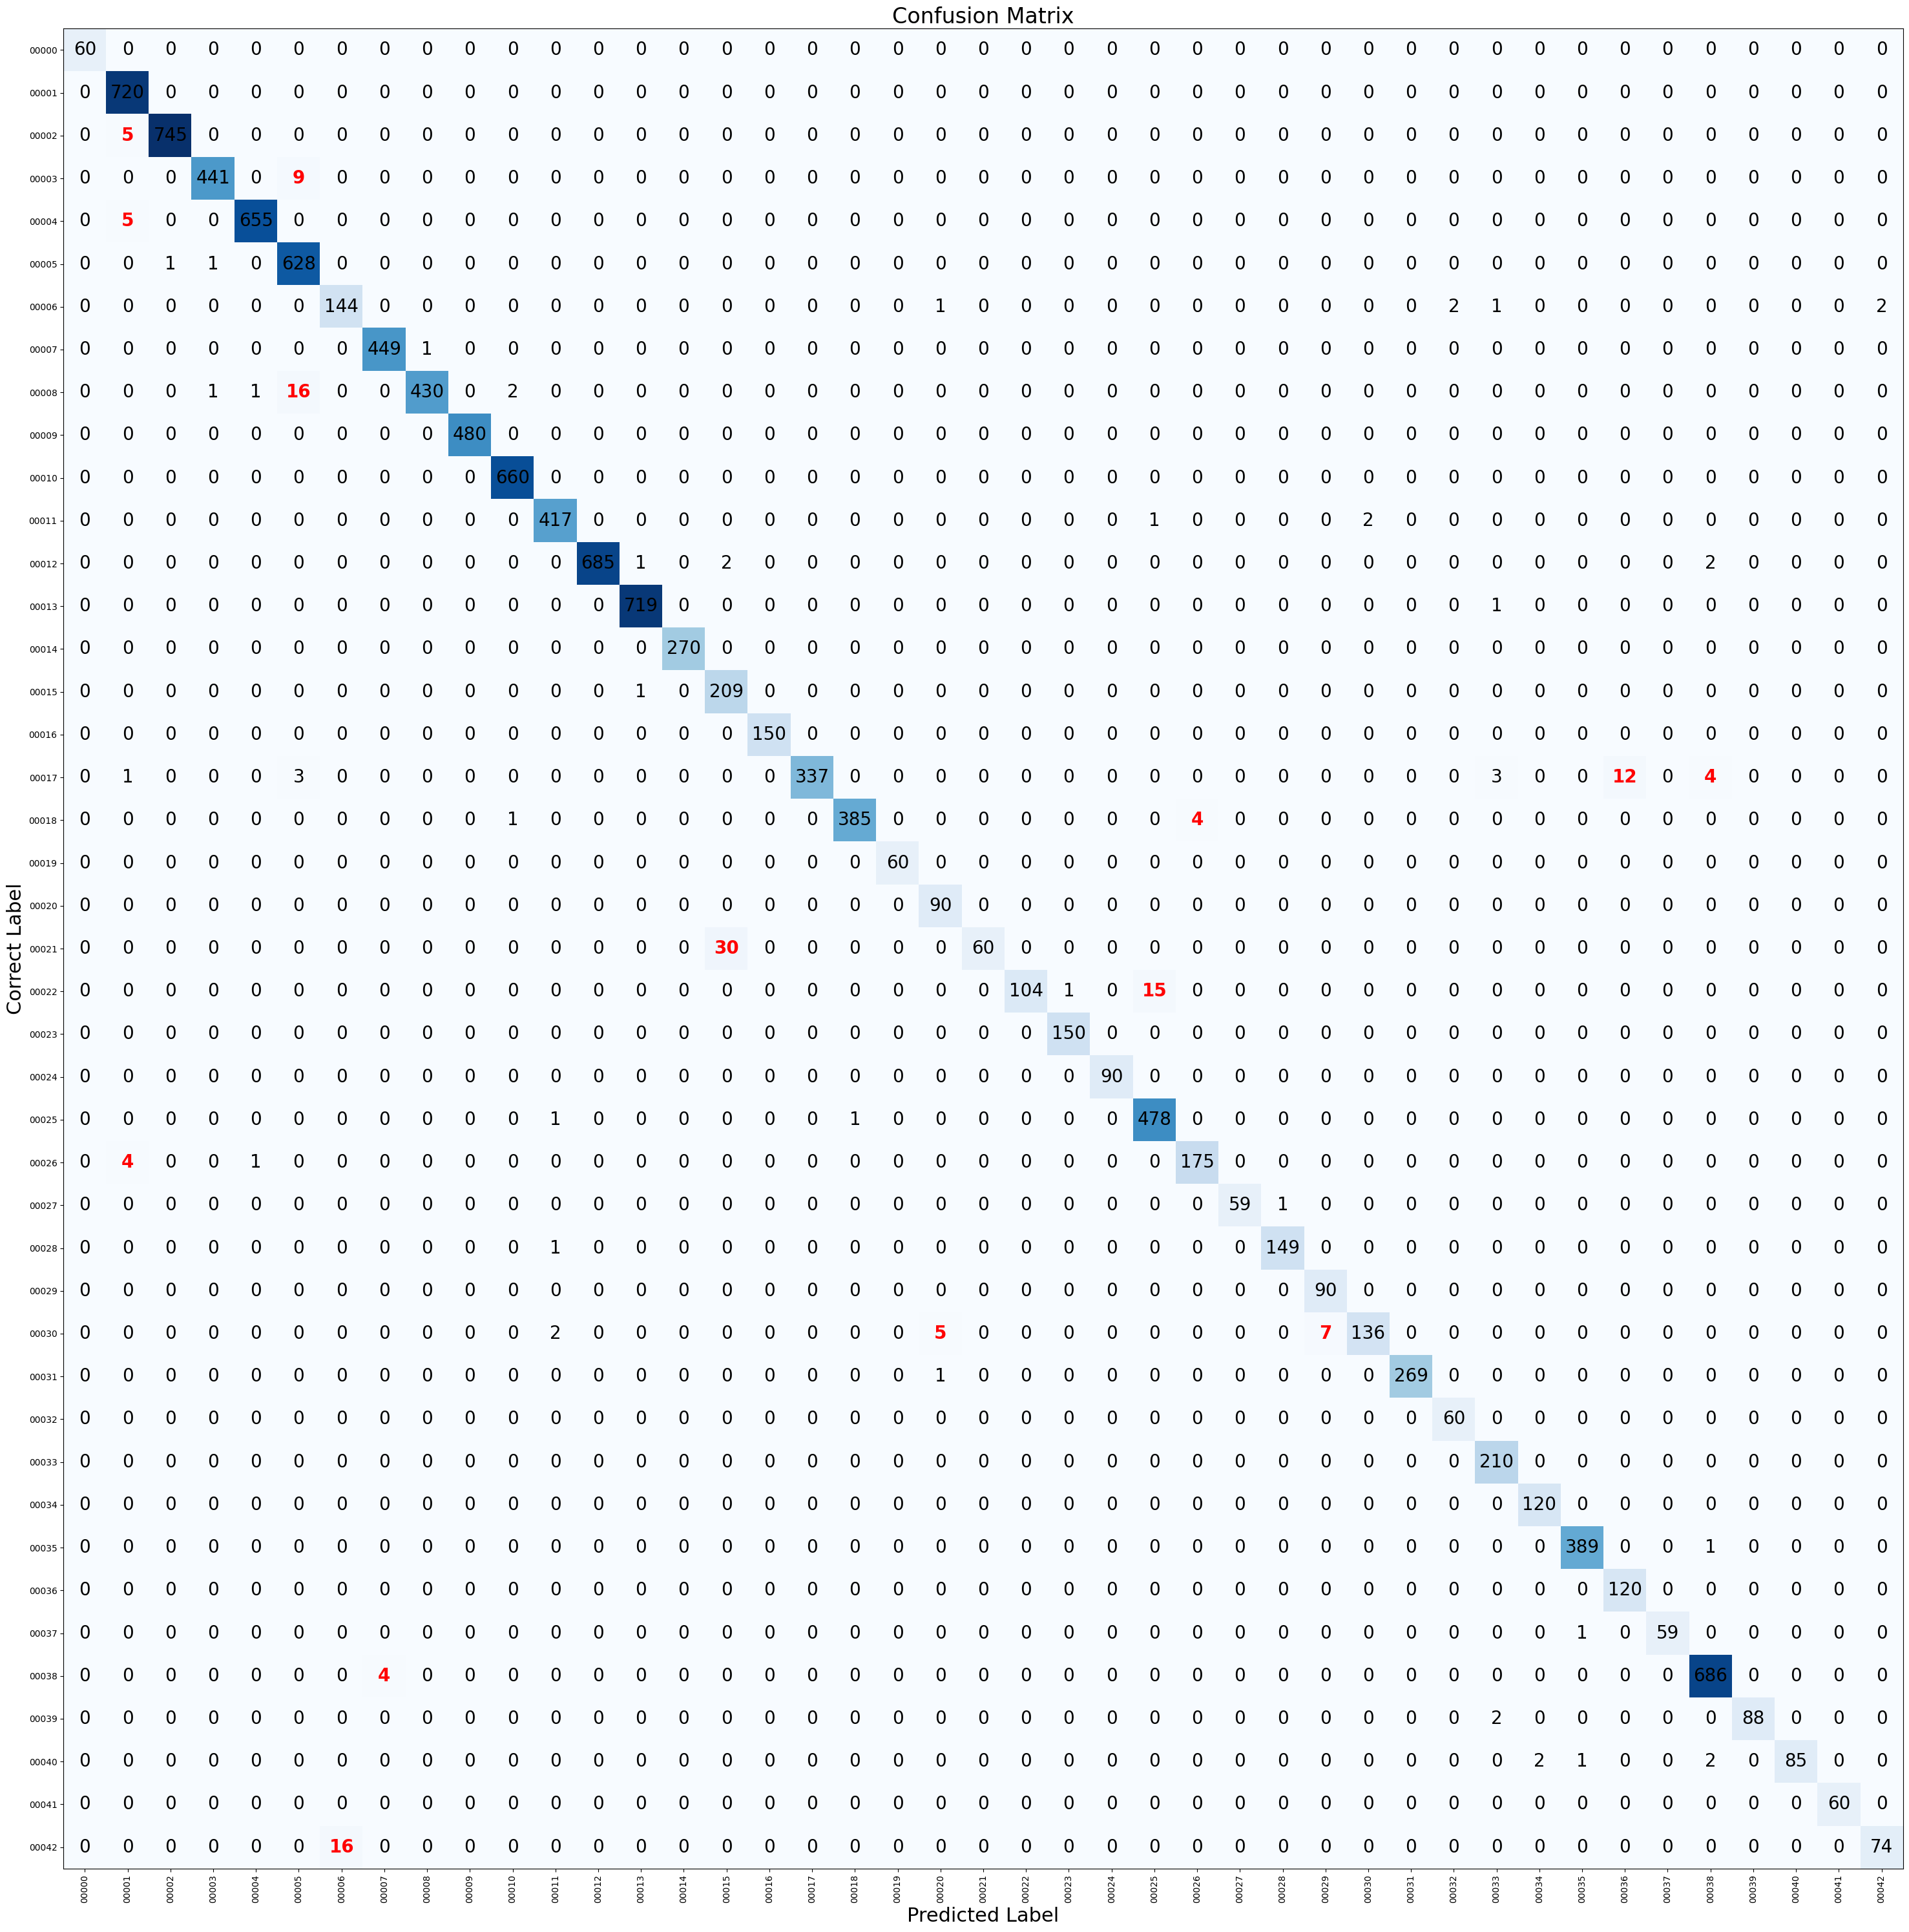

In [29]:
plot_confusion_matrix_highlight(model_Conv, test_loader, test_set.classes, threshold=3)

# __Dynamic Augmentation - All__

This augmentation pipeline combines multiple complementary data augmentation techniques in order to leverage the individual benefits of each transformation while maintaining a realistic data distribution. The objective is to improve the model’s robustness to the diverse types of variability present in traffic sign images.

In the German Traffic Sign Recognition Benchmark (GTSRB), traffic signs can exhibit simultaneous variations in geometry, lighting conditions, image sharpness, and partial occlusions. To address this, different augmentations are applied probabilistically using RandomApply, ensuring that each transformation is introduced in a controlled and non-deterministic manner.

Geometric transformations (RandomAffine) improve robustness to viewpoint changes and slight misalignments, photometric transformations (ColorJitter) address variations in illumination and color intensity, and Gaussian Blur simulates reduced image quality or focus imperfections. Finally, RandomErasing introduces partial occlusions, encouraging the model to learn more distributed and robust feature representations.

By combining these augmentations within a unified pipeline, the model is exposed to a richer and more diverse training distribution, leading to improved generalization and better performance under real-world variability conditions present in the dataset.

In [30]:
transform_aug = v2.Compose([

    # resolução maior para preservar números
    v2.Resize((32, 32)),

    # pequenas transformações geométricas
    v2.RandomApply([
        v2.RandomAffine(
            degrees=15,
            translate=(0.1, 0.1),
            scale=(0.9, 1.1),
            shear=15,
            interpolation=v2.InterpolationMode.BILINEAR
        )
    ], p=0.7),

    # variações de iluminação
    v2.RandomApply([
        v2.ColorJitter(
            brightness=0.5,
            contrast=0.5,
            saturation=0.15,
            hue=0.03
        )
    ], p=0.5),

    # ajuda com imagens desfocadas/reais
    v2.RandomApply([
        v2.GaussianBlur(
            kernel_size=3,
            sigma=(0.1, 0.4)
        )
    ], p=0.3),

    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),

    # oclusões pequenas
    v2.RandomErasing(
        p=0.15,
        scale=(0.01, 0.04),
        ratio=(0.5, 2.0),
        value='random'
    )
])

train_set = torchvision.datasets.ImageFolder(
    root=PATH_TRAINING_SET,
    transform=transform_aug
)

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

In [31]:
loss_fn = torch.nn.CrossEntropyLoss()

for i in range(RUNS):
    model_Conv_II = Conv_II(len(train_set.classes))
    model_Conv_II.to(device)

    early_stop = Early_Stopping(9)
    optimizer_II = torch.optim.Adam(model_Conv_II.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_II, mode='min', factor = 0.1, patience=3)    
    history_II = train_III(model_Conv_II, train_loader, val_loader, EPOCHS, loss_fn, optimizer_II, scheduler, early_stop, f'model_weights/dynamic_all_aug_I_{i}')

Epoch: 000; Loss: 2.668986; Accuracy: 24.6697; Val Loss: 1.797628; Val Acc: 43.1966; Elapsed time: 41.4582
Epoch: 001; Loss: 1.590612; Accuracy: 51.0001; Val Loss: 1.038529; Val Acc: 67.6803; Elapsed time: 36.1288
Epoch: 002; Loss: 0.833538; Accuracy: 76.3459; Val Loss: 0.313065; Val Acc: 94.8656; Elapsed time: 35.7395
Epoch: 003; Loss: 0.449295; Accuracy: 88.1376; Val Loss: 0.111040; Val Acc: 98.6139; Elapsed time: 35.4094
Epoch: 004; Loss: 0.298432; Accuracy: 92.2256; Val Loss: 0.053831; Val Acc: 99.5332; Elapsed time: 36.3999
Epoch: 005; Loss: 0.224506; Accuracy: 94.2258; Val Loss: 0.054039; Val Acc: 99.5757; Elapsed time: 35.5176
Epoch: 006; Loss: 0.186559; Accuracy: 95.0972; Val Loss: 0.021509; Val Acc: 99.7313; Elapsed time: 35.5470
Epoch: 007; Loss: 0.153682; Accuracy: 95.9459; Val Loss: 0.022620; Val Acc: 99.5898; Elapsed time: 35.3369
Epoch: 008; Loss: 0.139311; Accuracy: 96.3561; Val Loss: 0.015062; Val Acc: 99.7030; Elapsed time: 36.0079
Epoch: 009; Loss: 0.133297; Accuracy:

In [32]:
# =========================================================
# TEST RESULTS
# =========================================================

res = 0

model_Conv = Conv_II(len(train_set.classes))
model_Conv.to(device)

print('\n========== DYNAMIC ALL RESULTS ==========')

for i in range(RUNS):

    # -----------------------------------------------------
    # Load best checkpoint
    # -----------------------------------------------------

    checkpoint = torch.load(
        f'model_weights/dynamic_all_aug_I_{i}.pt'
    )

    model_Conv.load_state_dict(checkpoint['model'])

    # -----------------------------------------------------
    # Metrics
    # -----------------------------------------------------

    best_epoch = checkpoint['epoch']

    test_acc = evaluate(model_Conv, test_loader) * 100
    eval_acc = evaluate(model_Conv, val_loader) * 100

    # -----------------------------------------------------
    # Print run results
    # -----------------------------------------------------

    print(f'\nRUN {i + 1}')

    print(f'Best Epoch    : {best_epoch}')
    print(f'Eval Accuracy : {eval_acc:.2f}%')
    print(f'Test Accuracy : {test_acc:.2f}%')

    # -----------------------------------------------------
    # Mean test accuracy
    # -----------------------------------------------------

    res += test_acc

# =========================================================
# FINAL MEAN
# =========================================================

res /= RUNS

print('\n========== FINAL MEAN TEST ACCURACY ==========')
print(f'Mean Test Accuracy : {res:.2f}%')

dynamic_all_acc = res


========== DYNAMIC ALL RESULTS ==========

RUN 1
Best Epoch    : 29
Eval Accuracy : 100.00%
Test Accuracy : 99.33%

RUN 2
Best Epoch    : 28
Eval Accuracy : 100.00%
Test Accuracy : 99.28%

RUN 3
Best Epoch    : 28
Eval Accuracy : 100.00%
Test Accuracy : 99.38%

========== FINAL MEAN TEST ACCURACY ==========
Mean Test Accuracy : 99.33%


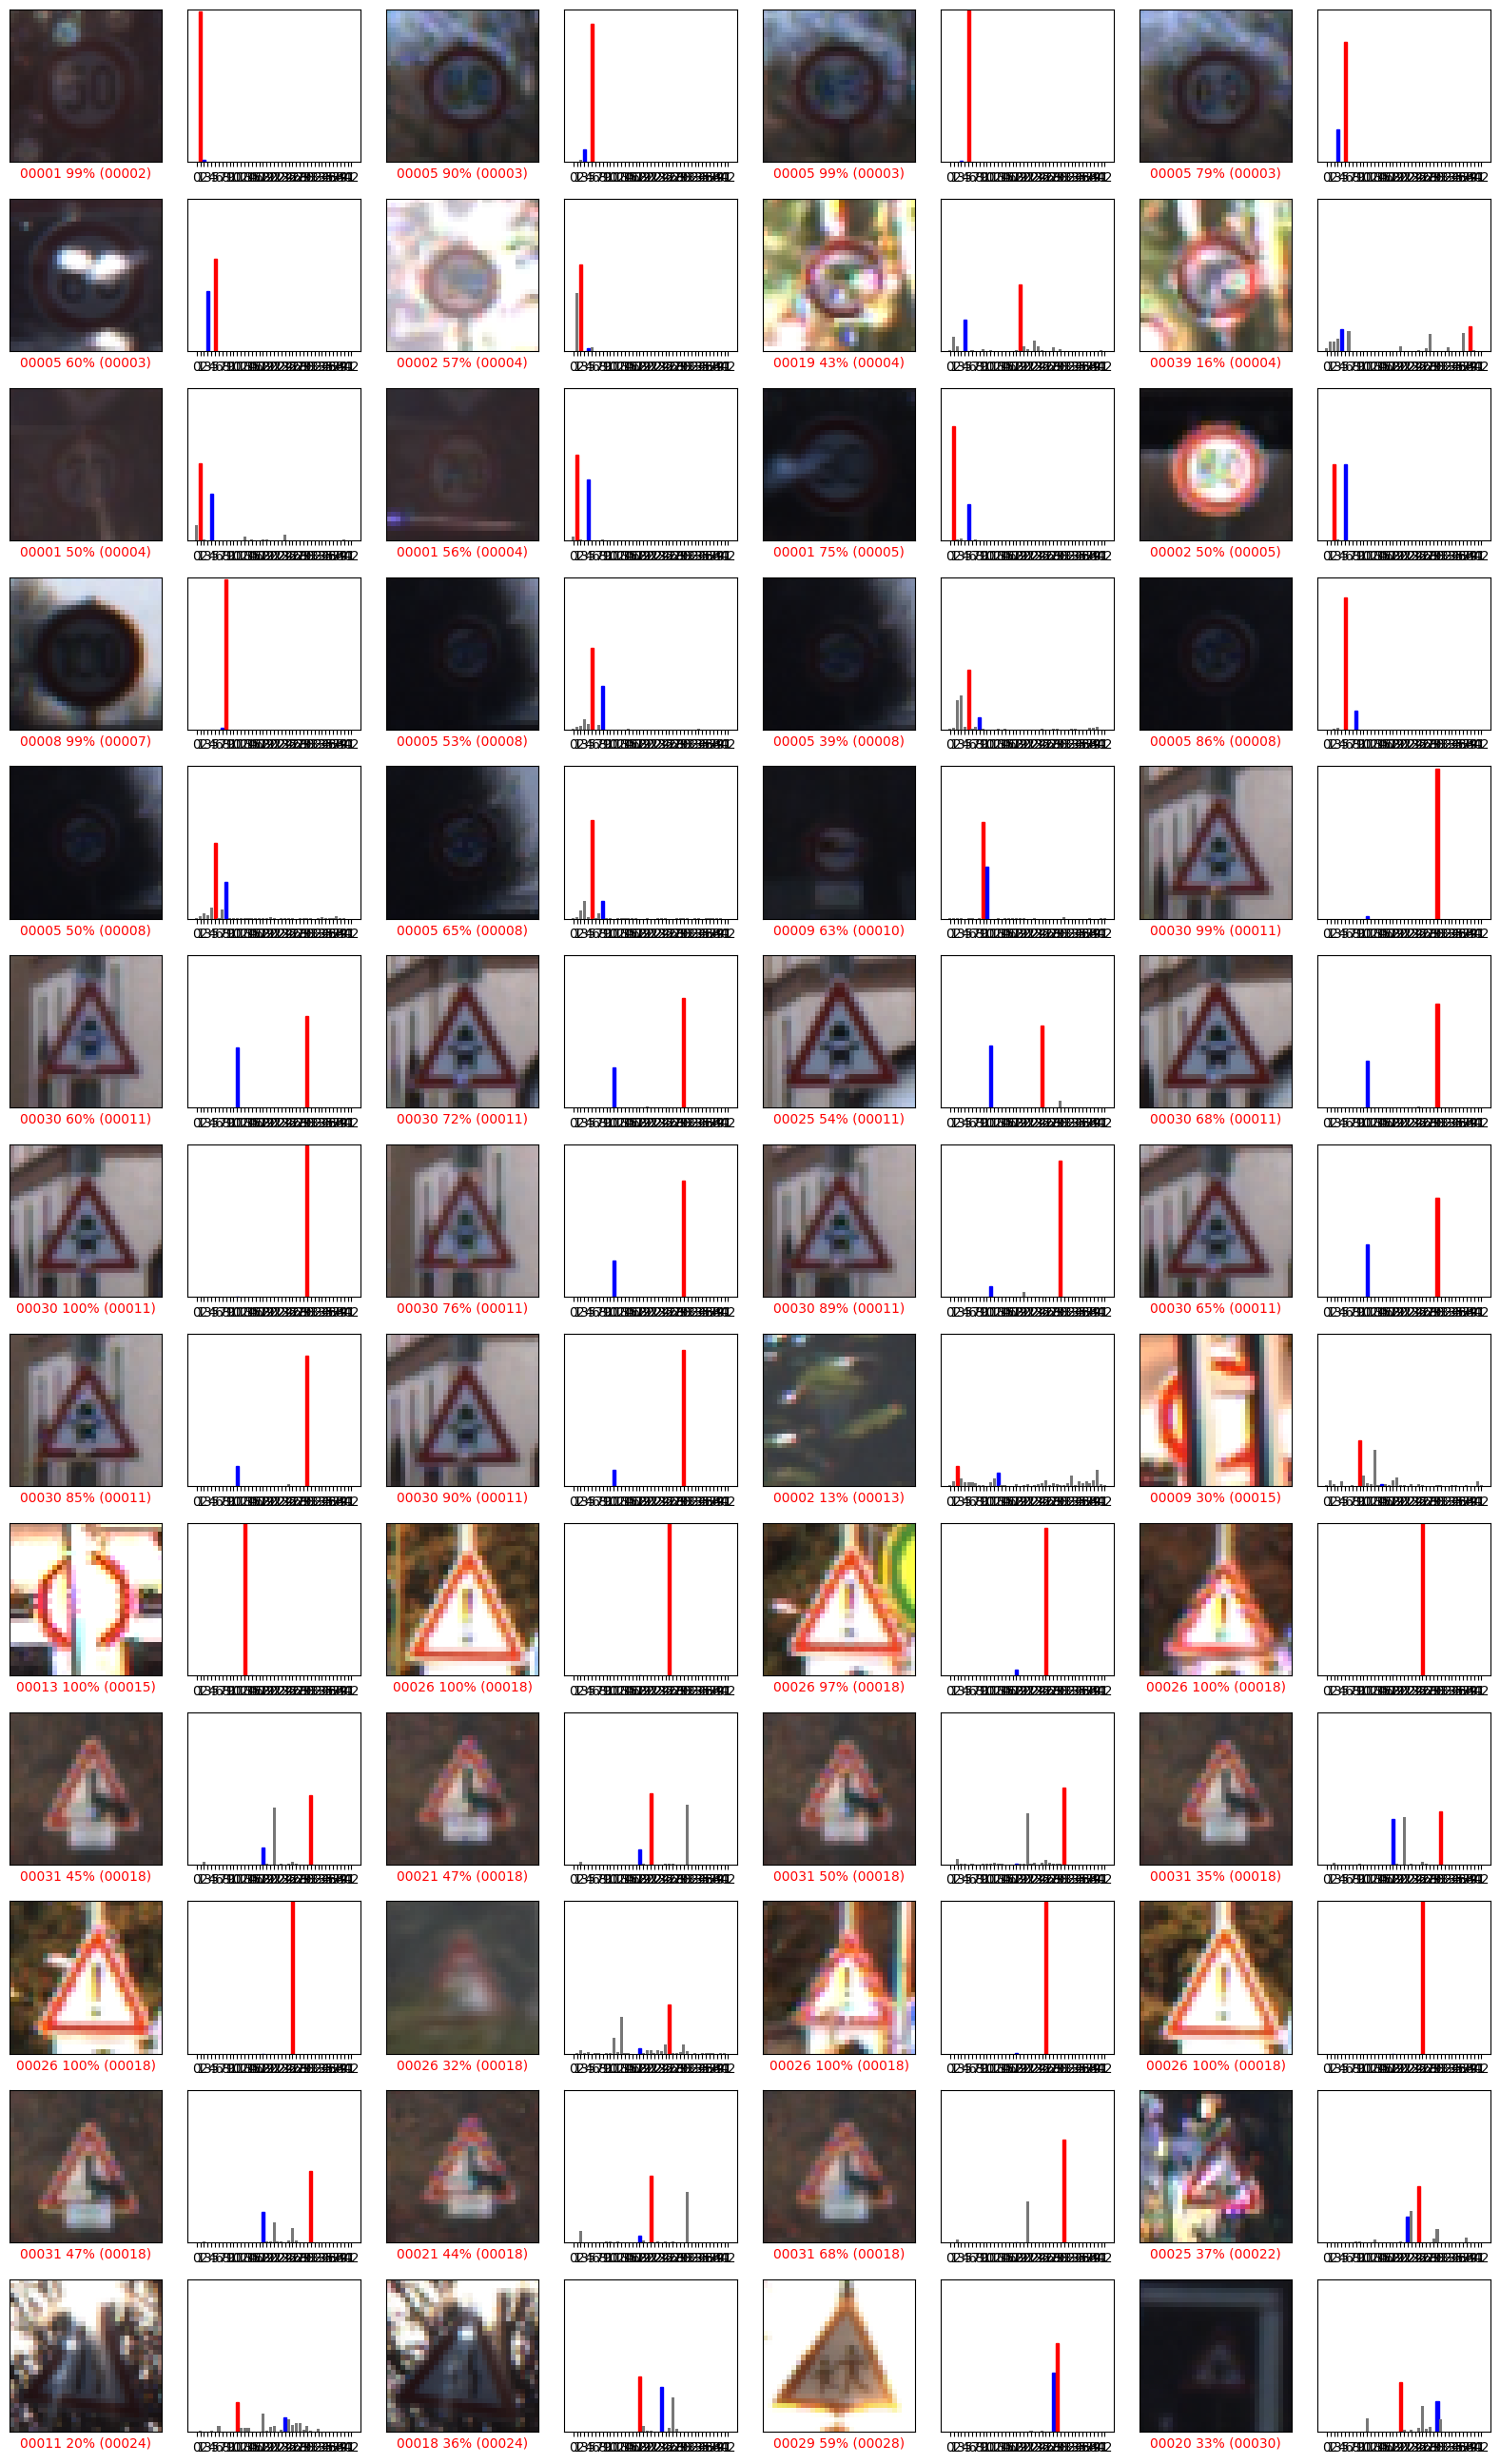

In [33]:
show_bad_preds(model_Conv, test_loader, test_set.classes)   

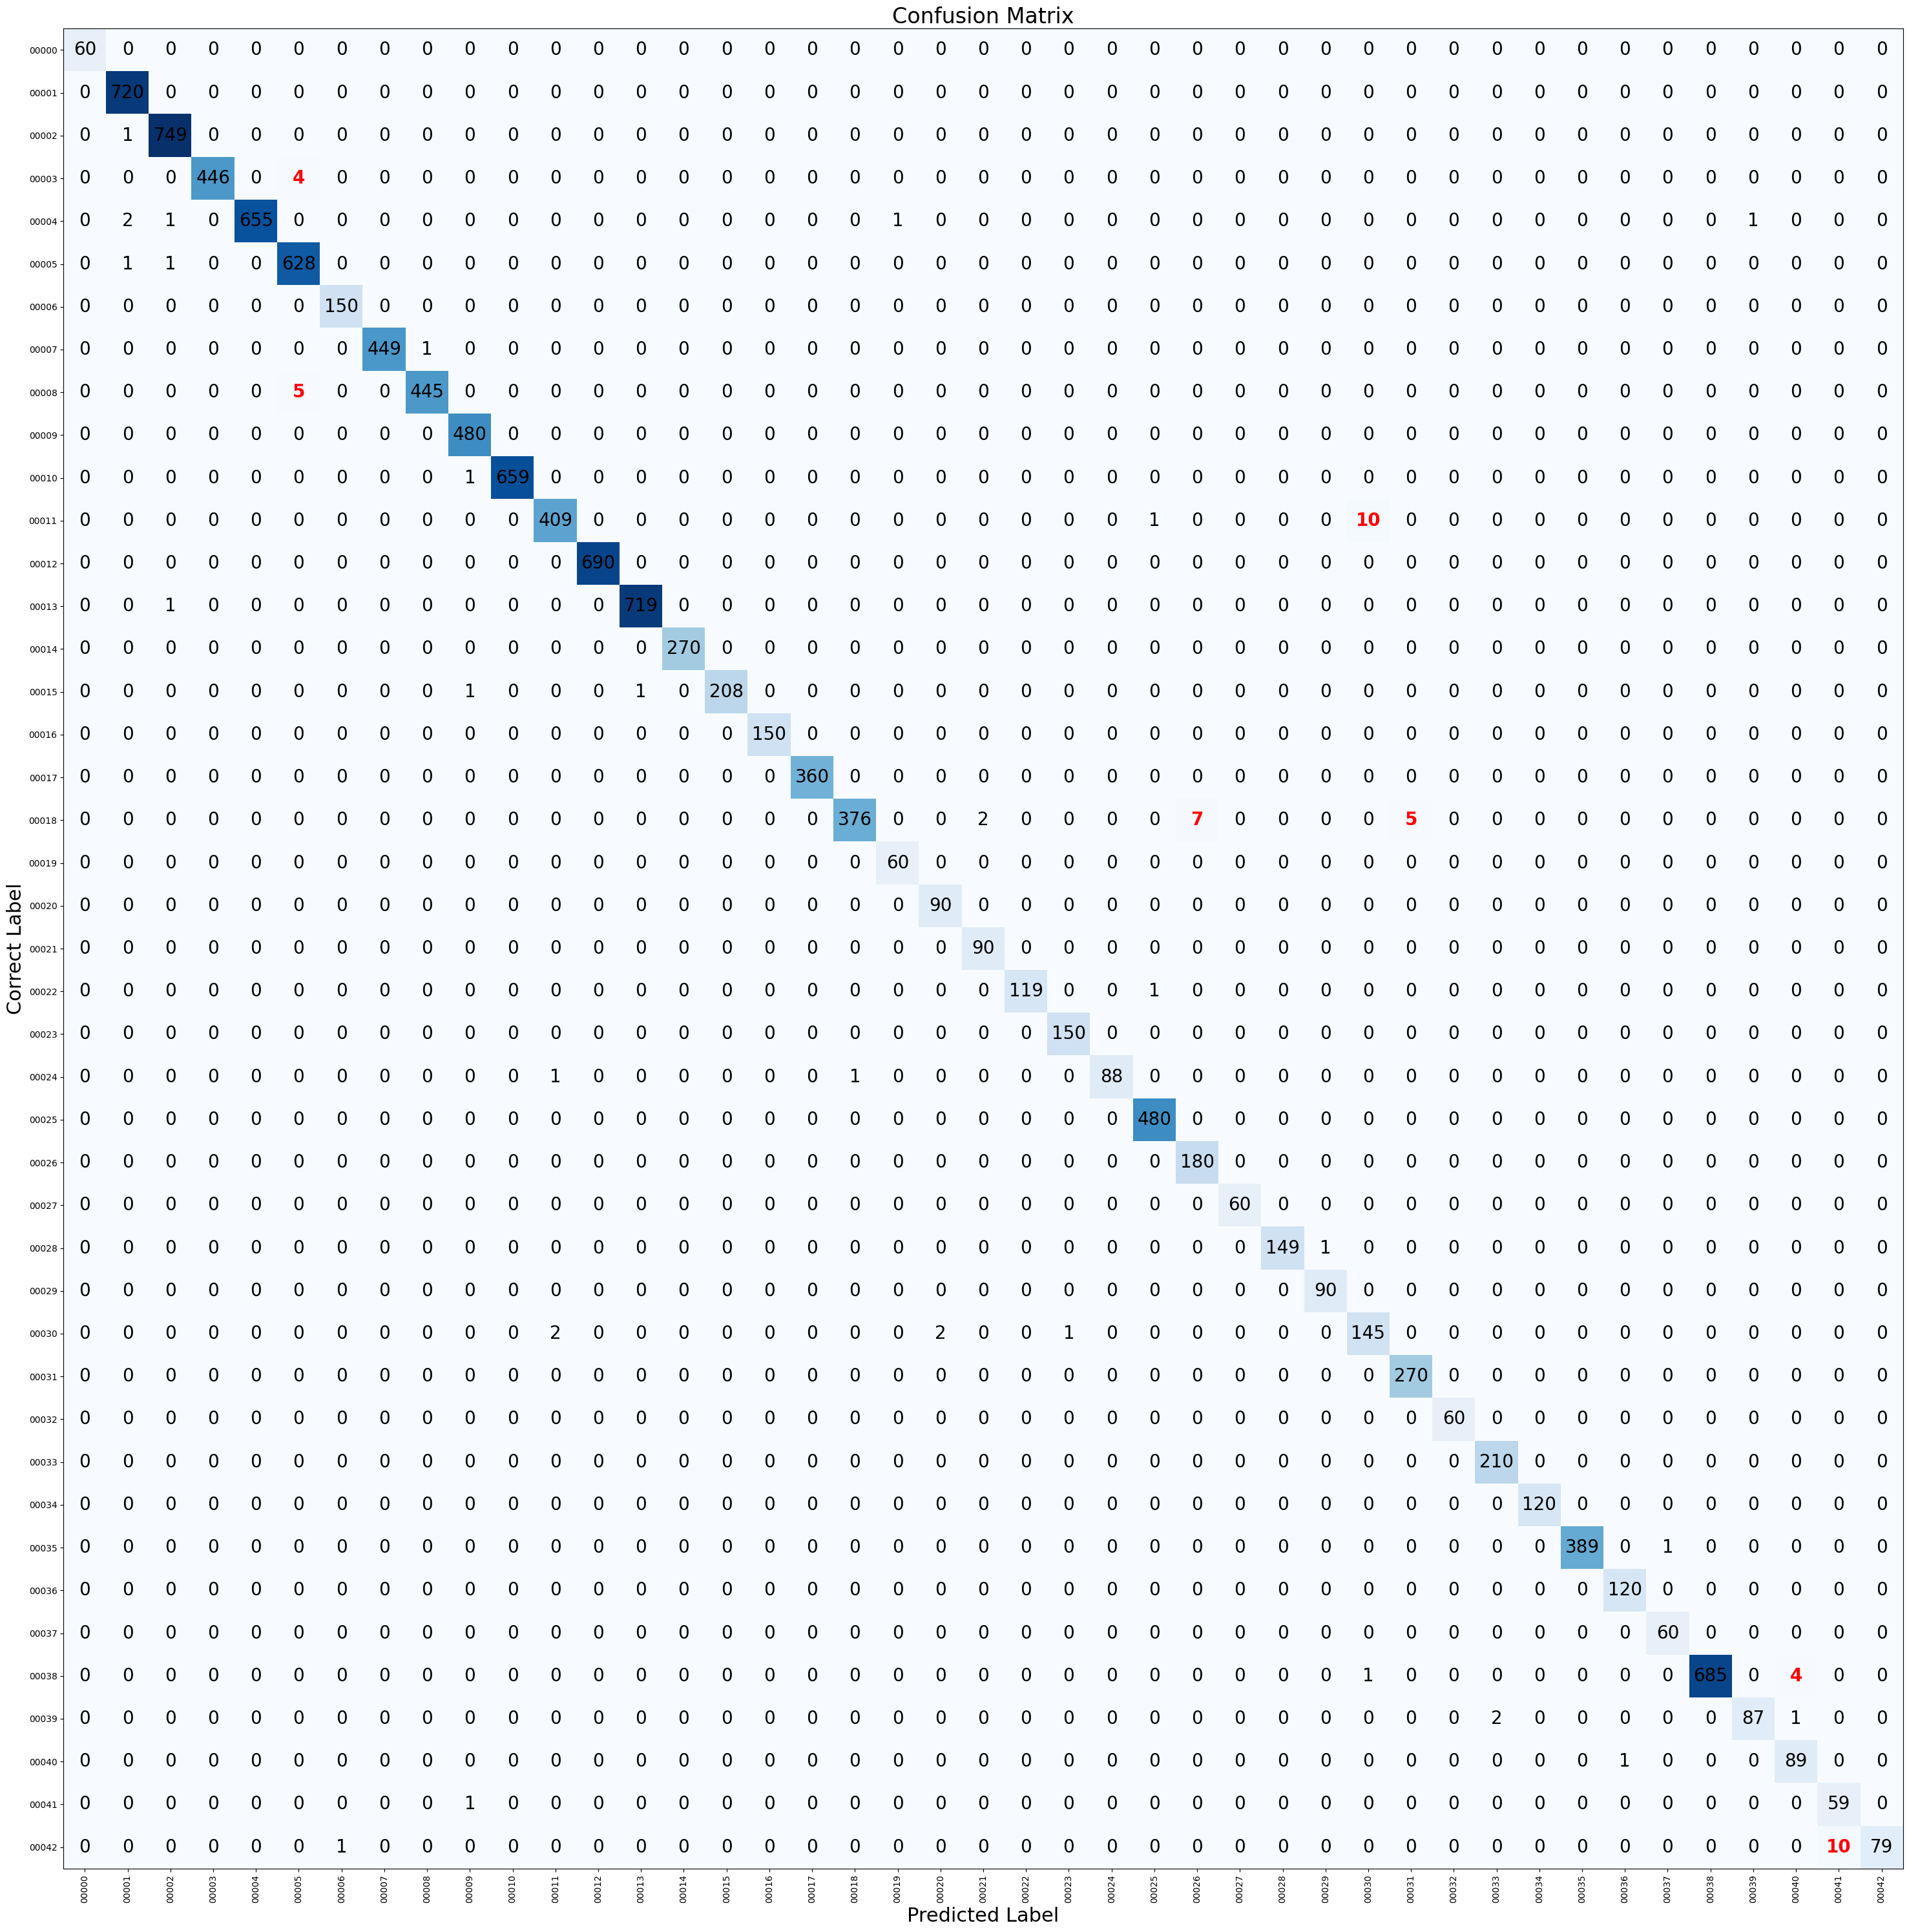

In [34]:
plot_confusion_matrix_highlight(model_Conv, test_loader, test_set.classes, threshold=3)

# __Changing to static augmentation from dynamic augmentation__

The following methods implement a static data augmentation strategy. In contrast to dynamic augmentation, where transformations are applied online during training, these approaches generate and store augmented samples offline before model training begins.

All static augmentation variants follow the same structural pipeline: the original dataset is iterated class by class, images are loaded from disk, and a fixed number of transformed versions are generated per image using a predefined augmentation function. Both the original and augmented images are then saved into a new dataset directory (AUG_PATH), which preserves the same class-wise folder structure as the original dataset to ensure compatibility with the ImageFolder loading mechanism.

This setup allows different static augmentation strategies to be evaluated fairly under identical training conditions, while isolating the impact of dataset-level transformations on model performance.

# __Static Augmentation - Color Jitter__

In [35]:
AUG_PATH = f'{BASE_PATH}/train_augmented_colorJitter'

In [36]:
transform_aug = v2.Compose([
    v2.Resize((32, 32)),

    v2.ColorJitter(
        brightness=0.5,
        contrast=0.5,
        saturation=0.2,
        hue=0.1
    ),

    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

In [37]:
dataset_original = torchvision.datasets.ImageFolder(
    root=PATH_TRAINING_SET
)

classes = dataset_original.classes

os.makedirs(AUG_PATH, exist_ok=True)

N_AUGS = 3

In [38]:
for class_name in classes:

    original_class_path = os.path.join(
        PATH_TRAINING_SET,
        class_name
    )

    aug_class_path = os.path.join(
        AUG_PATH,
        class_name
    )

    os.makedirs(aug_class_path, exist_ok=True)

    image_names = [

        img_name

        for img_name in os.listdir(original_class_path)

        if img_name.lower().endswith((
            '.png',
            '.jpg',
            '.jpeg',
            '.ppm'
        ))
    ]

    for img_name in image_names:

        img_path = os.path.join(
            original_class_path,
            img_name
        )

        img = Image.open(img_path).convert('RGB')

        # SAVE ORIGINAL

        img_resized = img.resize((32, 32))

        img_resized.save(

            os.path.join(
                aug_class_path,
                f'orig_{img_name}'
            )
        )

        # SAVE AUGMENTATIONS

        for k in range(N_AUGS):

            aug_img = transform_aug(img)

            aug_img_pil = torchvision.transforms.ToPILImage()(aug_img)

            aug_img_pil.save(

                os.path.join(
                    aug_class_path,
                    f'augmented_{k}_{img_name}'
                )
            )

In [39]:
loss_fn = torch.nn.CrossEntropyLoss()

for i in range(RUNS):
    model_Conv_II = Conv_II(len(full_train_set.classes))
    model_Conv_II.to(device)

    early_stop = Early_Stopping(9)
    optimizer_II = torch.optim.Adam(model_Conv_II.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_II, mode='min', factor = 0.1, patience=3)    
    history_II = train_III(model_Conv_II, train_loader, val_loader, EPOCHS, loss_fn, optimizer_II, scheduler, early_stop, f'model_weights/static_colorJitter_aug_I_{i}')

Epoch: 000; Loss: 2.589414; Accuracy: 26.5369; Val Loss: 1.654760; Val Acc: 45.8699; Elapsed time: 36.8494
Epoch: 001; Loss: 1.528586; Accuracy: 52.6466; Val Loss: 0.830839; Val Acc: 78.9250; Elapsed time: 35.4474
Epoch: 002; Loss: 0.807185; Accuracy: 76.8750; Val Loss: 0.337006; Val Acc: 93.8048; Elapsed time: 35.6102
Epoch: 003; Loss: 0.427769; Accuracy: 88.8024; Val Loss: 0.151364; Val Acc: 98.1329; Elapsed time: 36.4215
Epoch: 004; Loss: 0.290034; Accuracy: 92.5029; Val Loss: 0.051226; Val Acc: 99.0240; Elapsed time: 35.4362
Epoch: 005; Loss: 0.220491; Accuracy: 94.3333; Val Loss: 0.038436; Val Acc: 99.4342; Elapsed time: 35.7586
Epoch: 006; Loss: 0.177786; Accuracy: 95.4055; Val Loss: 0.026487; Val Acc: 99.7030; Elapsed time: 34.9716
Epoch: 007; Loss: 0.151925; Accuracy: 96.0478; Val Loss: 0.011805; Val Acc: 99.7878; Elapsed time: 34.8520
Epoch: 008; Loss: 0.134197; Accuracy: 96.3222; Val Loss: 0.010808; Val Acc: 99.8303; Elapsed time: 35.2615
Epoch: 009; Loss: 0.115755; Accuracy:

In [40]:
# =========================================================
# TEST RESULTS
# =========================================================

res = 0

model_Conv = Conv_II(len(train_set.classes))
model_Conv.to(device)

print('\n========== STATIC COLOR JITTER RESULTS ==========')

for i in range(RUNS):

    # -----------------------------------------------------
    # Load best checkpoint
    # -----------------------------------------------------

    checkpoint = torch.load(
        f'model_weights/static_colorJitter_aug_I_{i}.pt'
    )

    model_Conv.load_state_dict(checkpoint['model'])

    # -----------------------------------------------------
    # Metrics
    # -----------------------------------------------------

    best_epoch = checkpoint['epoch']

    test_acc = evaluate(model_Conv, test_loader) * 100
    eval_acc = evaluate(model_Conv, val_loader) * 100

    # -----------------------------------------------------
    # Print run results
    # -----------------------------------------------------

    print(f'\nRUN {i + 1}')

    print(f'Best Epoch    : {best_epoch}')
    print(f'Eval Accuracy : {eval_acc:.2f}%')
    print(f'Test Accuracy : {test_acc:.2f}%')

    # -----------------------------------------------------
    # Mean test accuracy
    # -----------------------------------------------------

    res += test_acc

# =========================================================
# FINAL MEAN
# =========================================================

res /= RUNS

print('\n========== FINAL MEAN TEST ACCURACY ==========')
print(f'Mean Test Accuracy : {res:.2f}%')

static_colorJitter_acc = res


========== STATIC COLOR JITTER RESULTS ==========

RUN 1
Best Epoch    : 29
Eval Accuracy : 100.00%
Test Accuracy : 99.17%

RUN 2
Best Epoch    : 26
Eval Accuracy : 100.00%
Test Accuracy : 99.04%

RUN 3
Best Epoch    : 29
Eval Accuracy : 99.99%
Test Accuracy : 98.99%

========== FINAL MEAN TEST ACCURACY ==========
Mean Test Accuracy : 99.07%


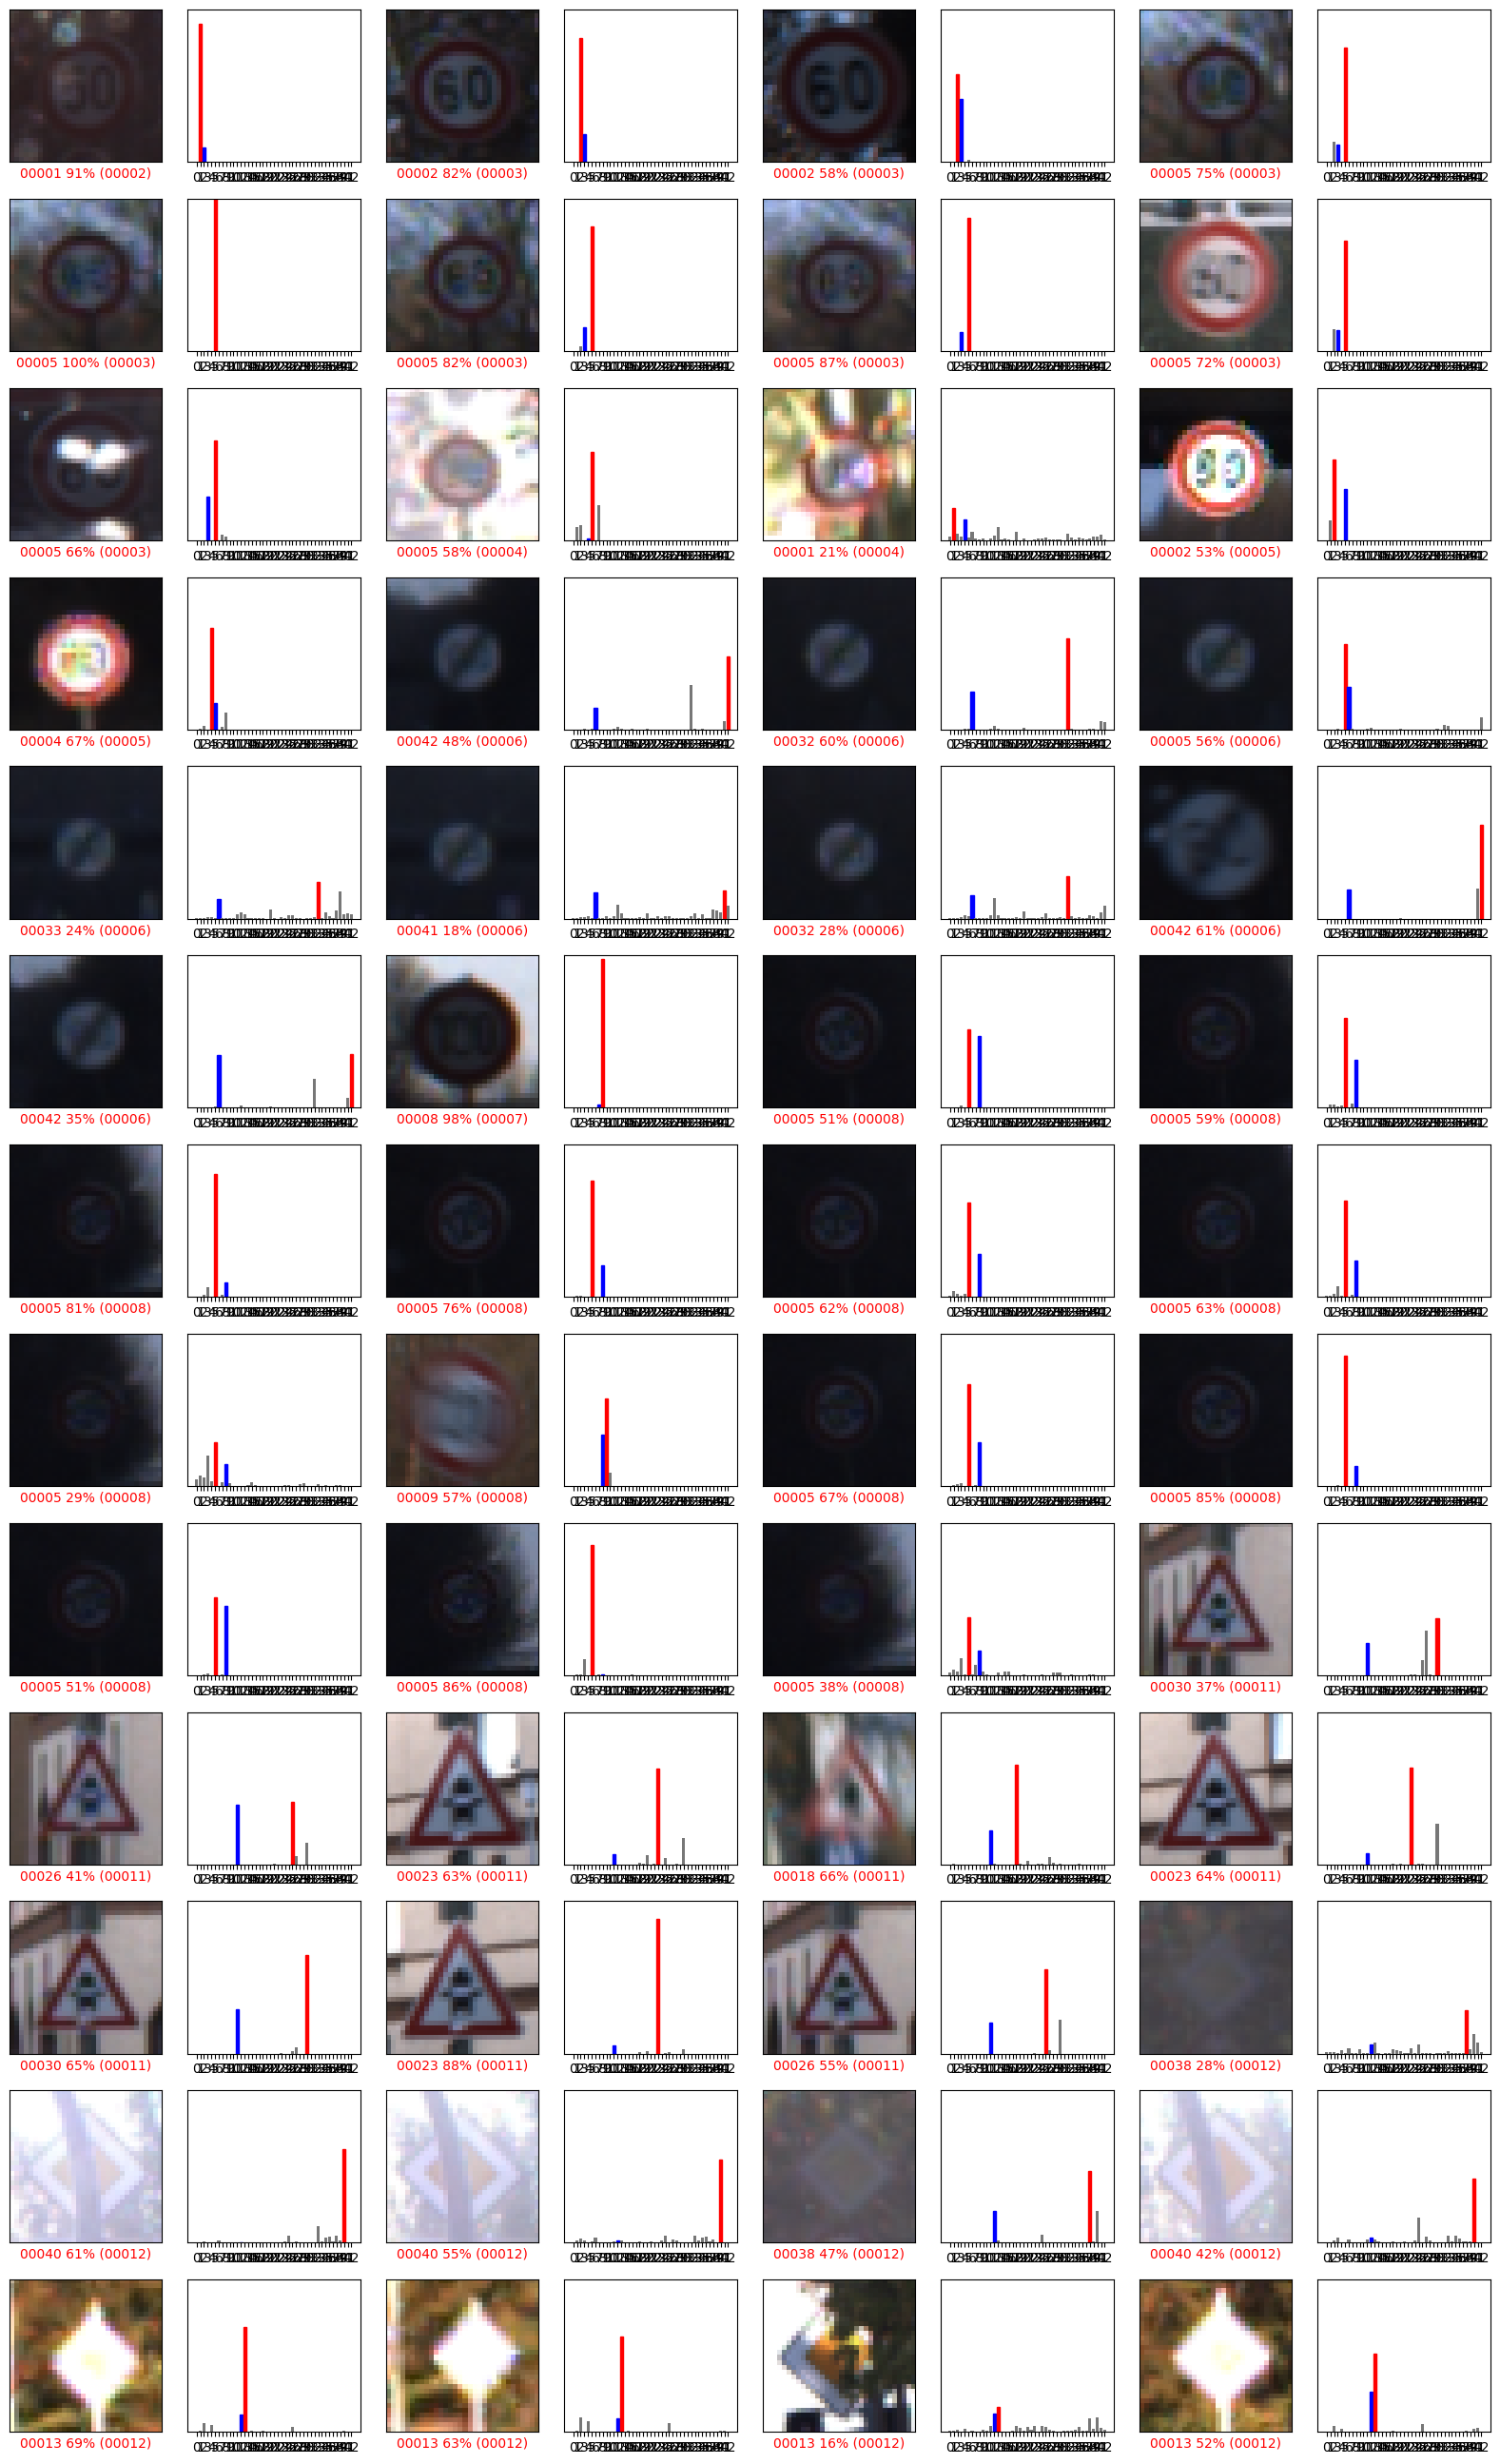

In [41]:
show_bad_preds(model_Conv, test_loader, test_set.classes)   

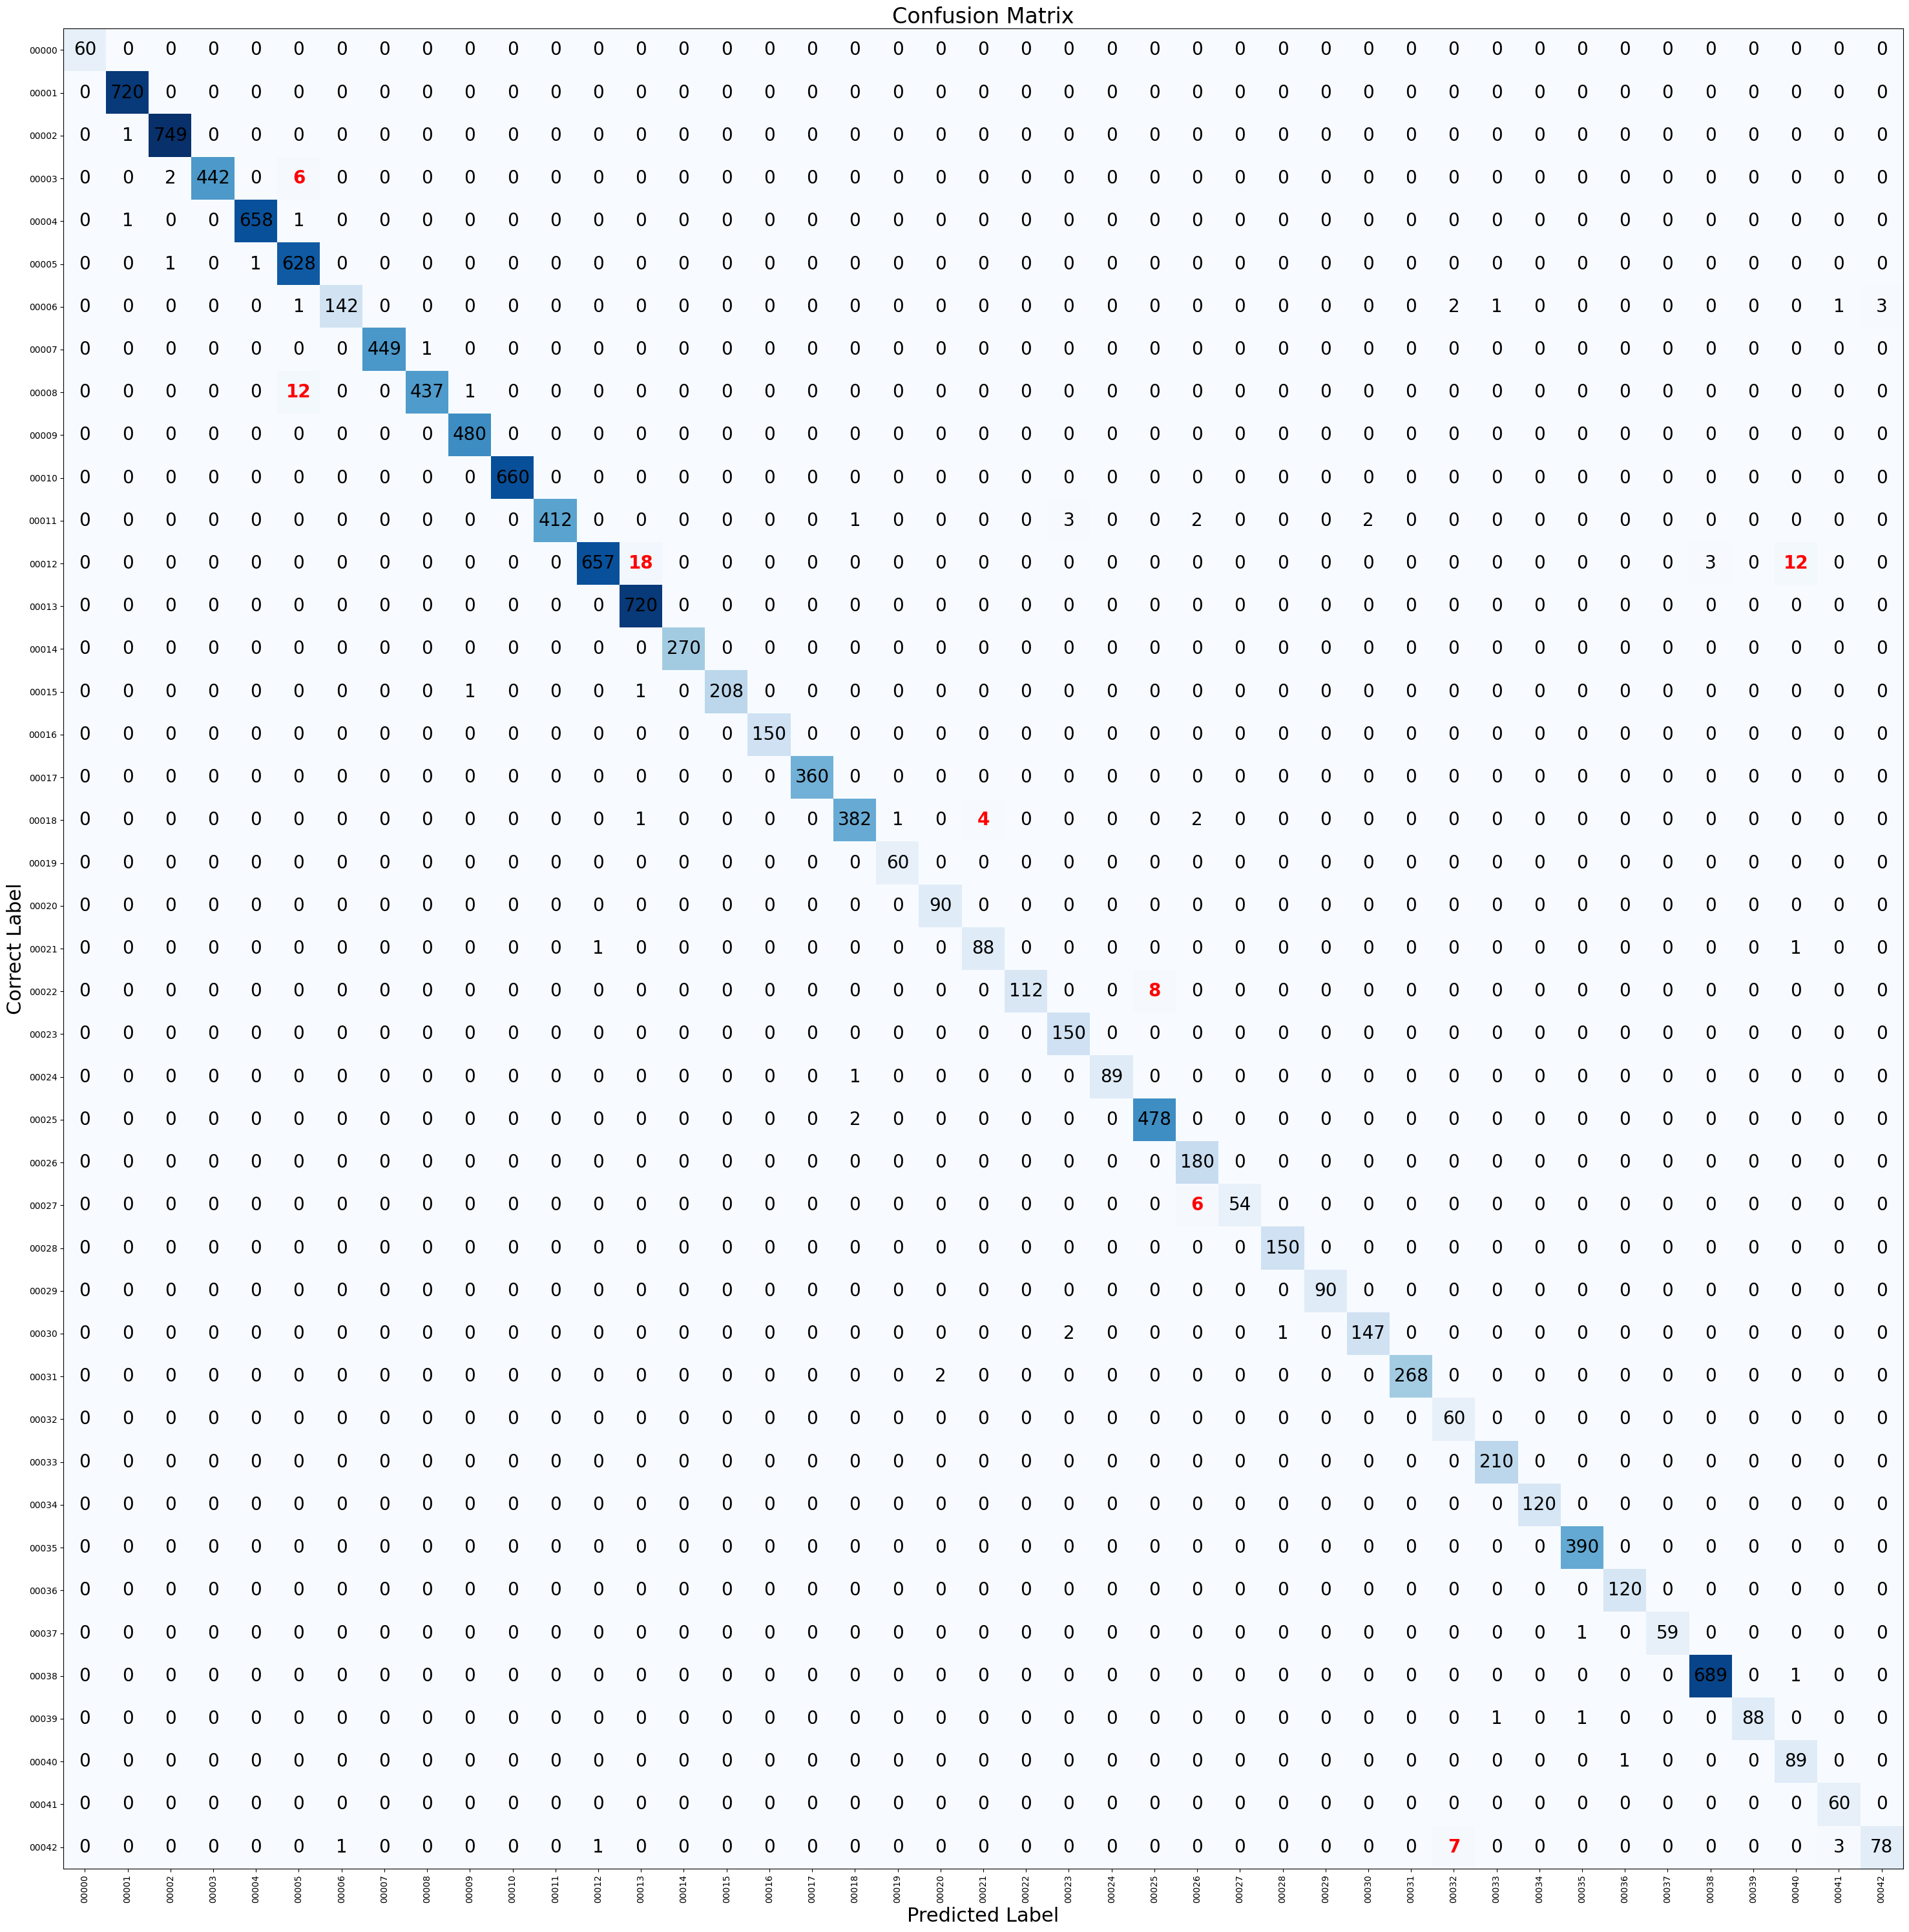

In [42]:
plot_confusion_matrix_highlight(model_Conv, test_loader, test_set.classes, threshold=3)

# __Static Augmentation - Random Affine__

In [43]:
AUG_PATH = f'{BASE_PATH}/train_augmented_randomAffine'

In [44]:
transform_aug = v2.Compose([

    v2.Resize((32, 32)),

    v2.RandomAffine(
        degrees=15,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1),
        shear=15,
        interpolation=v2.InterpolationMode.BILINEAR
    ),

    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

In [45]:
dataset_original = torchvision.datasets.ImageFolder(
    root=PATH_TRAINING_SET
)

classes = dataset_original.classes

os.makedirs(AUG_PATH, exist_ok=True)

N_AUGS = 3

In [46]:
for class_name in classes:

    original_class_path = os.path.join(
        PATH_TRAINING_SET,
        class_name
    )

    aug_class_path = os.path.join(
        AUG_PATH,
        class_name
    )

    os.makedirs(aug_class_path, exist_ok=True)

    image_names = [

        img_name

        for img_name in os.listdir(original_class_path)

        if img_name.lower().endswith((
            '.png',
            '.jpg',
            '.jpeg',
            '.ppm'
        ))
    ]

    for img_name in image_names:

        img_path = os.path.join(
            original_class_path,
            img_name
        )

        img = Image.open(img_path).convert('RGB')

        # SAVE ORIGINAL

        img_resized = img.resize((32, 32))

        img_resized.save(

            os.path.join(
                aug_class_path,
                f'orig_{img_name}'
            )
        )

        # SAVE AUGMENTATIONS

        for k in range(N_AUGS):

            aug_img = transform_aug(img)

            aug_img_pil = torchvision.transforms.ToPILImage()(aug_img)

            aug_img_pil.save(

                os.path.join(
                    aug_class_path,
                    f'augmented_{k}_{img_name}'
                )
            )

In [47]:
loss_fn = torch.nn.CrossEntropyLoss()

for i in range(RUNS):
    model_Conv_II = Conv_II(len(full_train_set.classes))
    model_Conv_II.to(device)

    early_stop = Early_Stopping(9)
    optimizer_II = torch.optim.Adam(model_Conv_II.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_II, mode='min', factor = 0.1, patience=3)    
    history_II = train_III(model_Conv_II, train_loader, val_loader, EPOCHS, loss_fn, optimizer_II, scheduler, early_stop, f'model_weights/static_randomAffine_aug_I_{i}')

Epoch: 000; Loss: 2.607205; Accuracy: 26.2710; Val Loss: 1.822952; Val Acc: 44.8939; Elapsed time: 37.3544
Epoch: 001; Loss: 1.518122; Accuracy: 53.0059; Val Loss: 0.733190; Val Acc: 79.1231; Elapsed time: 37.4560
Epoch: 002; Loss: 0.771587; Accuracy: 78.4253; Val Loss: 0.273046; Val Acc: 93.1683; Elapsed time: 38.2904
Epoch: 003; Loss: 0.409776; Accuracy: 89.3230; Val Loss: 0.090960; Val Acc: 99.0382; Elapsed time: 37.9940
Epoch: 004; Loss: 0.271163; Accuracy: 93.2130; Val Loss: 0.047229; Val Acc: 99.2504; Elapsed time: 38.8724
Epoch: 005; Loss: 0.199068; Accuracy: 94.9529; Val Loss: 0.029628; Val Acc: 99.3352; Elapsed time: 30.2826
Epoch: 006; Loss: 0.170263; Accuracy: 95.5385; Val Loss: 0.019872; Val Acc: 99.8161; Elapsed time: 33.7012
Epoch: 007; Loss: 0.148993; Accuracy: 95.9742; Val Loss: 0.015122; Val Acc: 99.8727; Elapsed time: 35.4030
Epoch: 008; Loss: 0.127062; Accuracy: 96.6843; Val Loss: 0.012768; Val Acc: 99.8444; Elapsed time: 34.9239
Epoch: 009; Loss: 0.113917; Accuracy:

In [48]:
# =========================================================
# TEST RESULTS
# =========================================================

res = 0

model_Conv = Conv_II(len(train_set.classes))
model_Conv.to(device)

print('\n========== STATIC RANDOM AFFINE RESULTS ==========')

for i in range(RUNS):

    # -----------------------------------------------------
    # Load best checkpoint
    # -----------------------------------------------------

    checkpoint = torch.load(
        f'model_weights/static_randomAffine_aug_I_{i}.pt'
    )

    model_Conv.load_state_dict(checkpoint['model'])

    # -----------------------------------------------------
    # Metrics
    # -----------------------------------------------------

    best_epoch = checkpoint['epoch']

    test_acc = evaluate(model_Conv, test_loader) * 100
    eval_acc = evaluate(model_Conv, val_loader) * 100

    # -----------------------------------------------------
    # Print run results
    # -----------------------------------------------------

    print(f'\nRUN {i + 1}')

    print(f'Best Epoch    : {best_epoch}')
    print(f'Eval Accuracy : {eval_acc:.2f}%')
    print(f'Test Accuracy : {test_acc:.2f}%')

    # -----------------------------------------------------
    # Mean test accuracy
    # -----------------------------------------------------

    res += test_acc

# =========================================================
# FINAL MEAN
# =========================================================

res /= RUNS

print('\n========== FINAL MEAN TEST ACCURACY ==========')
print(f'Mean Test Accuracy : {res:.2f}%')

static_randomAffine_acc = res


========== STATIC RANDOM AFFINE RESULTS ==========

RUN 1
Best Epoch    : 28
Eval Accuracy : 100.00%
Test Accuracy : 99.21%

RUN 2
Best Epoch    : 26
Eval Accuracy : 99.99%
Test Accuracy : 98.77%

RUN 3
Best Epoch    : 29
Eval Accuracy : 100.00%
Test Accuracy : 99.25%

========== FINAL MEAN TEST ACCURACY ==========
Mean Test Accuracy : 99.08%


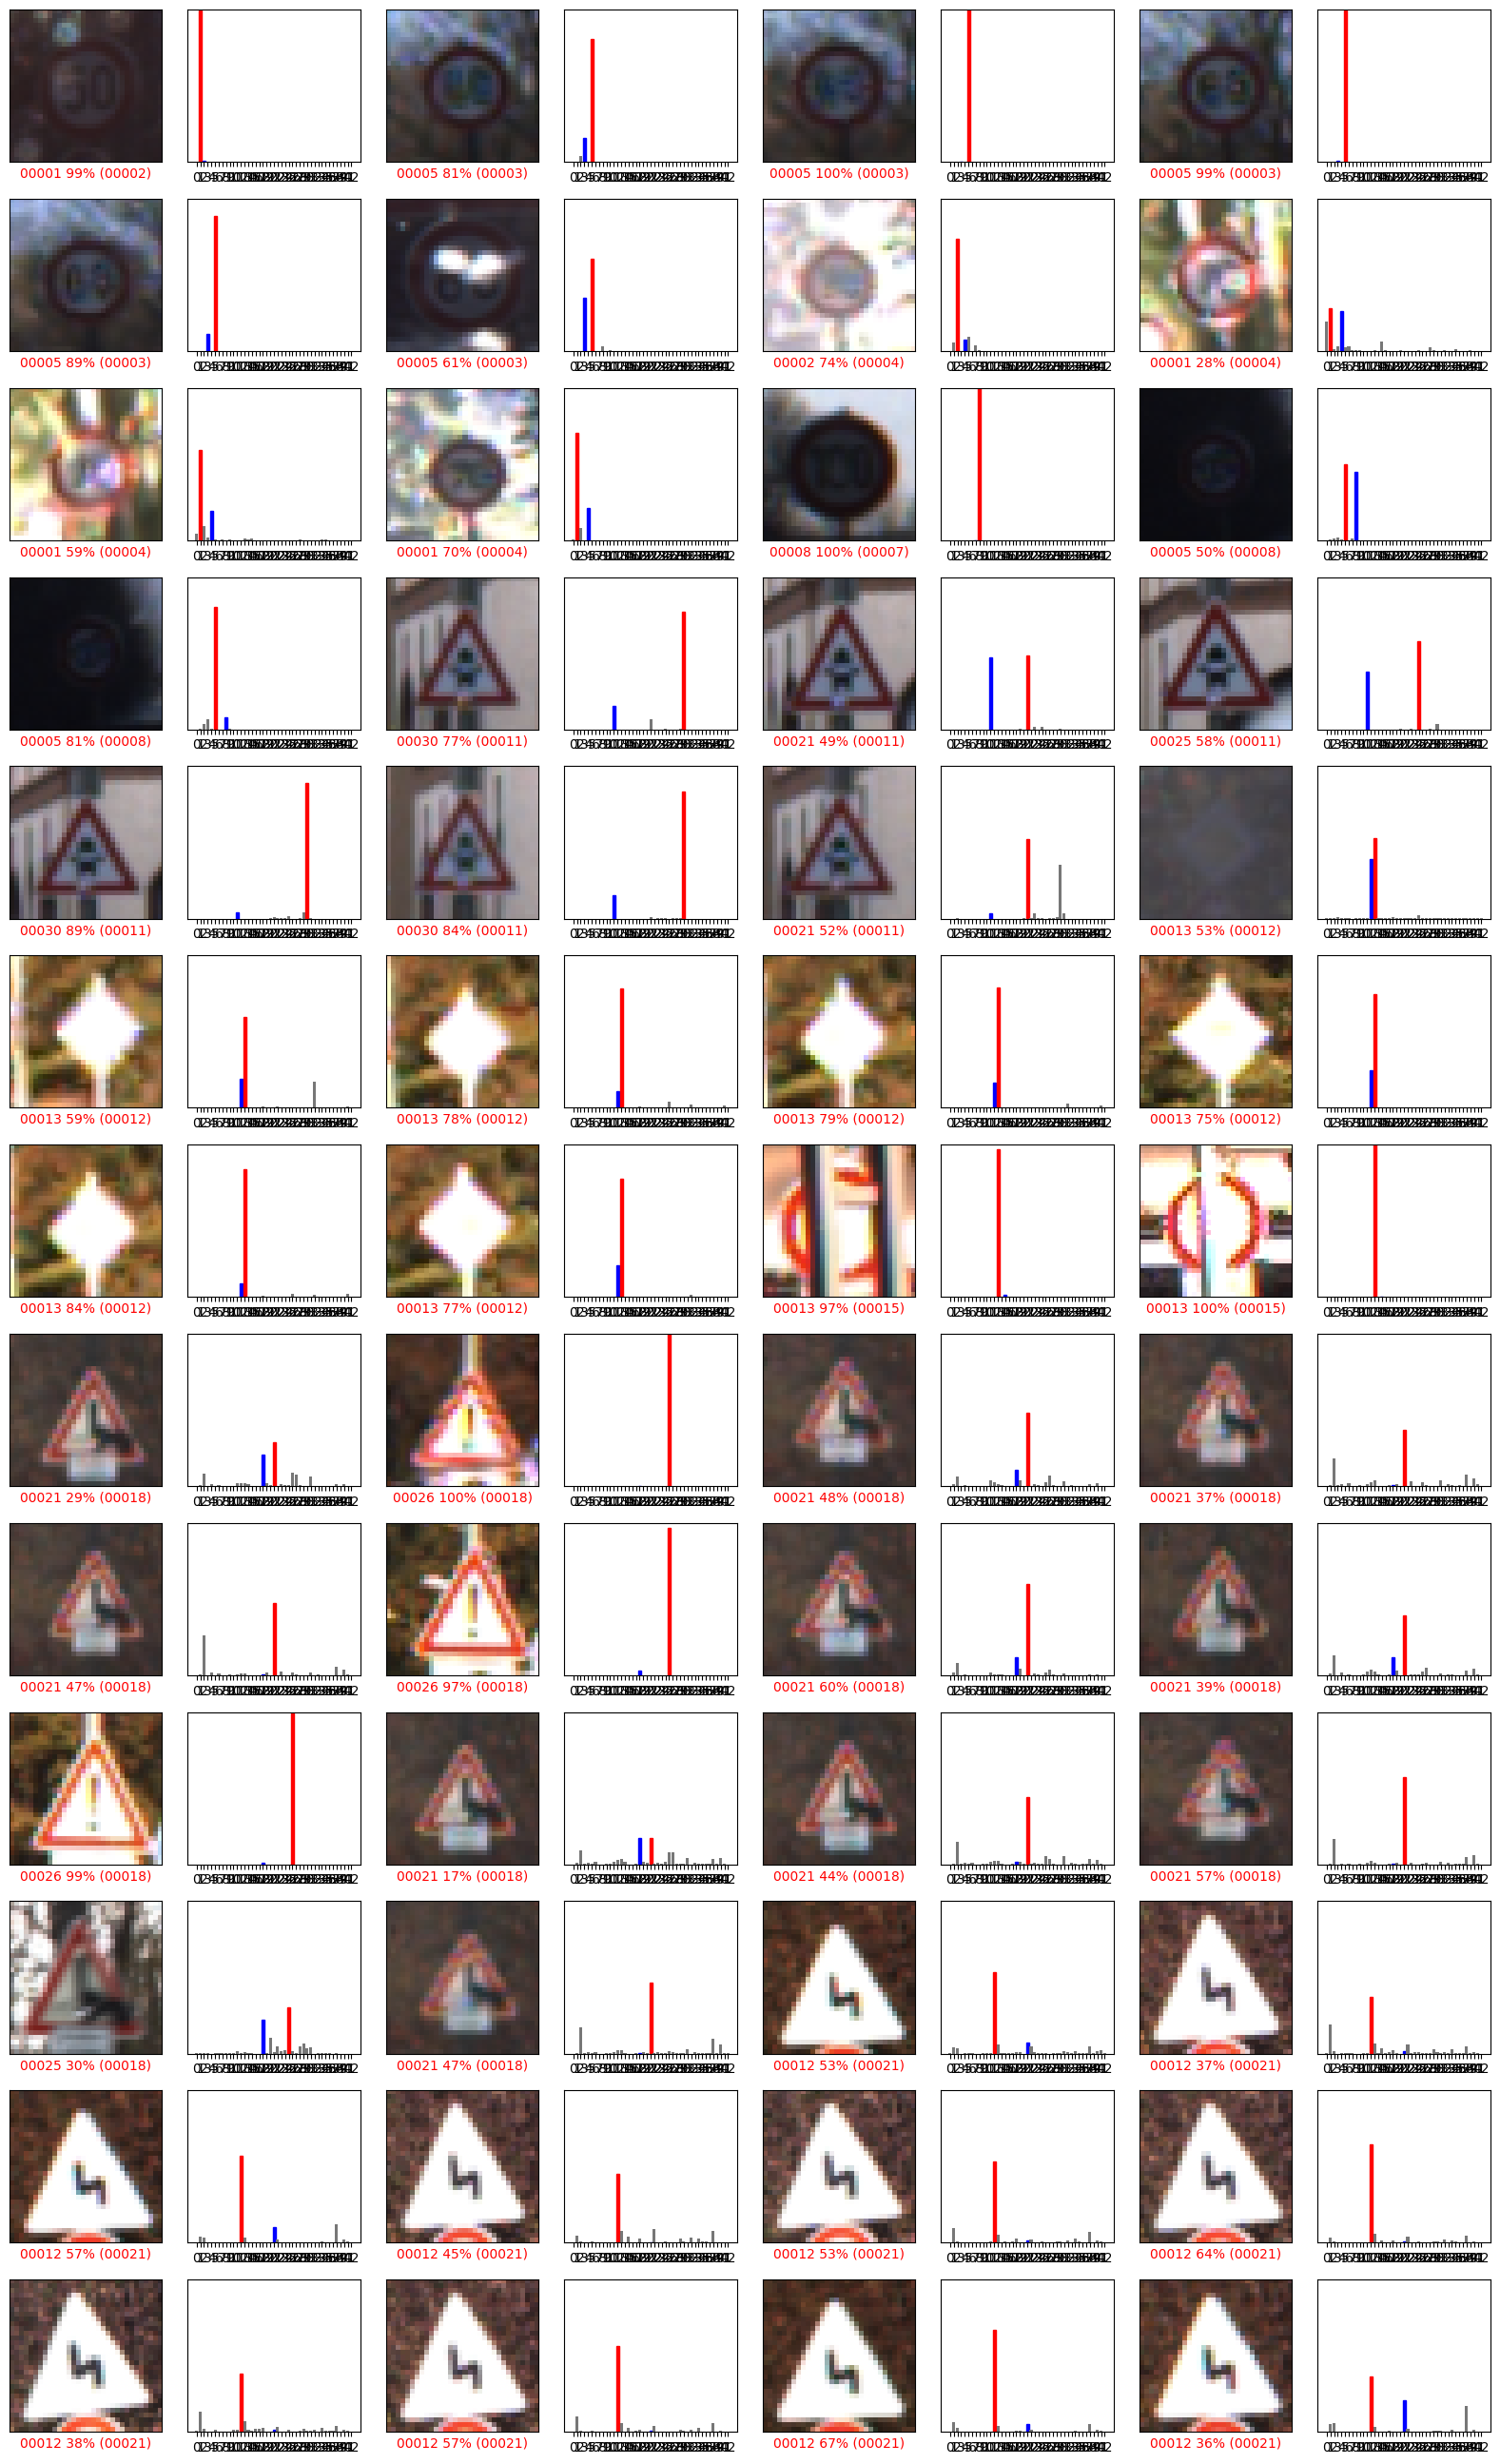

In [49]:
show_bad_preds(model_Conv, test_loader, test_set.classes)   

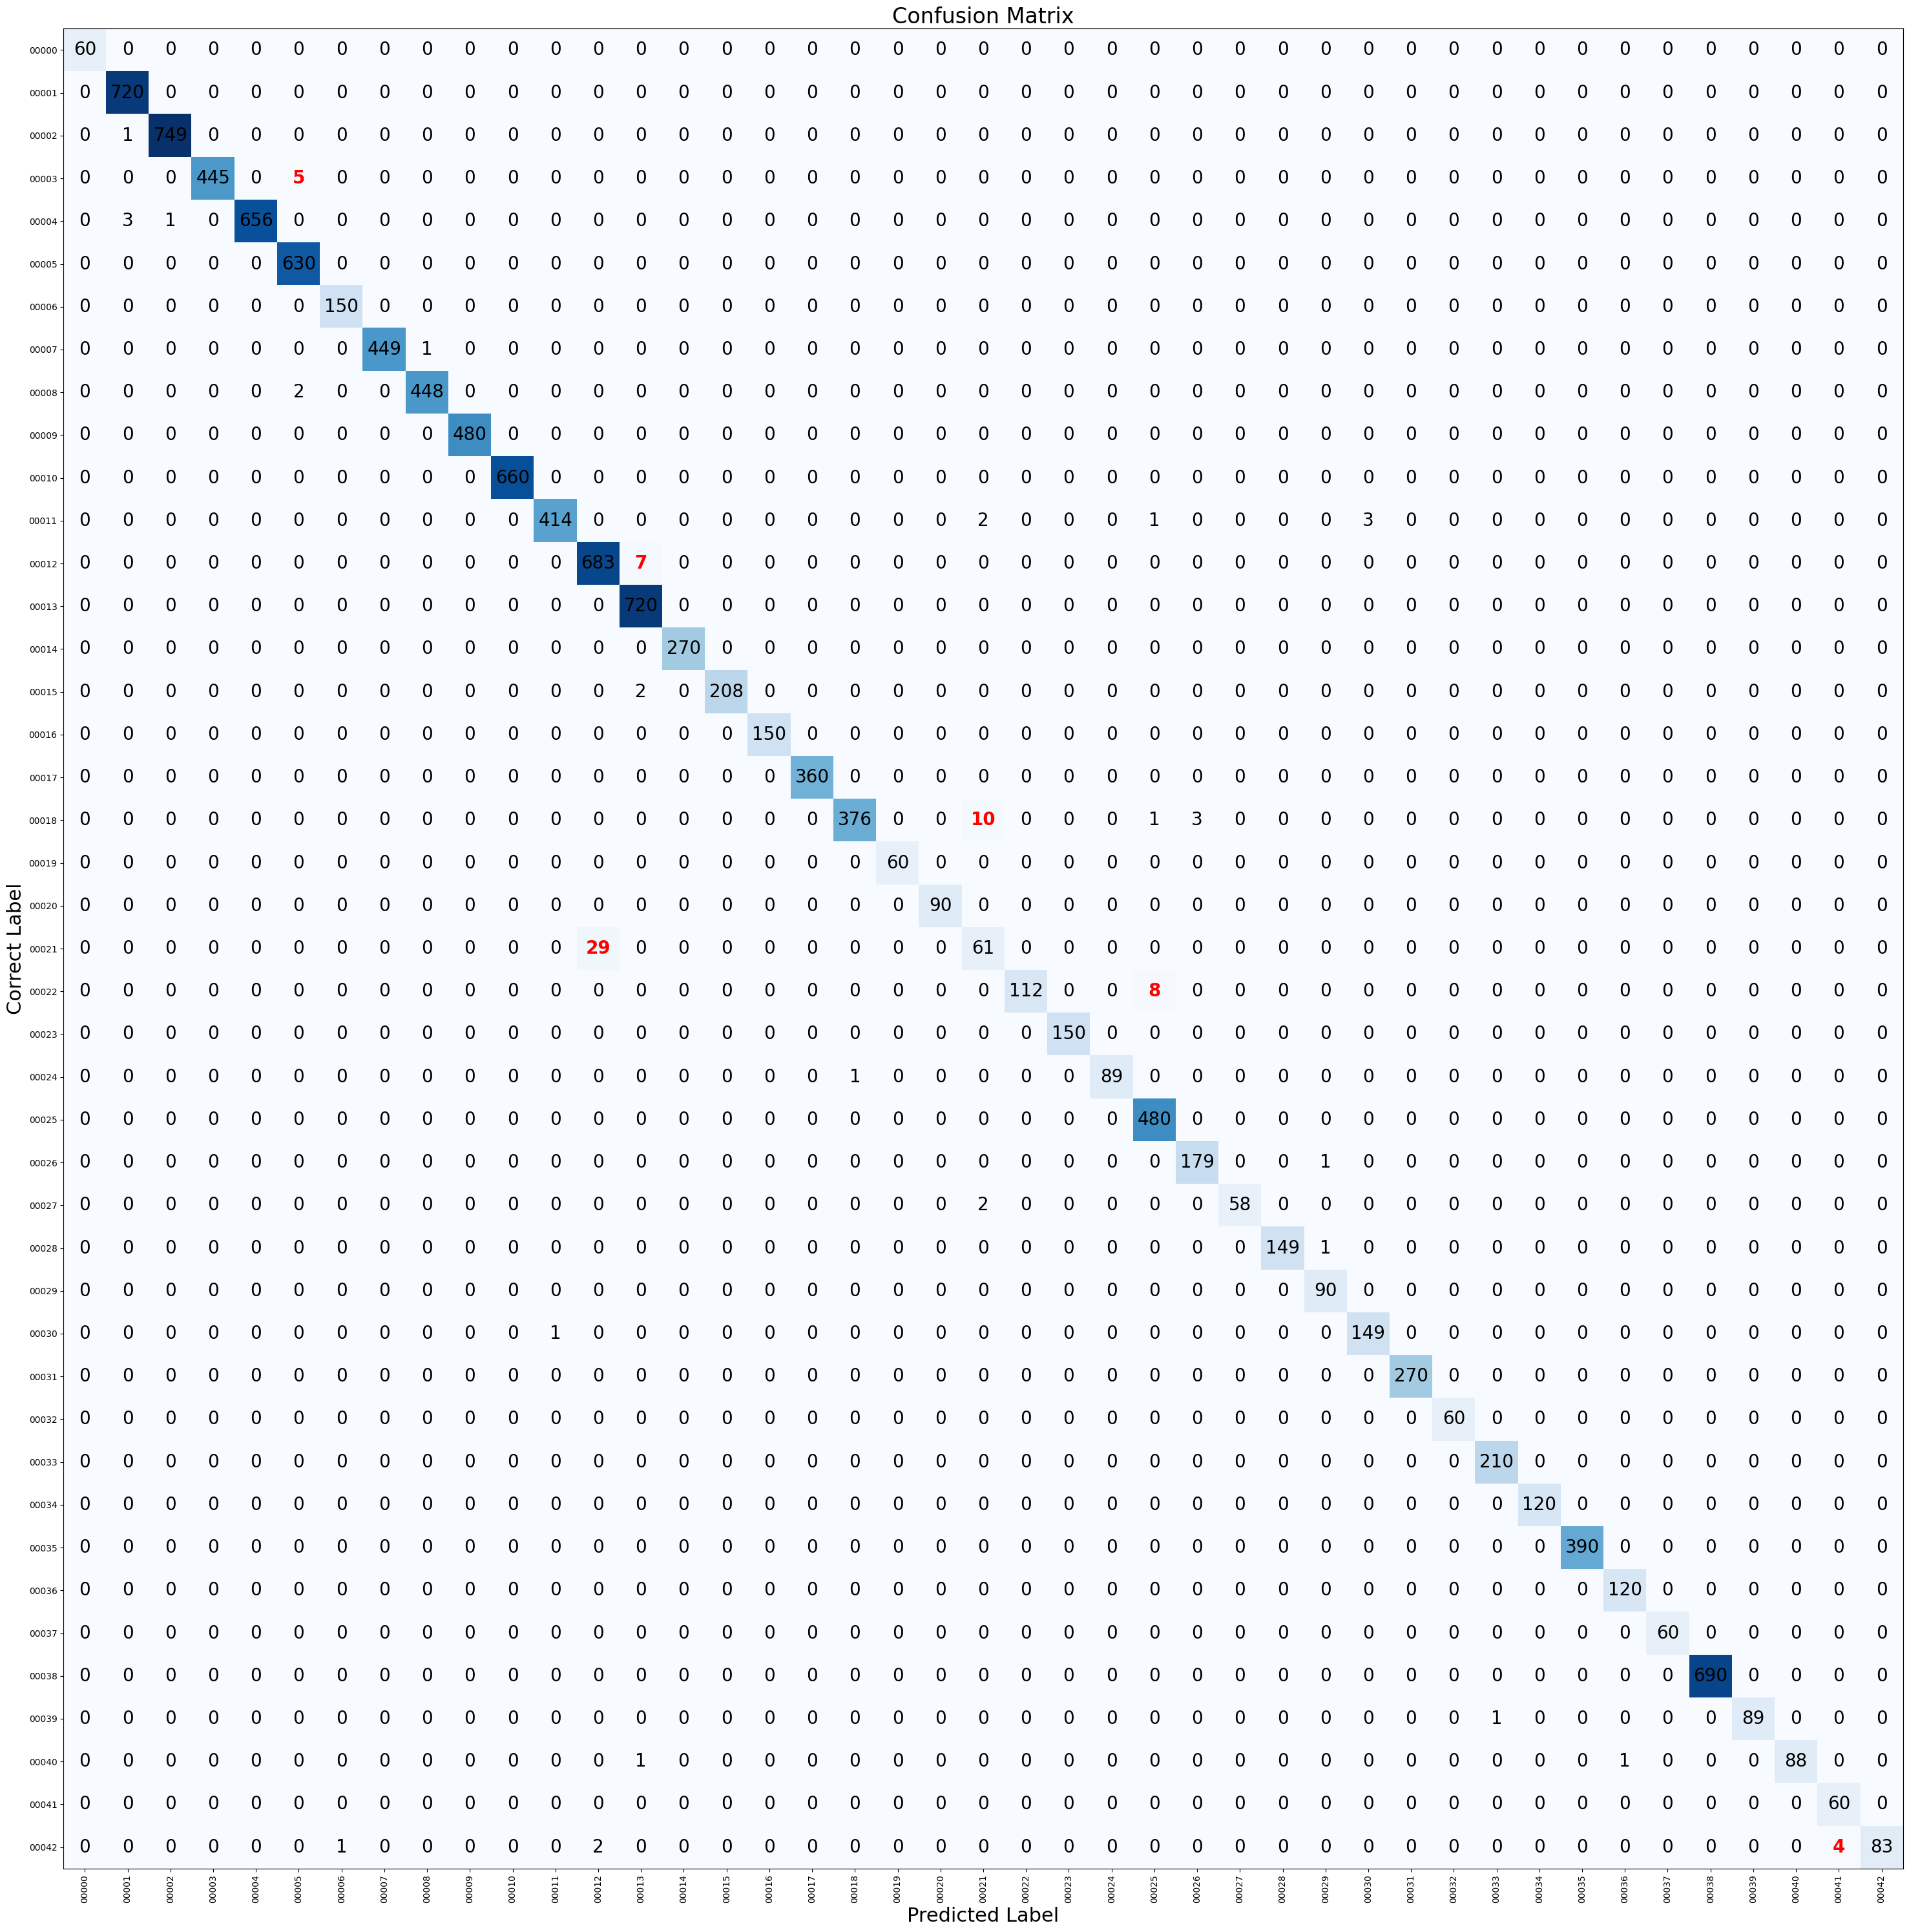

In [50]:
plot_confusion_matrix_highlight(model_Conv, test_loader, test_set.classes, threshold=3)

# __Static Augmentation - Gaussian Blur__

In [51]:
AUG_PATH = f'{BASE_PATH}/train_augmented_gaussianBlur'

In [52]:
transform_aug = v2.Compose([

    v2.Resize((32, 32)),

    v2.GaussianBlur(
        kernel_size=3,
        sigma=(0.1, 1.0)
    ),

    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

In [53]:
dataset_original = torchvision.datasets.ImageFolder(
    root=PATH_TRAINING_SET
)

classes = dataset_original.classes

os.makedirs(AUG_PATH, exist_ok=True)

N_AUGS = 3

In [54]:
for class_name in classes:

    original_class_path = os.path.join(
        PATH_TRAINING_SET,
        class_name
    )

    aug_class_path = os.path.join(
        AUG_PATH,
        class_name
    )

    os.makedirs(aug_class_path, exist_ok=True)

    image_names = [

        img_name

        for img_name in os.listdir(original_class_path)

        if img_name.lower().endswith((
            '.png',
            '.jpg',
            '.jpeg',
            '.ppm'
        ))
    ]

    for img_name in image_names:

        img_path = os.path.join(
            original_class_path,
            img_name
        )

        img = Image.open(img_path).convert('RGB')

        # SAVE ORIGINAL

        img_resized = img.resize((32, 32))

        img_resized.save(

            os.path.join(
                aug_class_path,
                f'orig_{img_name}'
            )
        )

        # SAVE AUGMENTATIONS

        for k in range(N_AUGS):

            aug_img = transform_aug(img)

            aug_img_pil = torchvision.transforms.ToPILImage()(aug_img)

            aug_img_pil.save(

                os.path.join(
                    aug_class_path,
                    f'augmented_{k}_{img_name}'
                )
            )

In [55]:
loss_fn = torch.nn.CrossEntropyLoss()

for i in range(RUNS):
    model_Conv_II = Conv_II(len(full_train_set.classes))
    model_Conv_II.to(device)

    early_stop = Early_Stopping(9)
    optimizer_II = torch.optim.Adam(model_Conv_II.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_II, mode='min', factor = 0.1, patience=3)    
    history_II = train_III(model_Conv_II, train_loader, val_loader, EPOCHS, loss_fn, optimizer_II, scheduler, early_stop, f'model_weights/static_gaussianBlur_aug_I_{i}')

Epoch: 000; Loss: 2.617051; Accuracy: 25.5524; Val Loss: 1.810842; Val Acc: 41.1740; Elapsed time: 42.7278
Epoch: 001; Loss: 1.496838; Accuracy: 54.2479; Val Loss: 0.821966; Val Acc: 74.3564; Elapsed time: 41.3166
Epoch: 002; Loss: 0.772470; Accuracy: 78.3546; Val Loss: 0.225611; Val Acc: 95.9547; Elapsed time: 38.3567
Epoch: 003; Loss: 0.415952; Accuracy: 89.2410; Val Loss: 0.080527; Val Acc: 99.1372; Elapsed time: 35.5573
Epoch: 004; Loss: 0.273727; Accuracy: 93.0942; Val Loss: 0.033810; Val Acc: 99.5757; Elapsed time: 35.7418
Epoch: 005; Loss: 0.206318; Accuracy: 94.7831; Val Loss: 0.041600; Val Acc: 99.4484; Elapsed time: 35.3893
Epoch: 006; Loss: 0.173110; Accuracy: 95.5074; Val Loss: 0.021747; Val Acc: 99.7171; Elapsed time: 35.5389
Epoch: 007; Loss: 0.152550; Accuracy: 95.9714; Val Loss: 0.014104; Val Acc: 99.8444; Elapsed time: 35.7523
Epoch: 008; Loss: 0.129990; Accuracy: 96.5400; Val Loss: 0.019499; Val Acc: 99.7737; Elapsed time: 35.4139
Epoch: 009; Loss: 0.123938; Accuracy:

In [56]:
# =========================================================
# TEST RESULTS
# =========================================================

res = 0

model_Conv = Conv_II(len(train_set.classes))
model_Conv.to(device)

print('\n========== STATIC GAUSSIAN BLUR RESULTS ==========')

for i in range(RUNS):

    # -----------------------------------------------------
    # Load best checkpoint
    # -----------------------------------------------------

    checkpoint = torch.load(
        f'model_weights/static_gaussianBlur_aug_I_{i}.pt'
    )

    model_Conv.load_state_dict(checkpoint['model'])

    # -----------------------------------------------------
    # Metrics
    # -----------------------------------------------------

    best_epoch = checkpoint['epoch']

    test_acc = evaluate(model_Conv, test_loader) * 100
    eval_acc = evaluate(model_Conv, val_loader) * 100

    # -----------------------------------------------------
    # Print run results
    # -----------------------------------------------------

    print(f'\nRUN {i + 1}')

    print(f'Best Epoch    : {best_epoch}')
    print(f'Eval Accuracy : {eval_acc:.2f}%')
    print(f'Test Accuracy : {test_acc:.2f}%')

    # -----------------------------------------------------
    # Mean test accuracy
    # -----------------------------------------------------

    res += test_acc

# =========================================================
# FINAL MEAN
# =========================================================

res /= RUNS

print('\n========== FINAL MEAN TEST ACCURACY ==========')
print(f'Mean Test Accuracy : {res:.2f}%')

static_gaussianBlur_acc = res


========== STATIC GAUSSIAN BLUR RESULTS ==========

RUN 1
Best Epoch    : 27
Eval Accuracy : 100.00%
Test Accuracy : 99.26%

RUN 2
Best Epoch    : 28
Eval Accuracy : 100.00%
Test Accuracy : 99.25%

RUN 3
Best Epoch    : 26
Eval Accuracy : 100.00%
Test Accuracy : 99.27%

========== FINAL MEAN TEST ACCURACY ==========
Mean Test Accuracy : 99.26%


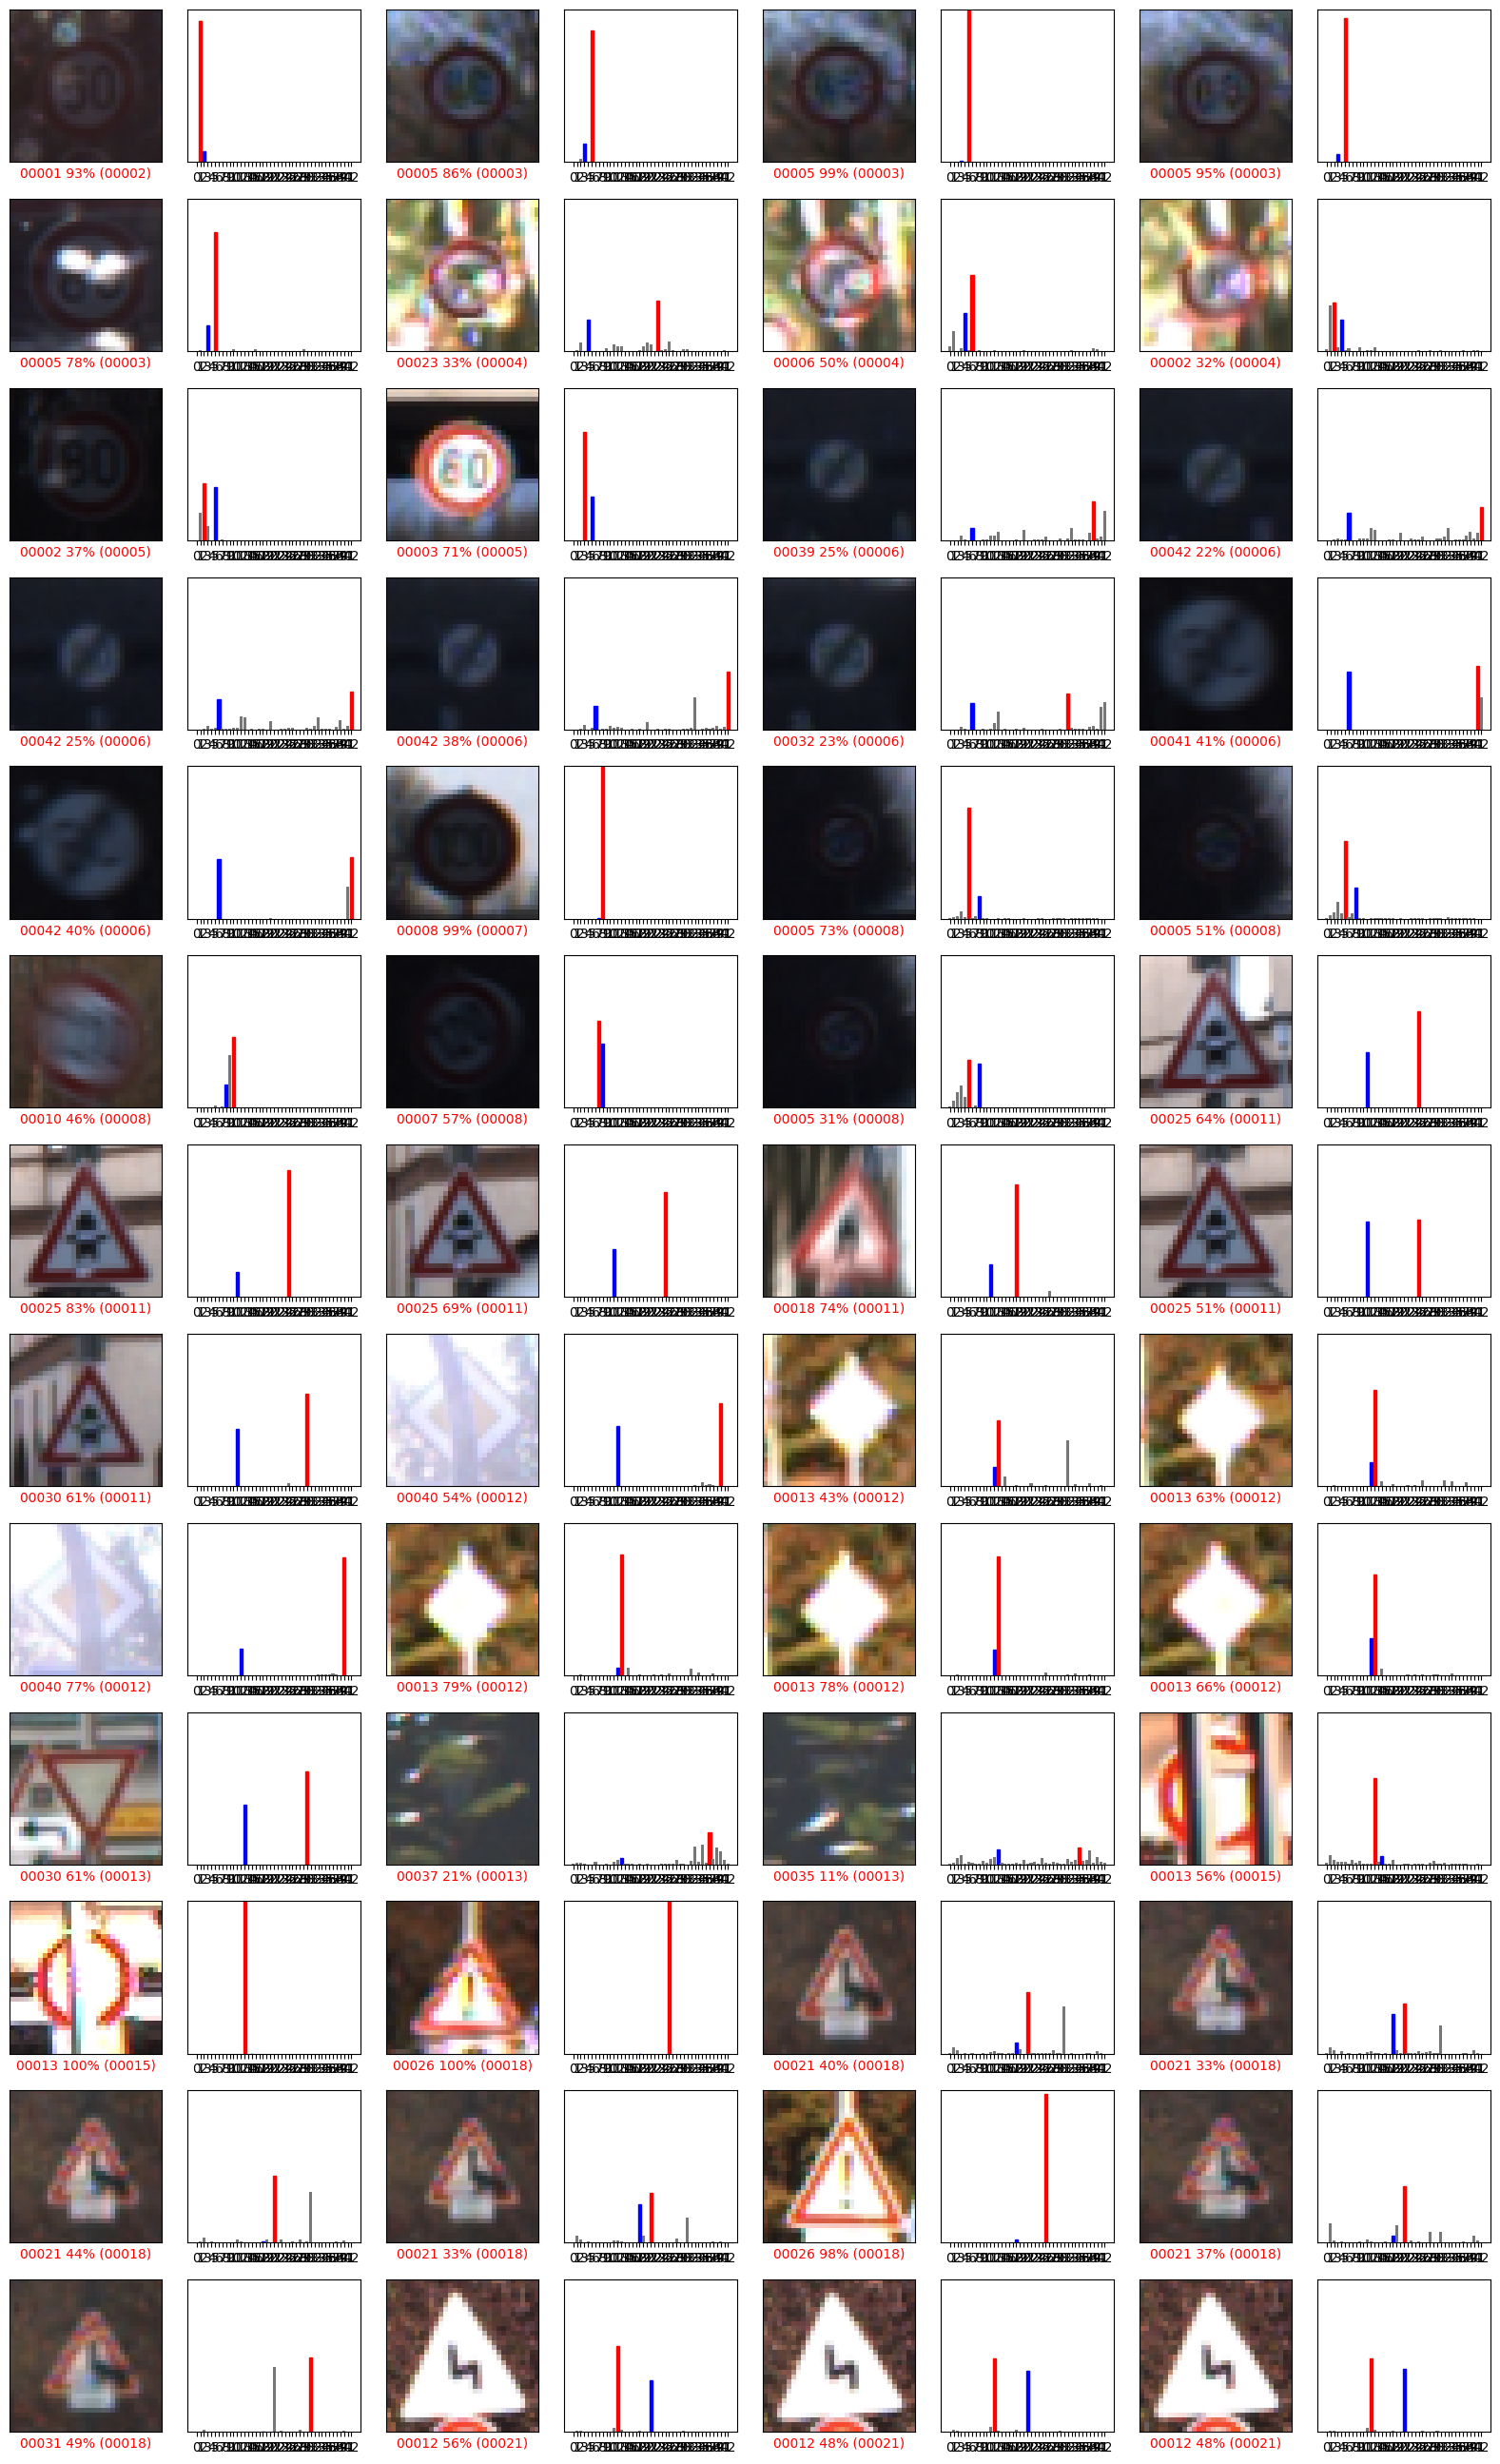

In [57]:
show_bad_preds(model_Conv, test_loader, test_set.classes)   

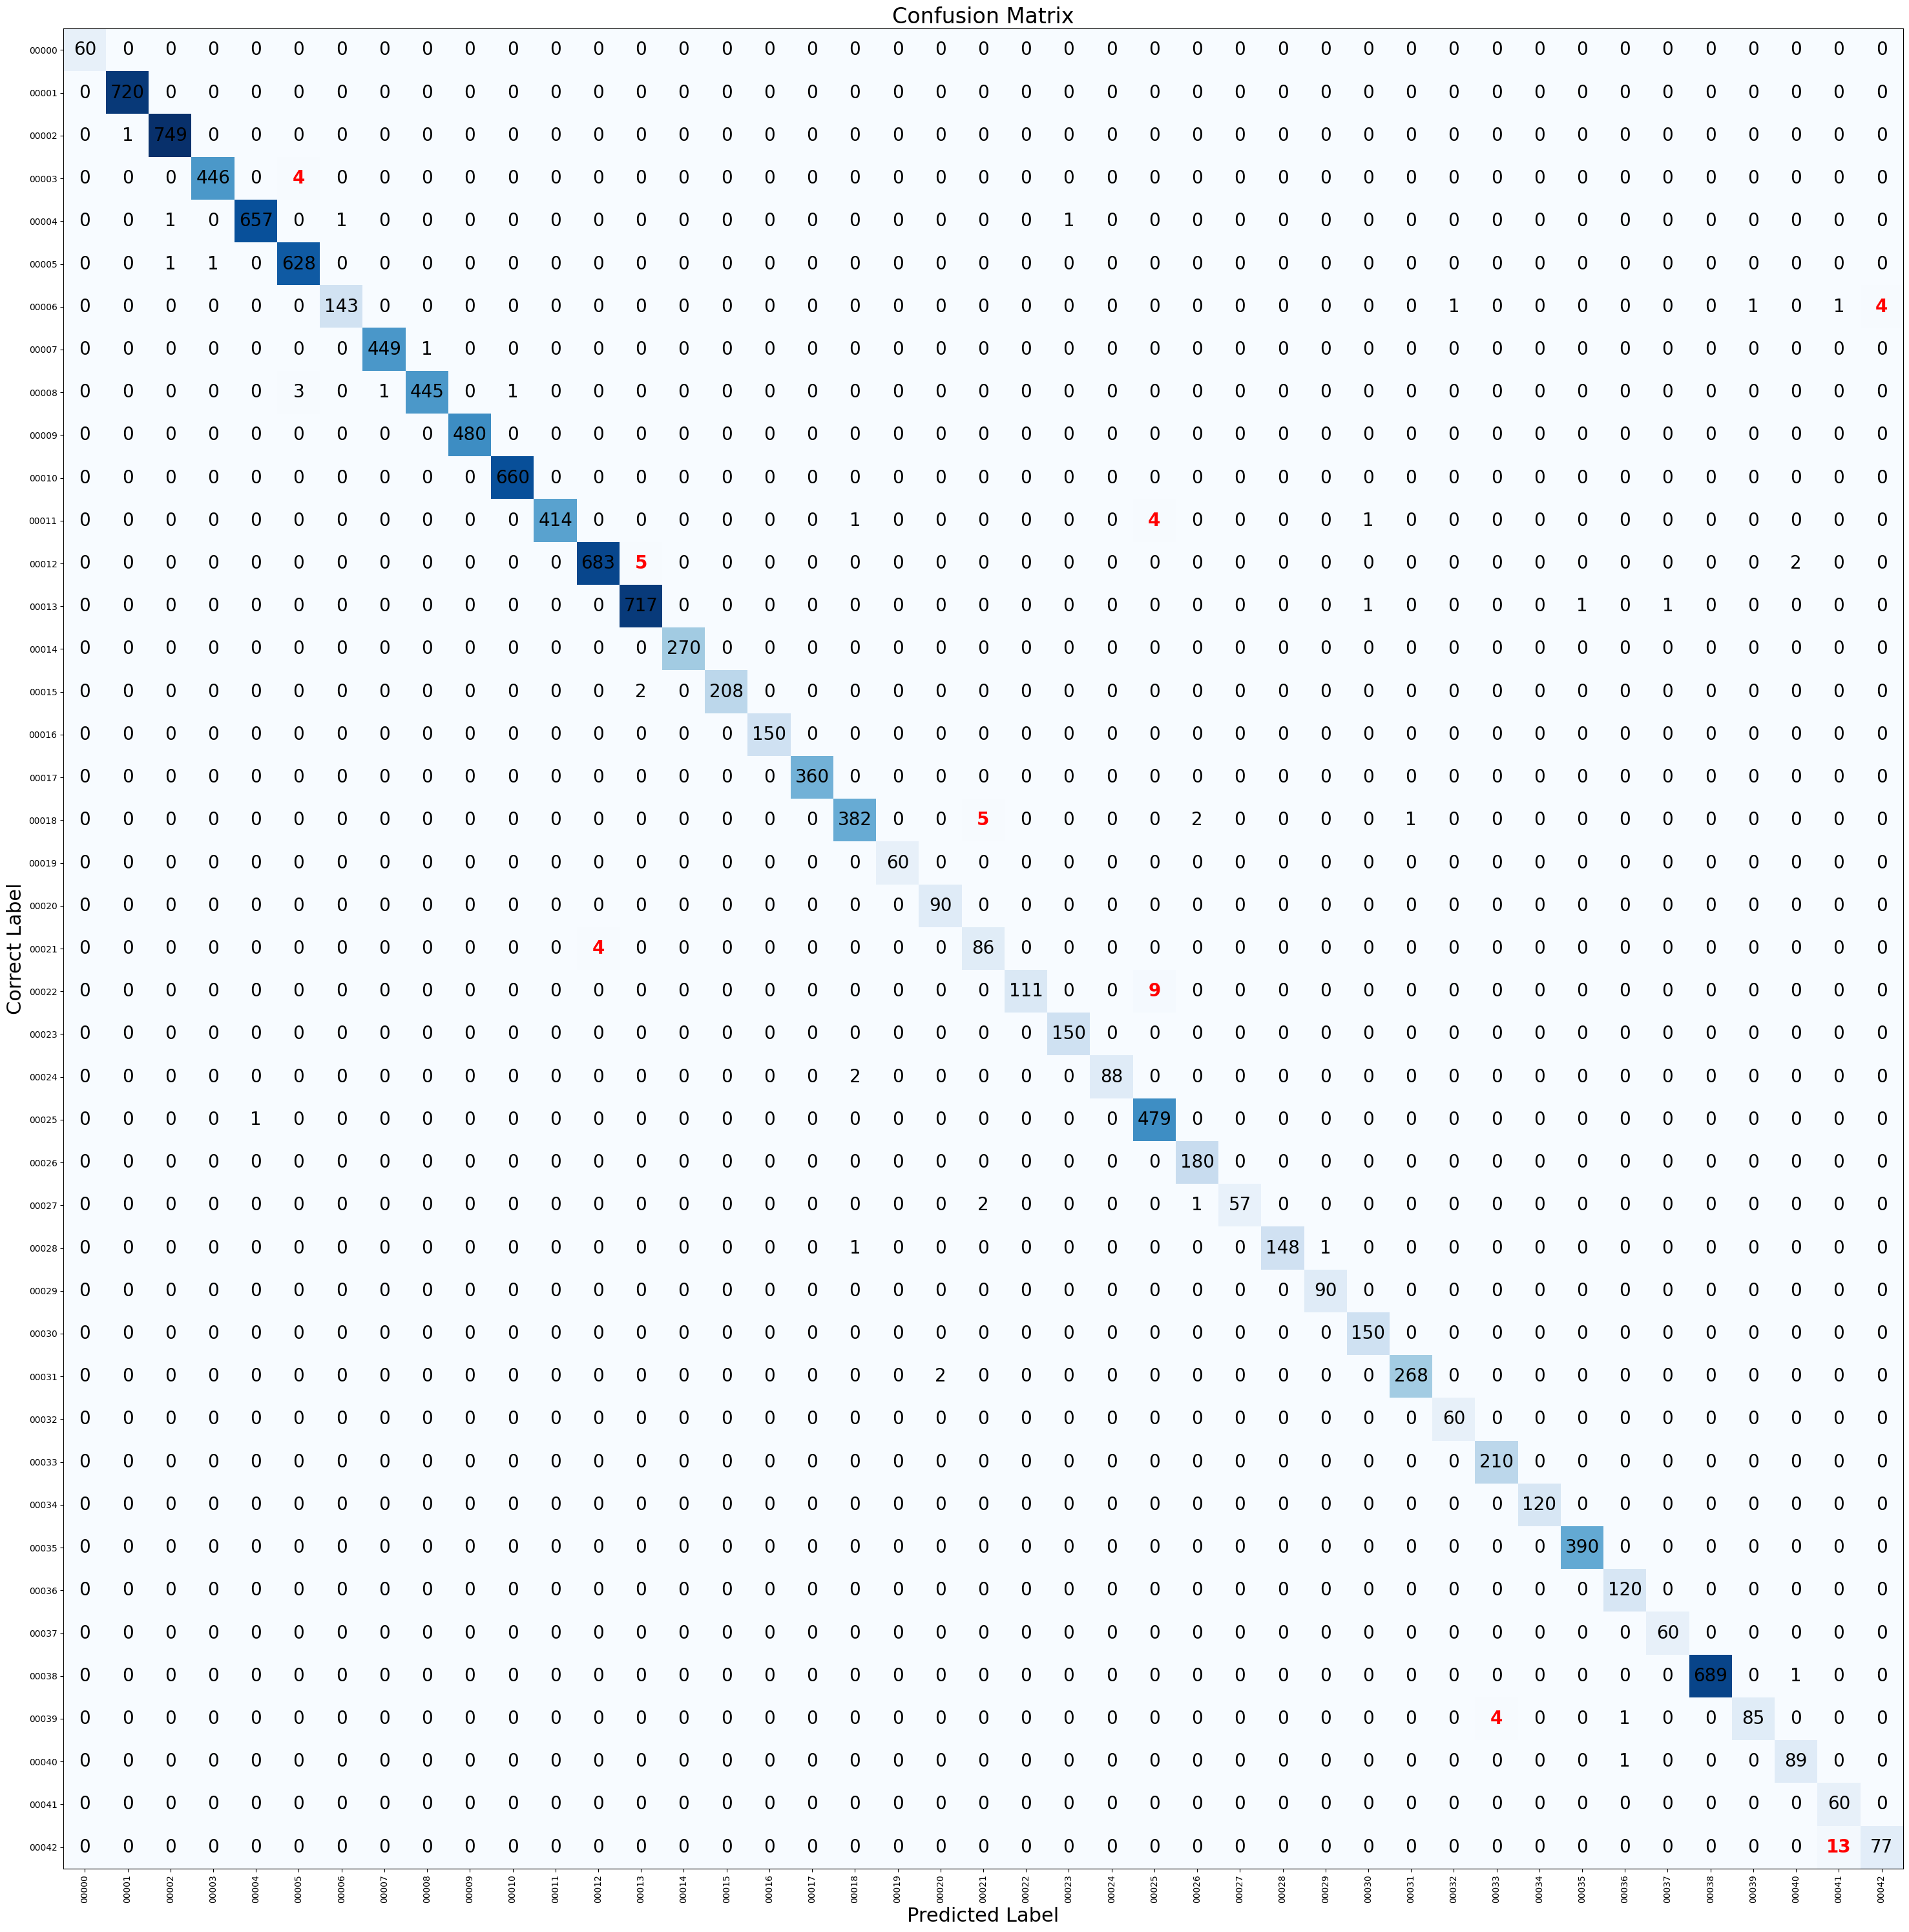

In [58]:
plot_confusion_matrix_highlight(model_Conv, test_loader, test_set.classes, threshold=3)

# __Static Augmentation - Random Erasing__

In [59]:
AUG_PATH = f'{BASE_PATH}/train_augmented_randomErasing'

In [60]:
transform_aug = v2.Compose([
    v2.Resize((32, 32)),

    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),

    v2.RandomErasing(
        p=0.5,
        scale=(0.02, 0.08),
        ratio=(0.3, 3.3),
        value='random'
    )
])

In [61]:
dataset_original = torchvision.datasets.ImageFolder(
    root=PATH_TRAINING_SET
)

classes = dataset_original.classes

os.makedirs(AUG_PATH, exist_ok=True)

N_AUGS = 3

In [62]:
for class_name in classes:

    original_class_path = os.path.join(
        PATH_TRAINING_SET,
        class_name
    )

    aug_class_path = os.path.join(
        AUG_PATH,
        class_name
    )

    os.makedirs(aug_class_path, exist_ok=True)

    image_names = [

        img_name

        for img_name in os.listdir(original_class_path)

        if img_name.lower().endswith((
            '.png',
            '.jpg',
            '.jpeg',
            '.ppm'
        ))
    ]

    for img_name in image_names:

        img_path = os.path.join(
            original_class_path,
            img_name
        )

        img = Image.open(img_path).convert('RGB')

        # SAVE ORIGINAL

        img_resized = img.resize((32, 32))

        img_resized.save(

            os.path.join(
                aug_class_path,
                f'orig_{img_name}'
            )
        )

        # SAVE AUGMENTATIONS

        for k in range(N_AUGS):

            aug_img = transform_aug(img)

            aug_img_pil = torchvision.transforms.ToPILImage()(aug_img)

            aug_img_pil.save(

                os.path.join(
                    aug_class_path,
                    f'augmented_{k}_{img_name}'
                )
            )

In [63]:
loss_fn = torch.nn.CrossEntropyLoss()

for i in range(RUNS):
    model_Conv_II = Conv_II(len(full_train_set.classes))
    model_Conv_II.to(device)

    early_stop = Early_Stopping(9)
    optimizer_II = torch.optim.Adam(model_Conv_II.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_II, mode='min', factor = 0.1, patience=3)    
    history_II = train_III(model_Conv_II, train_loader, val_loader, EPOCHS, loss_fn, optimizer_II, scheduler, early_stop, f'model_weights/static_randomErasing_aug_I_{i}')

Epoch: 000; Loss: 2.682200; Accuracy: 24.3415; Val Loss: 1.828761; Val Acc: 43.7199; Elapsed time: 37.4680
Epoch: 001; Loss: 1.625737; Accuracy: 49.6987; Val Loss: 1.035078; Val Acc: 71.1740; Elapsed time: 36.4334
Epoch: 002; Loss: 0.876781; Accuracy: 74.6315; Val Loss: 0.530571; Val Acc: 86.3932; Elapsed time: 37.3982
Epoch: 003; Loss: 0.454967; Accuracy: 88.2055; Val Loss: 0.104691; Val Acc: 98.6987; Elapsed time: 35.7805
Epoch: 004; Loss: 0.297052; Accuracy: 92.4152; Val Loss: 0.138375; Val Acc: 98.7129; Elapsed time: 35.3559
Epoch: 005; Loss: 0.224167; Accuracy: 94.2032; Val Loss: 0.028831; Val Acc: 99.5332; Elapsed time: 35.4118
Epoch: 006; Loss: 0.176542; Accuracy: 95.5413; Val Loss: 0.029102; Val Acc: 99.4059; Elapsed time: 35.1675
Epoch: 007; Loss: 0.153272; Accuracy: 95.9742; Val Loss: 0.017824; Val Acc: 99.6181; Elapsed time: 35.2127
Epoch: 008; Loss: 0.134882; Accuracy: 96.4353; Val Loss: 0.015107; Val Acc: 99.6605; Elapsed time: 35.1511
Epoch: 009; Loss: 0.121709; Accuracy:

In [64]:
# =========================================================
# TEST RESULTS
# =========================================================

res = 0

model_Conv = Conv_II(len(train_set.classes))
model_Conv.to(device)

print('\n========== STATIC RANDOM ERASING RESULTS ==========')

for i in range(RUNS):

    # -----------------------------------------------------
    # Load best checkpoint
    # -----------------------------------------------------

    checkpoint = torch.load(
        f'model_weights/static_randomErasing_aug_I_{i}.pt'
    )

    model_Conv.load_state_dict(checkpoint['model'])

    # -----------------------------------------------------
    # Metrics
    # -----------------------------------------------------

    best_epoch = checkpoint['epoch']

    test_acc = evaluate(model_Conv, test_loader) * 100
    eval_acc = evaluate(model_Conv, val_loader) * 100

    # -----------------------------------------------------
    # Print run results
    # -----------------------------------------------------

    print(f'\nRUN {i + 1}')

    print(f'Best Epoch    : {best_epoch}')
    print(f'Eval Accuracy : {eval_acc:.2f}%')
    print(f'Test Accuracy : {test_acc:.2f}%')

    # -----------------------------------------------------
    # Mean test accuracy
    # -----------------------------------------------------

    res += test_acc

# =========================================================
# FINAL MEAN
# =========================================================

res /= RUNS

print('\n========== FINAL MEAN TEST ACCURACY ==========')
print(f'Mean Test Accuracy : {res:.2f}%')

static_randomErasing_acc = res


========== STATIC RANDOM ERASING RESULTS ==========

RUN 1
Best Epoch    : 29
Eval Accuracy : 99.99%
Test Accuracy : 99.33%

RUN 2
Best Epoch    : 27
Eval Accuracy : 100.00%
Test Accuracy : 98.99%

RUN 3
Best Epoch    : 29
Eval Accuracy : 100.00%
Test Accuracy : 99.10%

========== FINAL MEAN TEST ACCURACY ==========
Mean Test Accuracy : 99.14%


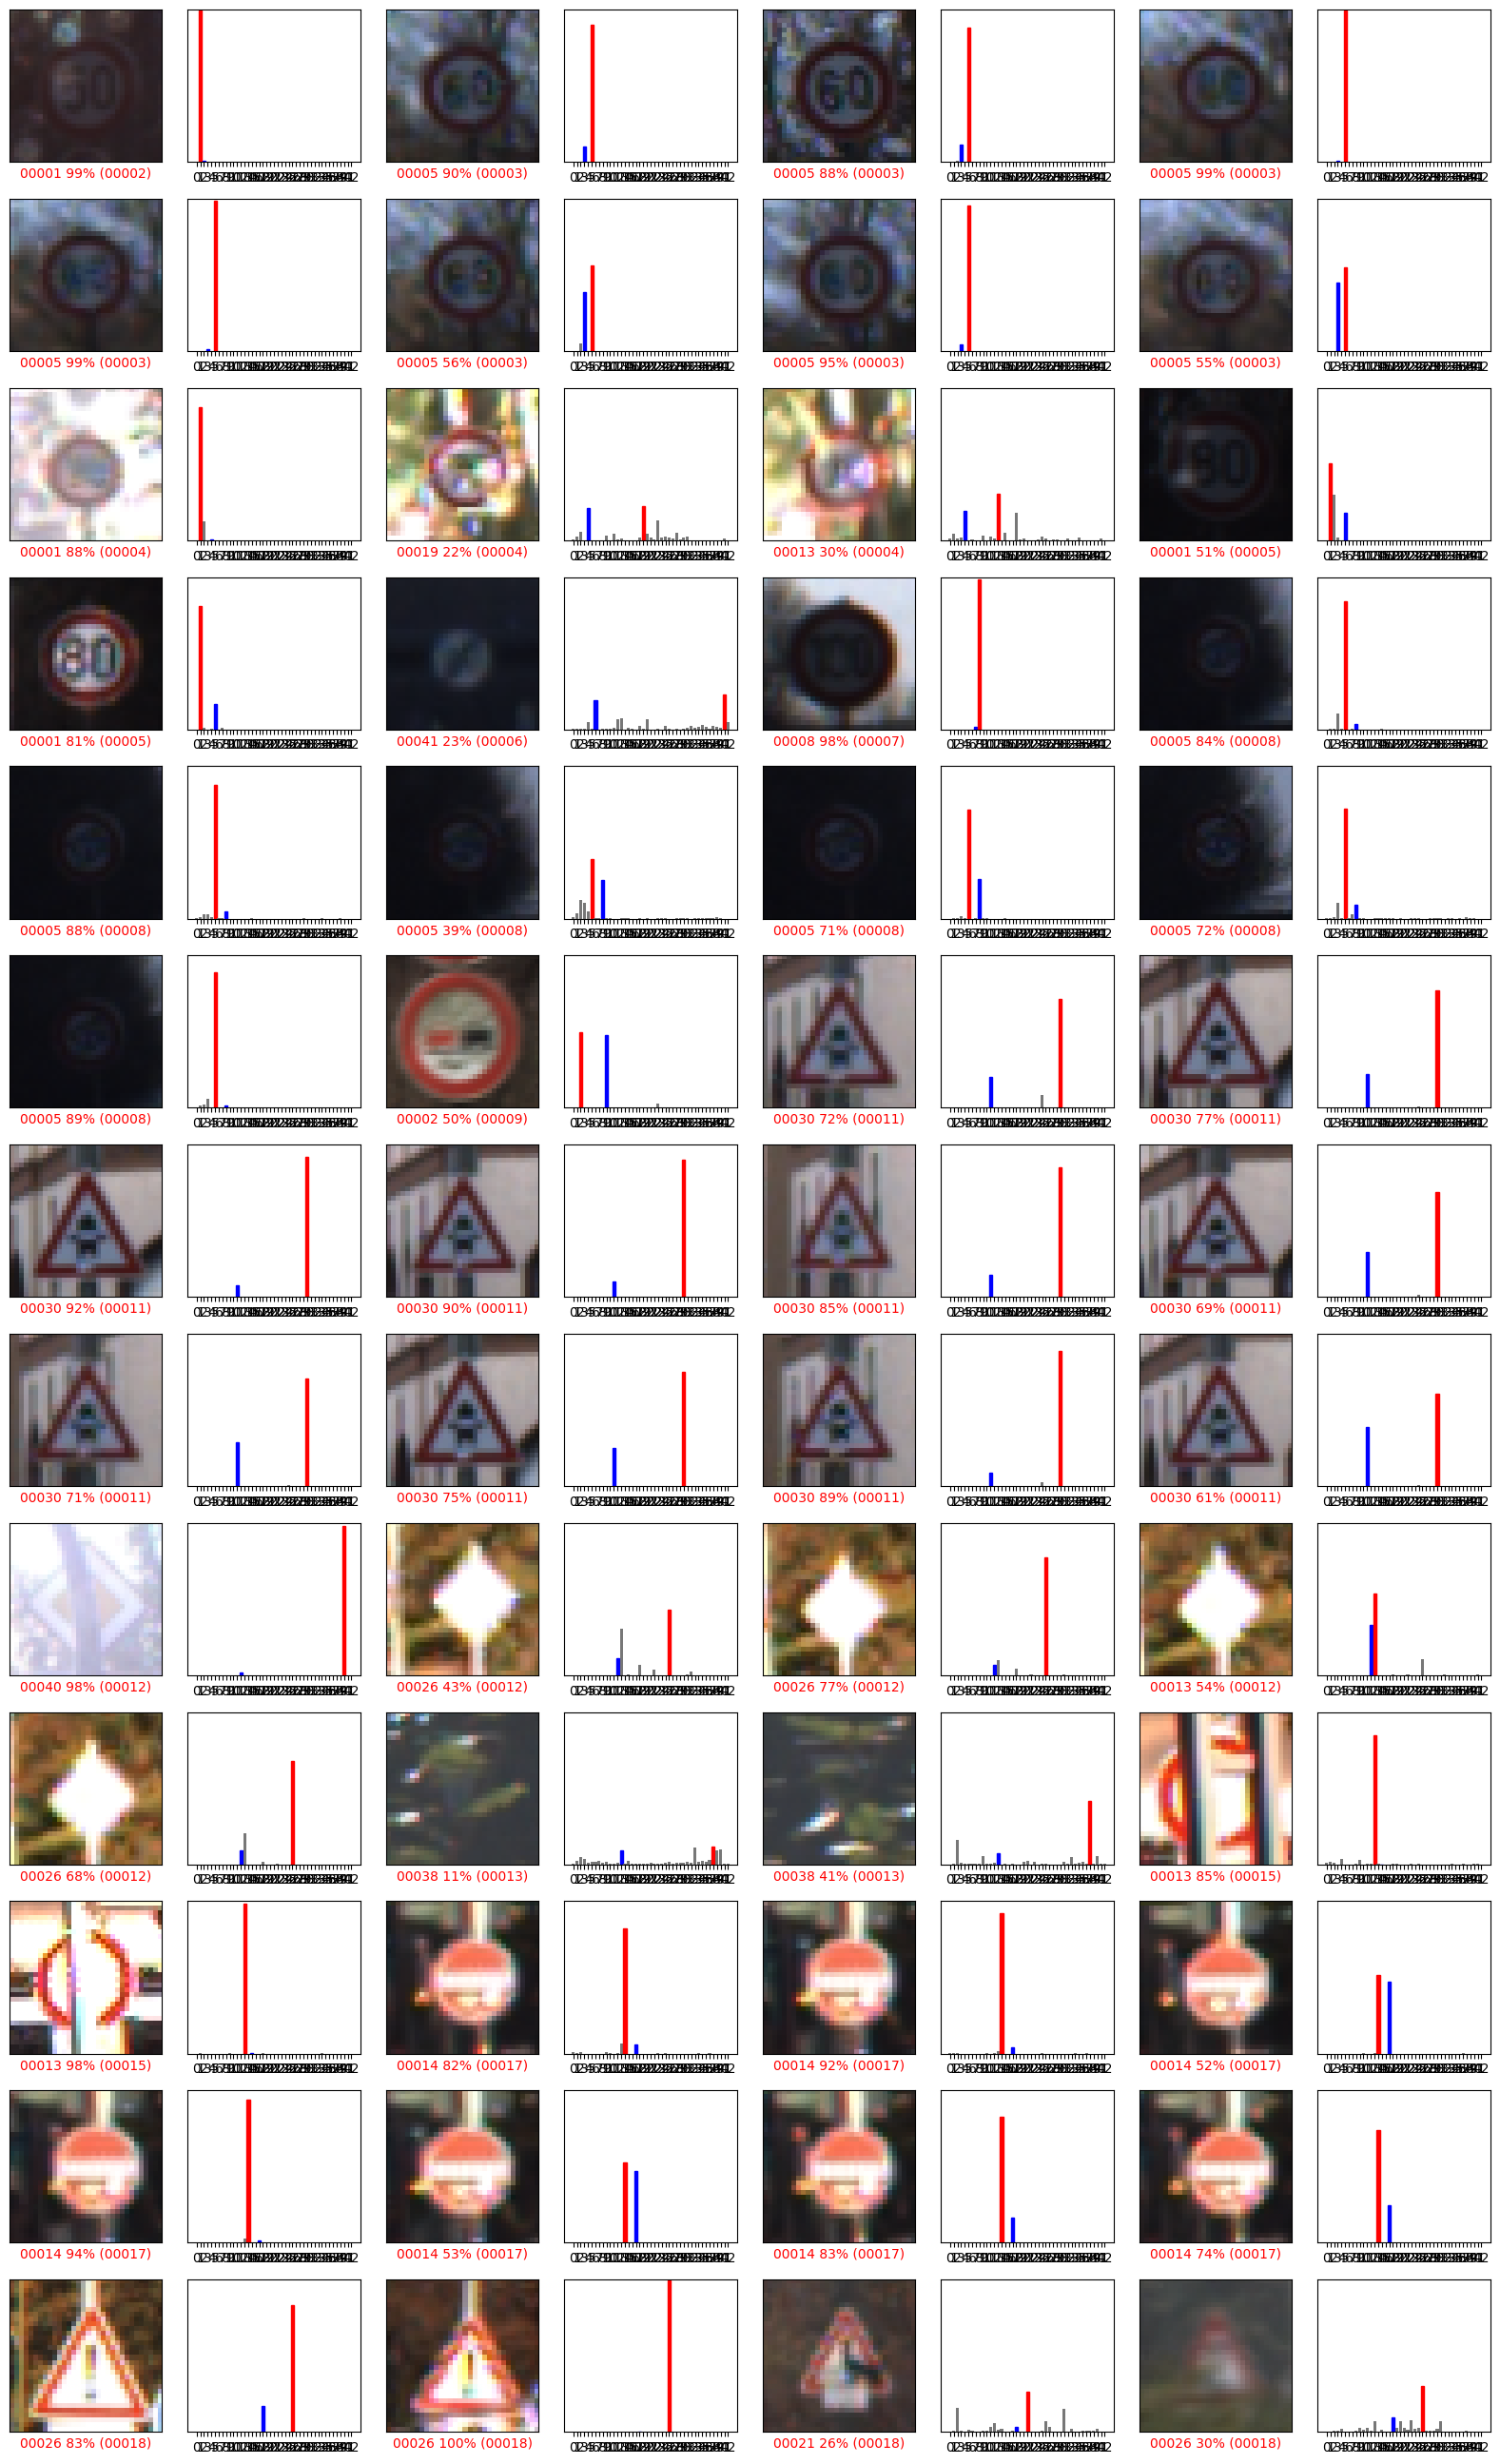

In [65]:
show_bad_preds(model_Conv, test_loader, test_set.classes)   

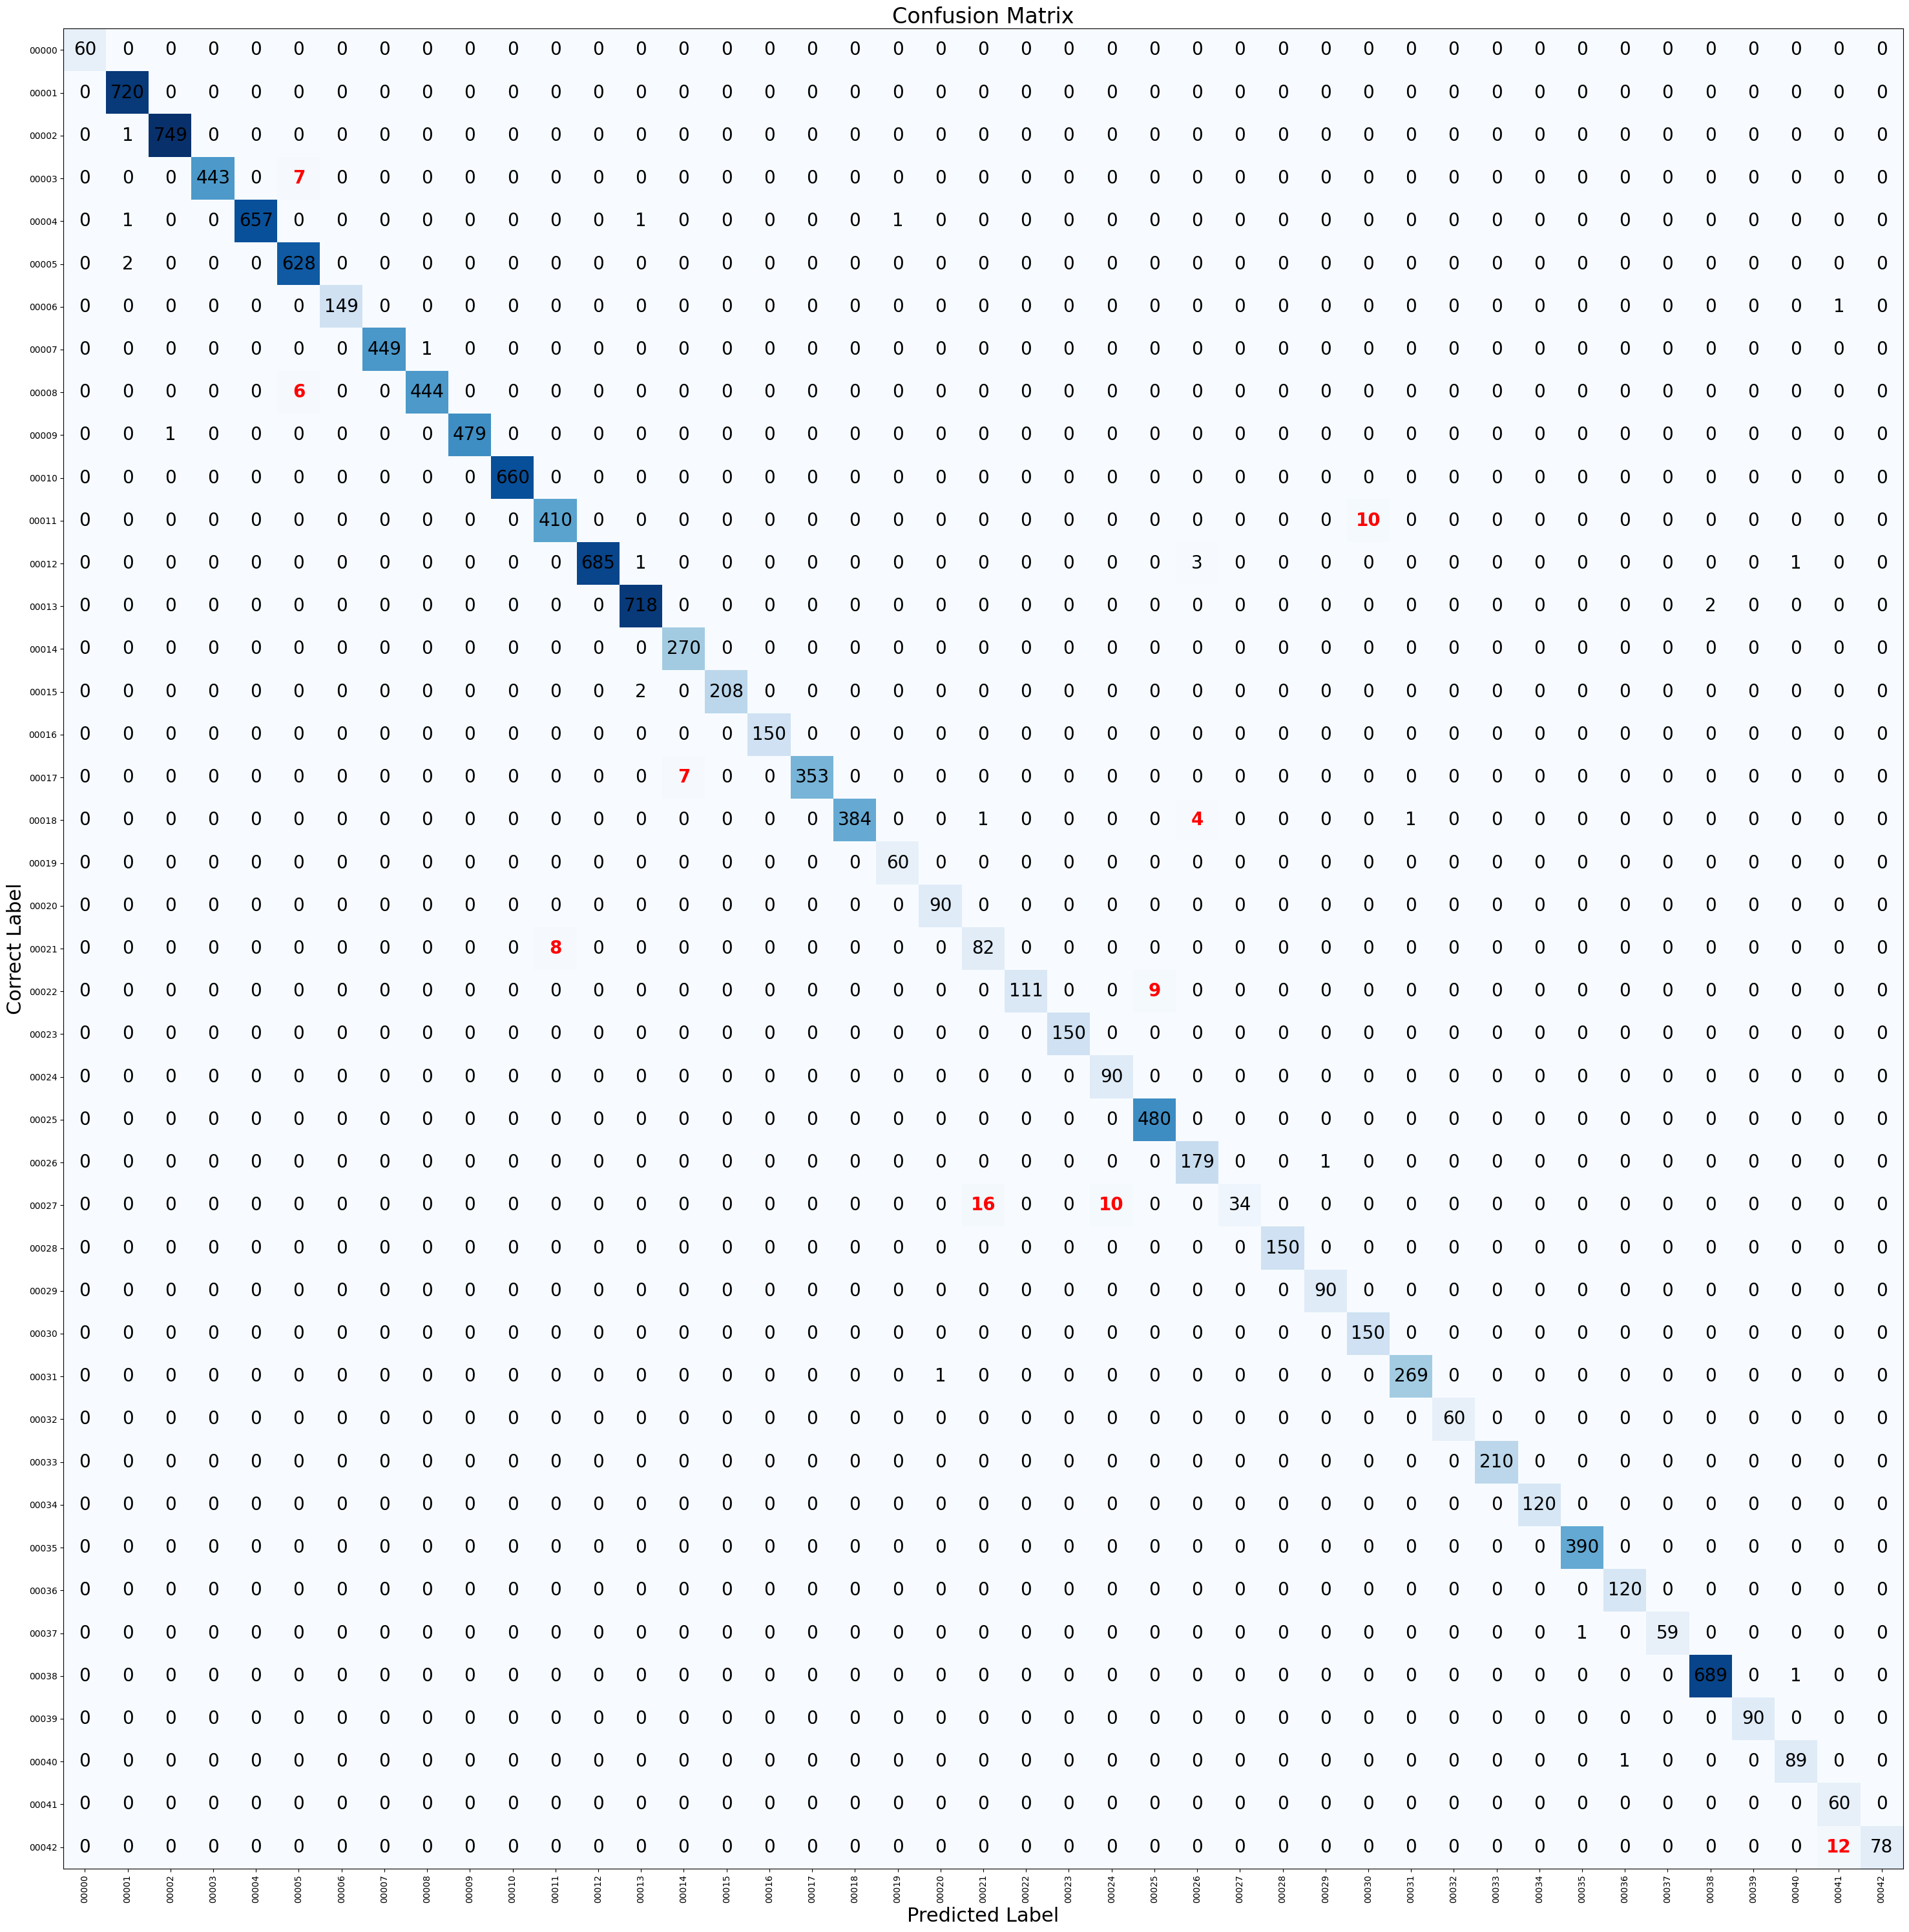

In [66]:
plot_confusion_matrix_highlight(model_Conv, test_loader, test_set.classes, threshold=3)

# __Static Augmentation - All__

In [67]:
AUG_PATH = f'{BASE_PATH}/train_augmented_all'

In [68]:
transform_aug = v2.Compose([

    # resolução maior para preservar números
    v2.Resize((32, 32)),

    # pequenas transformações geométricas
    v2.RandomApply([
        v2.RandomAffine(
            degrees=15,
            translate=(0.1, 0.1),
            scale=(0.9, 1.1),
            shear=15,
            interpolation=v2.InterpolationMode.BILINEAR
        )
    ], p=0.7),

    # variações de iluminação
    v2.RandomApply([
        v2.ColorJitter(
            brightness=0.5,
            contrast=0.5,
            saturation=0.15,
            hue=0.03
        )
    ], p=0.5),

    # ajuda com imagens desfocadas/reais
    v2.RandomApply([
        v2.GaussianBlur(
            kernel_size=3,
            sigma=(0.1, 0.4)
        )
    ], p=0.3),

    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),

    # oclusões pequenas
    v2.RandomErasing(
        p=0.15,
        scale=(0.01, 0.04),
        ratio=(0.5, 2.0),
        value='random'
    )
])

In [69]:
dataset_original = torchvision.datasets.ImageFolder(
    root=PATH_TRAINING_SET
)

classes = dataset_original.classes

os.makedirs(AUG_PATH, exist_ok=True)

N_AUGS = 3

In [70]:
for class_name in classes:

    original_class_path = os.path.join(
        PATH_TRAINING_SET,
        class_name
    )

    aug_class_path = os.path.join(
        AUG_PATH,
        class_name
    )

    os.makedirs(aug_class_path, exist_ok=True)

    image_names = [

        img_name

        for img_name in os.listdir(original_class_path)

        if img_name.lower().endswith((
            '.png',
            '.jpg',
            '.jpeg',
            '.ppm'
        ))
    ]

    for img_name in image_names:

        img_path = os.path.join(
            original_class_path,
            img_name
        )

        img = Image.open(img_path).convert('RGB')

        # SAVE ORIGINAL

        img_resized = img.resize((32, 32))

        img_resized.save(

            os.path.join(
                aug_class_path,
                f'orig_{img_name}'
            )
        )

        # SAVE AUGMENTATIONS

        for k in range(N_AUGS):

            aug_img = transform_aug(img)

            aug_img_pil = torchvision.transforms.ToPILImage()(aug_img)

            aug_img_pil.save(

                os.path.join(
                    aug_class_path,
                    f'augmented_{k}_{img_name}'
                )
            )

In [71]:
loss_fn = torch.nn.CrossEntropyLoss()

for i in range(RUNS):
    model_Conv_II = Conv_II(len(full_train_set.classes))
    model_Conv_II.to(device)

    early_stop = Early_Stopping(9)
    optimizer_II = torch.optim.Adam(model_Conv_II.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_II, mode='min', factor = 0.1, patience=3)    
    history_II = train_III(model_Conv_II, train_loader, val_loader, EPOCHS, loss_fn, optimizer_II, scheduler, early_stop, f'model_weights/static_all_aug_I_{i}')

Epoch: 000; Loss: 2.590483; Accuracy: 26.4690; Val Loss: 1.718167; Val Acc: 44.1443; Elapsed time: 41.9650
Epoch: 001; Loss: 1.545785; Accuracy: 52.4146; Val Loss: 0.871237; Val Acc: 80.7072; Elapsed time: 38.6601
Epoch: 002; Loss: 0.793516; Accuracy: 77.6445; Val Loss: 0.342514; Val Acc: 94.9788; Elapsed time: 36.5134
Epoch: 003; Loss: 0.415680; Accuracy: 89.2806; Val Loss: 0.152359; Val Acc: 95.5728; Elapsed time: 37.6876
Epoch: 004; Loss: 0.268064; Accuracy: 93.2866; Val Loss: 0.051892; Val Acc: 98.8826; Elapsed time: 38.2809
Epoch: 005; Loss: 0.215097; Accuracy: 94.4635; Val Loss: 0.028998; Val Acc: 99.7595; Elapsed time: 36.2458
Epoch: 006; Loss: 0.169667; Accuracy: 95.6064; Val Loss: 0.019960; Val Acc: 99.8161; Elapsed time: 35.9891
Epoch: 007; Loss: 0.145077; Accuracy: 96.1694; Val Loss: 0.016285; Val Acc: 99.7878; Elapsed time: 36.1692
Epoch: 008; Loss: 0.134219; Accuracy: 96.4014; Val Loss: 0.009815; Val Acc: 99.8868; Elapsed time: 35.5045
Epoch: 009; Loss: 0.122206; Accuracy:

In [72]:
# =========================================================
# TEST RESULTS
# =========================================================

res = 0

model_Conv = Conv_II(len(train_set.classes))
model_Conv.to(device)

print('\n========== STATIC ALL RESULTS ==========')

for i in range(RUNS):

    # -----------------------------------------------------
    # Load best checkpoint
    # -----------------------------------------------------

    checkpoint = torch.load(
        f'model_weights/static_all_aug_I_{i}.pt'
    )

    model_Conv.load_state_dict(checkpoint['model'])

    # -----------------------------------------------------
    # Metrics
    # -----------------------------------------------------

    best_epoch = checkpoint['epoch']

    test_acc = evaluate(model_Conv, test_loader) * 100
    eval_acc = evaluate(model_Conv, val_loader) * 100

    # -----------------------------------------------------
    # Print run results
    # -----------------------------------------------------

    print(f'\nRUN {i + 1}')

    print(f'Best Epoch    : {best_epoch}')
    print(f'Eval Accuracy : {eval_acc:.2f}%')
    print(f'Test Accuracy : {test_acc:.2f}%')

    # -----------------------------------------------------
    # Mean test accuracy
    # -----------------------------------------------------

    res += test_acc

# =========================================================
# FINAL MEAN
# =========================================================

res /= RUNS

print('\n========== FINAL MEAN TEST ACCURACY ==========')
print(f'Mean Test Accuracy : {res:.2f}%')

static_all_acc = res


========== STATIC ALL RESULTS ==========

RUN 1
Best Epoch    : 29
Eval Accuracy : 100.00%
Test Accuracy : 99.25%

RUN 2
Best Epoch    : 29
Eval Accuracy : 100.00%
Test Accuracy : 99.40%

RUN 3
Best Epoch    : 25
Eval Accuracy : 100.00%
Test Accuracy : 99.18%

========== FINAL MEAN TEST ACCURACY ==========
Mean Test Accuracy : 99.27%


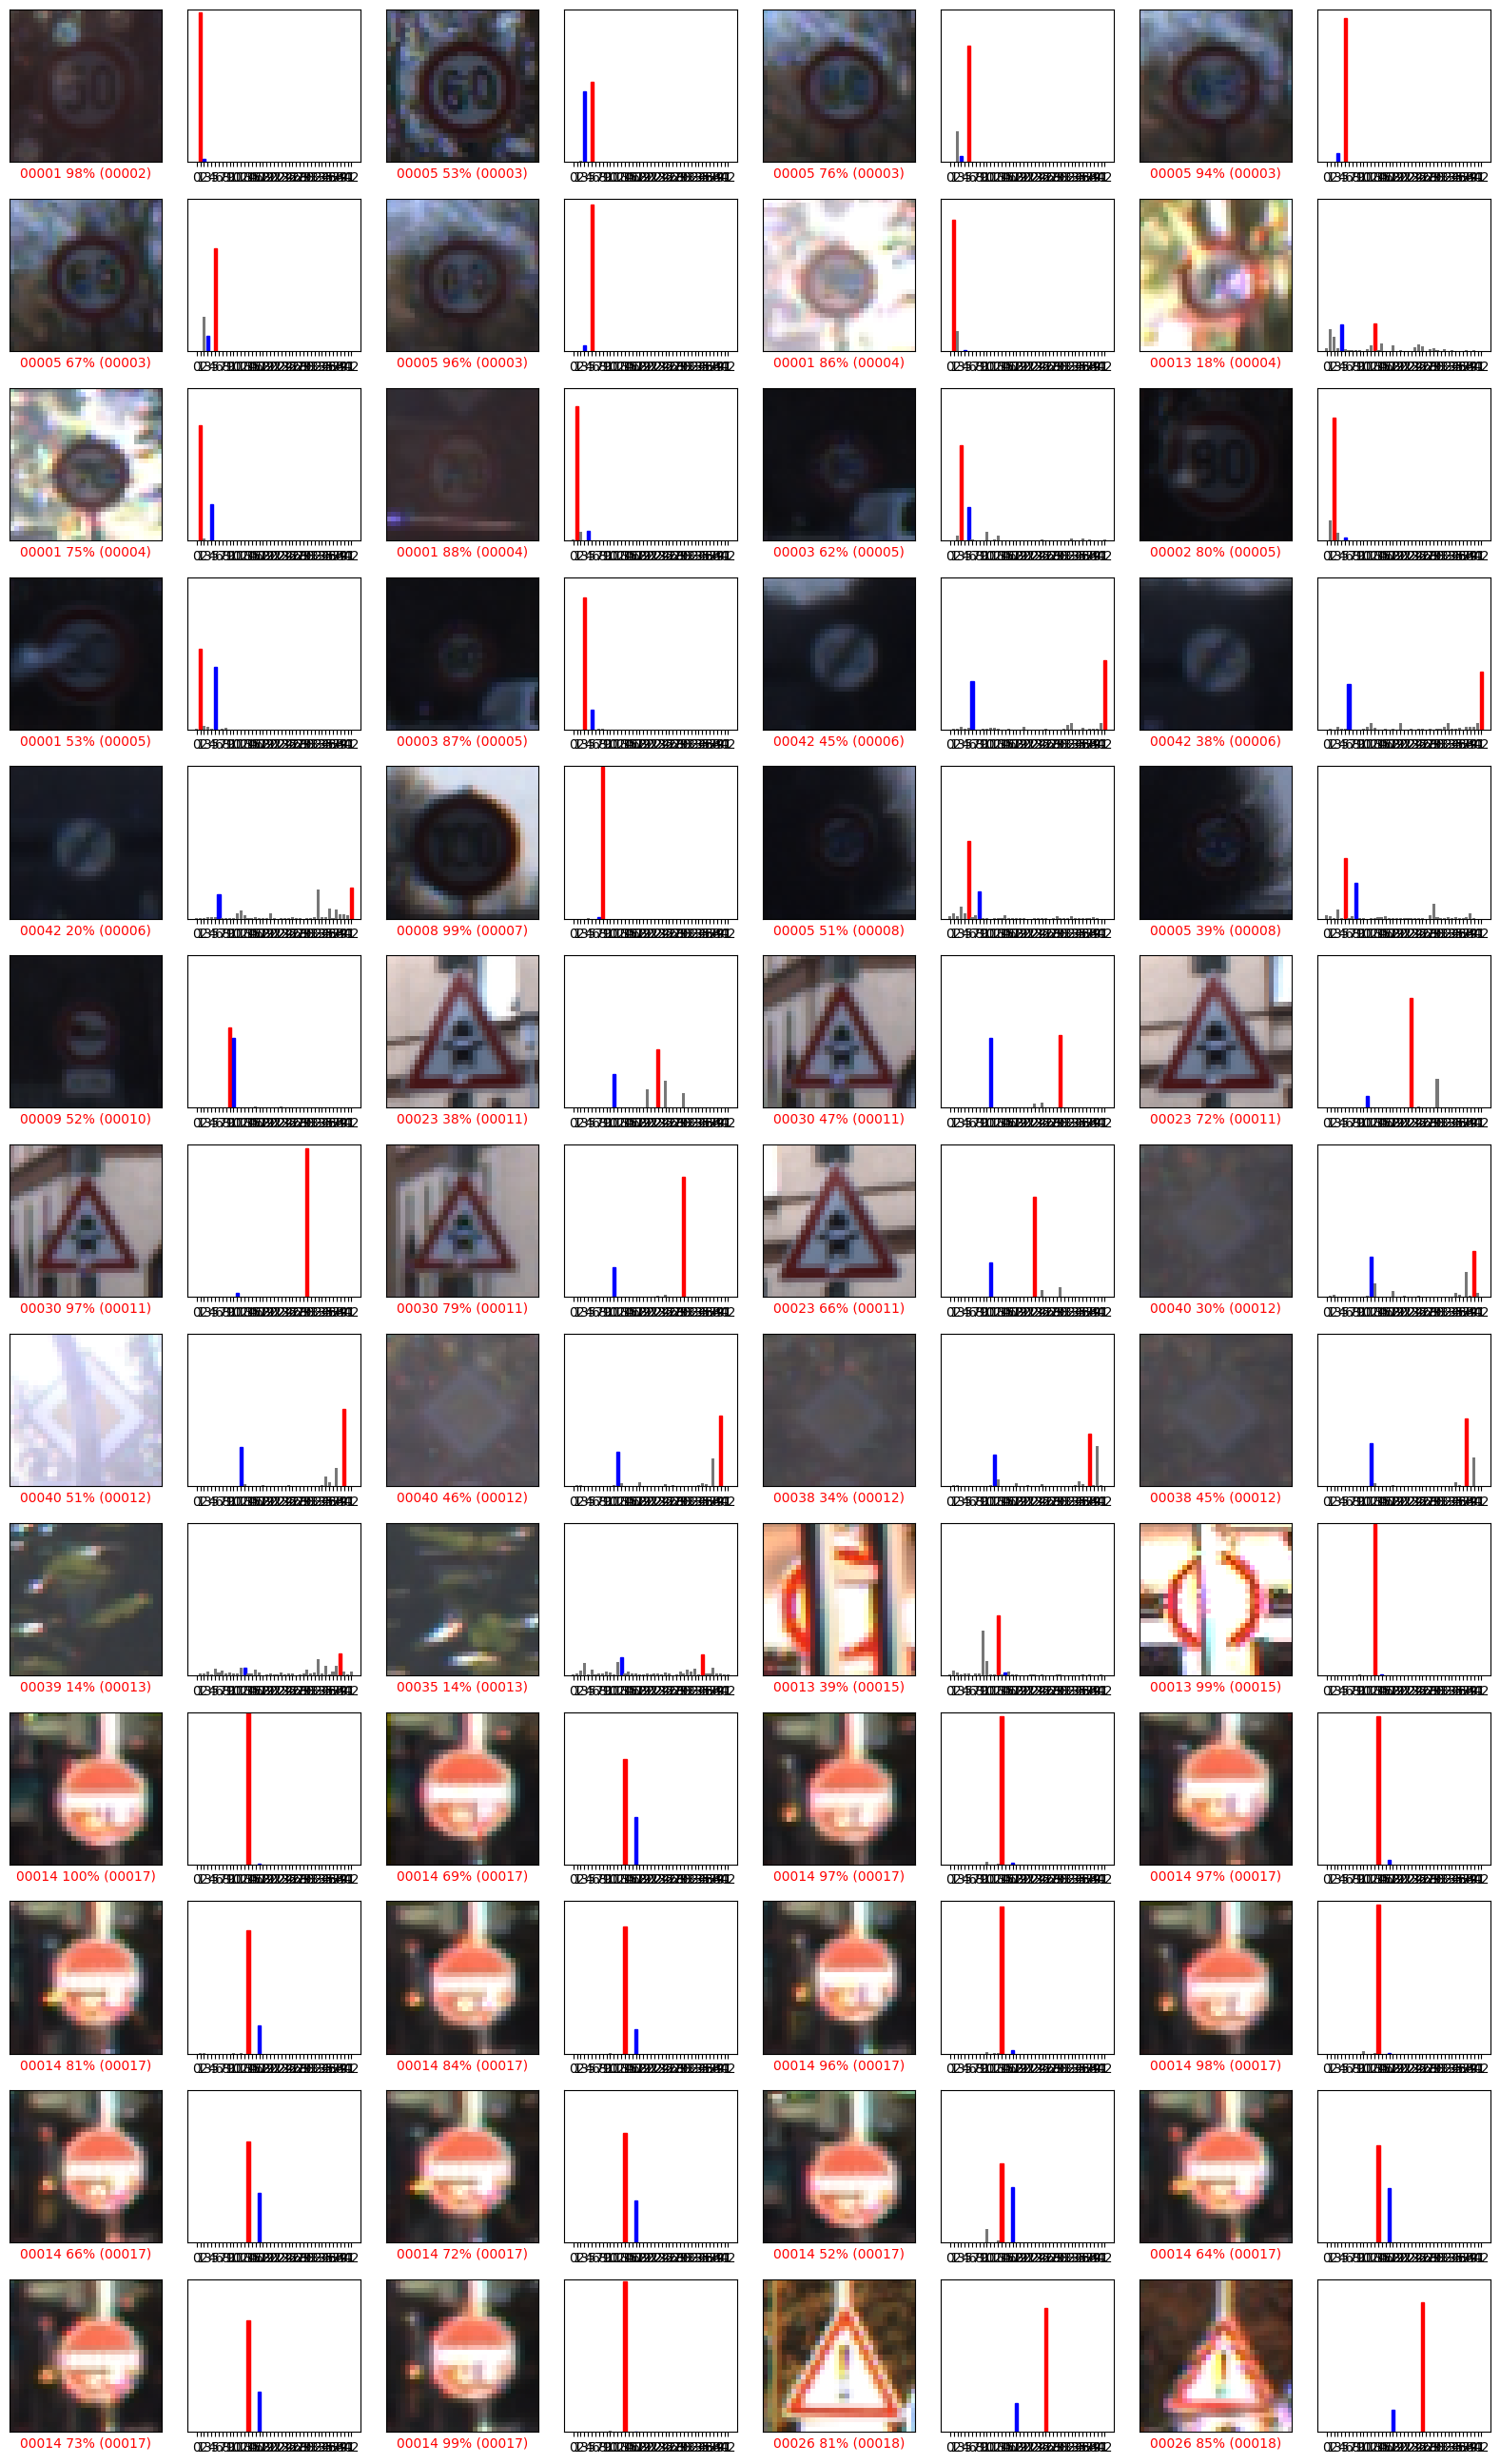

In [73]:
show_bad_preds(model_Conv, test_loader, test_set.classes)   

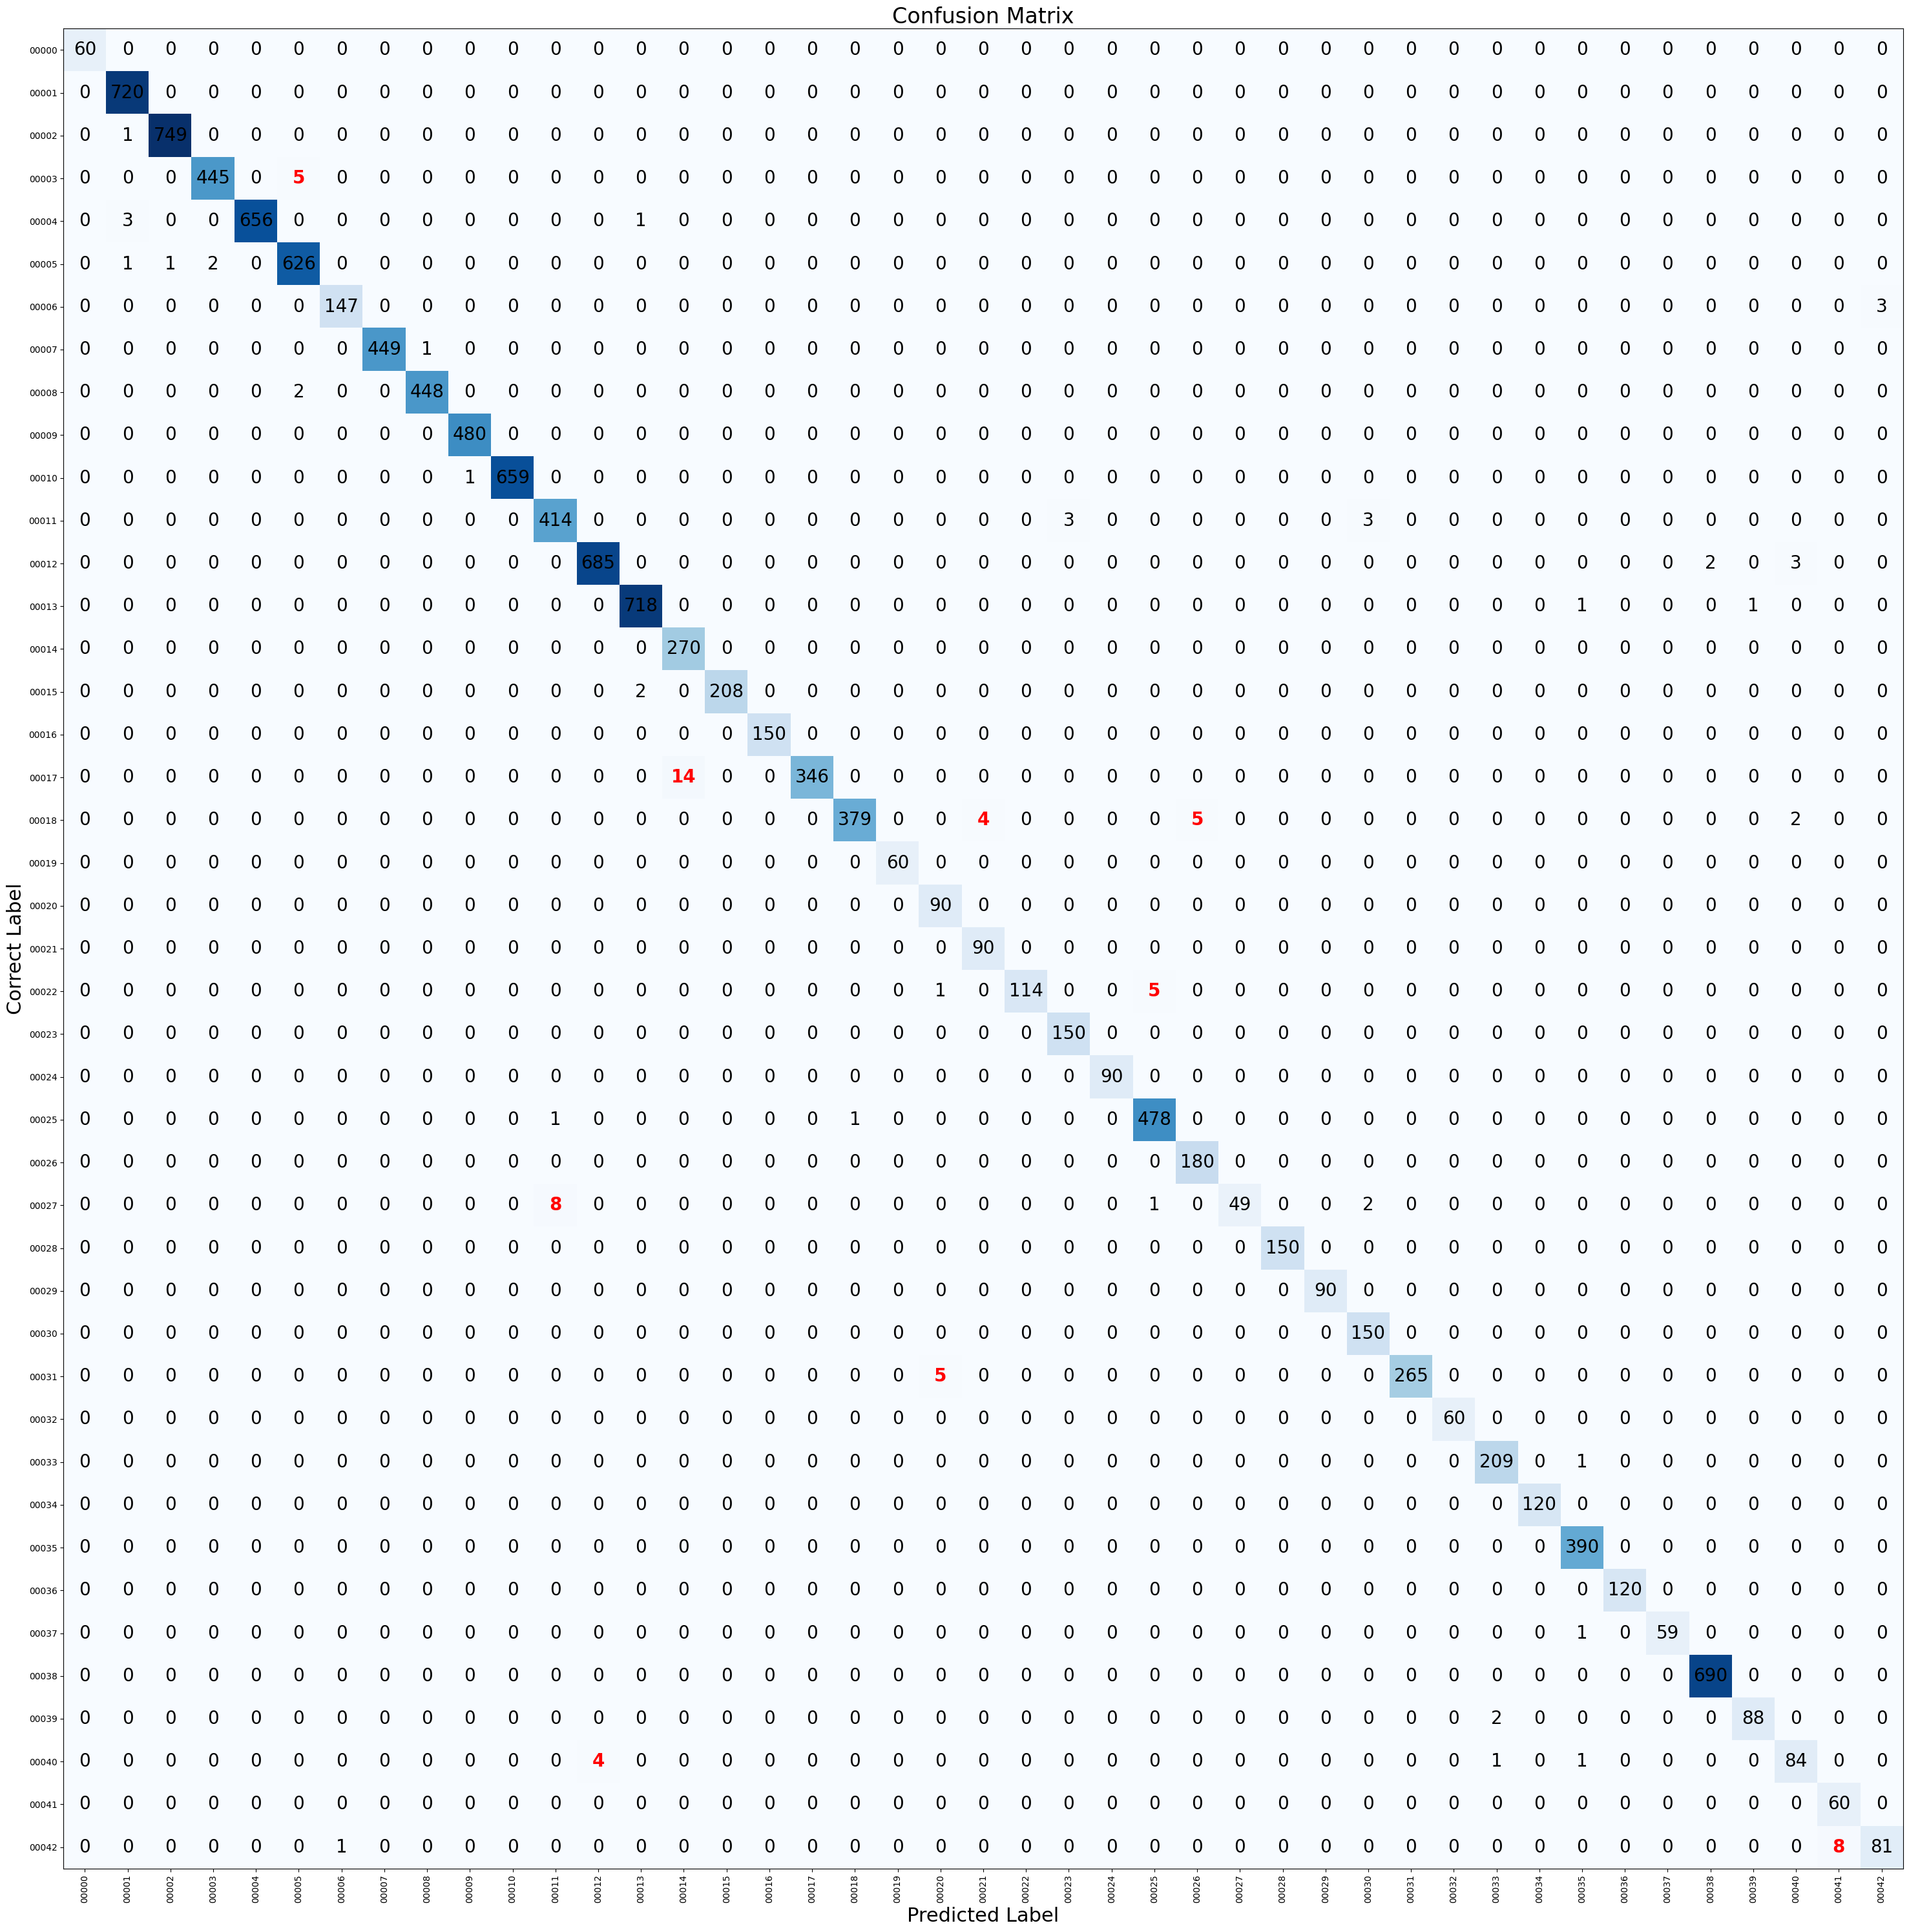

In [74]:
plot_confusion_matrix_highlight(model_Conv, test_loader, test_set.classes, threshold=3)

# __Results__

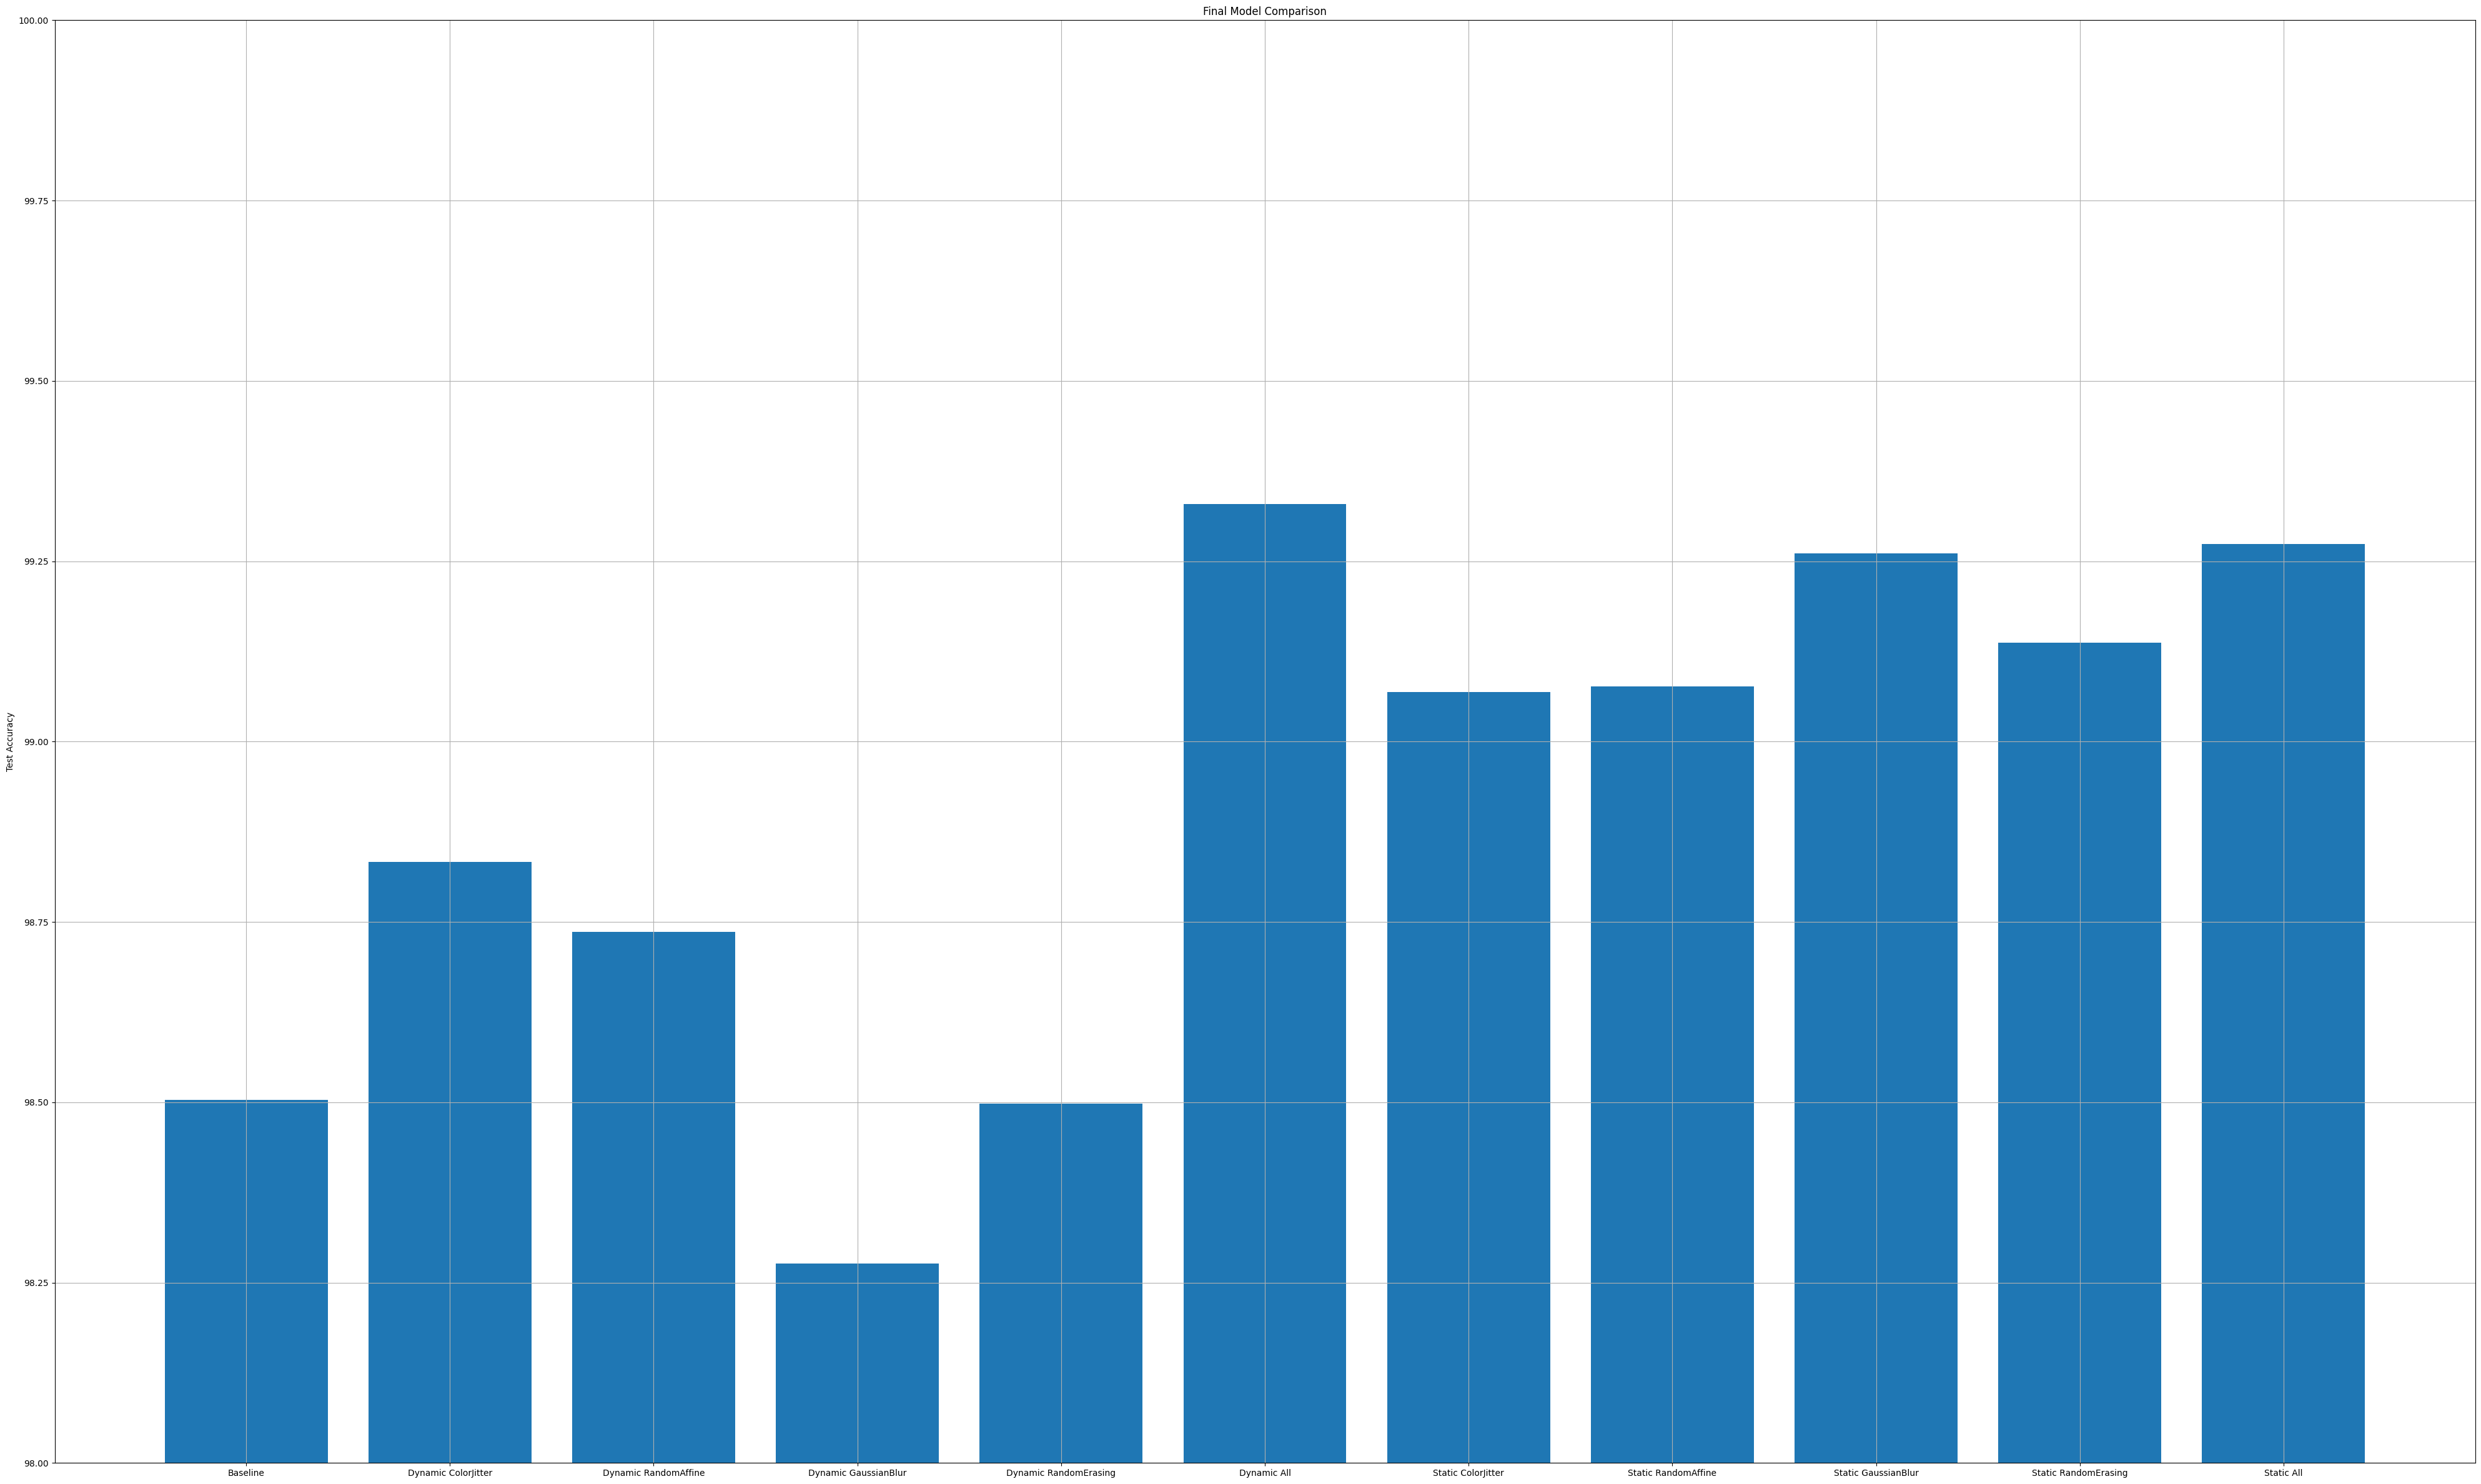

In [78]:
models = ['Baseline', 'Dynamic ColorJitter', 'Dynamic RandomAffine', 'Dynamic GaussianBlur', 'Dynamic RandomErasing', 'Dynamic All', 'Static ColorJitter', 'Static RandomAffine', 'Static GaussianBlur', 'Static RandomErasing', 'Static All']
test_acc = [baseline_acc, dynamic_colorJitter_acc, dynamic_randomAffine_acc, dynamic_gaussianBlur_acc, dynamic_randomErasing_acc, dynamic_all_acc, static_colorJitter_acc, static_randomAffine_acc, static_gaussianBlur_acc, static_randomErasing_acc, static_all_acc]

plt.figure(figsize=(50,30))
plt.bar(models, test_acc)
plt.ylabel('Test Accuracy')
plt.ylim(98, 100)
plt.grid(True)
plt.title('Final Model Comparison')
plt.show()